# **Smart Meter Load Forecasting Across Moroccan Cities**


**Ampere-to-kW Conversion Formula and Power Factor Values**

**Formula:**

$$P_{(kW)} = \sqrt{3} \times V_{line(kV)} \times I_{(A)} \times PF$$


This is the standard **three-phase active power formula** for medium-voltage AC distribution systems.

| Parameter | Value | Basis |
|---|---|---|
| **V_line** | **22 kV** | Dataset documentation all smart meters are on 22 kV MVDT departures |
| **PF (Power Factor)** | **0.90** | Mid-range of 0.85–0.95 typical for MV distribution feeders in literature |

**Power Factor Applied per City**

| City | Raw Unit | Power Factor | Conversion Applied? |
|---|---|---|---|
| **Laâyoune** | Amperes (A) | **0.90** | Yes |
| **Boujdour** | Amperes (A) | **0.90** | Yes |
| **Foum Eloued** | Amperes (A) | **0.90** | Yes |
| **Marrakech** | Kilowatts (kW) | **Not applicable** | Already in kW |

> **Limitation:** A single uniform PF of 0.90 is applied across all three Ampere-metered cities.  
> In practice, residential zones typically have PF ≈ 0.92–0.95 and industrial zones PF ≈ 0.80–0.85.  
> City- or zone-specific PF values obtained from ONEE records would improve conversion accuracy.  
> This assumption is acknowledged as a methodological limitation in the report.

## **[1] Imports & configuration**

In [ ]:
# Import required libraries
import warnings
from pathlib import Path

import matplotlib.pyplot as plt   # for plotting graphs
import numpy as np                # for numerical operations
import pandas as pd               # for handling tabular data
import seaborn as sns             # for statistical plotting

# Suppress unnecessary warnings to keep output clean
warnings.filterwarnings("ignore")

# Set seaborn style for plots (white grid background)
sns.set_style("whitegrid")

# Configure default plot settings for figure size and title size
plt.rcParams["figure.figsize"] = (13, 5)   # default figure size
plt.rcParams["axes.titlesize"] = 13        # default title font size

# Define the path to the raw dataset (Excel file)
DATA_PATH = Path("/content/Data Morocco.xlsx")

# Define output directory for processed data
OUTPUT_DIR = Path("processed_data")
OUTPUT_DIR.mkdir(exist_ok=True)   # create folder if it does not exist

# ------------------------------------------------------------
# Define metadata about the dataset
# ------------------------------------------------------------

# Zones present in each city sheet (confirmed by inspecting the Excel file)
CITY_ZONES = {
    "Laayoune": ["zone1", "zone2", "zone3", "zone4", "zone5"],
    "Boujdour": ["zone1", "zone2", "zone3"],
    "Foum eloued": ["zone1", "zone2", "zone3", "zone4", "zone5", "zone6", "zone7"],
    "Marrakech": ["zone1", "zone2"],
}

# Measurement units per city (based on UCI documentation and data inspection)
CITY_UNITS = {
    "Laayoune": "A",       # Amperes
    "Boujdour": "A",
    "Foum eloued": "A",
    "Marrakech": "kW",     # Kilowatts
}

# Native sampling frequency per city
CITY_FREQ = {
    "Laayoune": "10min",   # data recorded every 10 minutes
    "Boujdour": "10min",
    "Foum eloued": "10min",
    "Marrakech": "30min",  # data recorded every 30 minutes
}

# ------------------------------------------------------------
# Constants for power conversion and analysis
# ------------------------------------------------------------

LINE_VOLTAGE_KV = 22       # line voltage in kilovolts
POWER_FACTOR = 0.90        # assumed power factor for conversion

# Define overlap period across all datasets (common time window)
OVERLAP_START = "2023-01-09"
OVERLAP_END   = "2024-01-08"


> Loads all required libraries, sets plotting defaults, defines file paths, and declares city-specific constants (zones, units, sampling frequency, 22 kV line voltage, PF = 0.90, and the common overlap window).

## **[2] Inspect raw workbook structure**

In [ ]:
# Check if the Excel data file exists at the specified path
if not DATA_PATH.exists():
    # Raise an error if the file is missing, with a clear message
    raise FileNotFoundError(
        f"'{DATA_PATH}' not found. Place the workbook next to this "
        "script/notebook, or update DATA_PATH above."
    )

# Load the Excel workbook using pandas
xls = pd.ExcelFile(DATA_PATH)

# Print the number of sheets and their names for quick inspection
print(f"Workbook contains {len(xls.sheet_names)} sheet(s): {xls.sheet_names}\n")

# Preview the first 5 rows of each sheet
for sheet in xls.sheet_names:
    # Read only the first 5 rows of the current sheet
    preview = pd.read_excel(DATA_PATH, sheet_name=sheet, nrows=5)

    # Print the sheet name and its preview
    print(f"--- '{sheet}' ---")
    print(preview)
    print()   # blank line for readability between sheets


Workbook contains 4 sheet(s): ['Laayoune', 'Boujdour', 'Foum eloued', 'Marrakech']

--- 'Laayoune' ---
             DateTime      zone1       zone2       zone3       zone4  \
0 2022-09-14 17:10:00  73.536915  120.920183  160.982021  122.236644   
1 2022-09-14 17:20:00  74.403119  122.179697  159.403248  119.727278   
2 2022-09-14 17:30:00  77.893555  124.701734  159.969683  118.508081   
3 2022-09-14 17:40:00  78.317958  126.731194  161.969315  118.571429   
4 2022-09-14 17:50:00  81.334845  125.741697  163.189366  120.688295   

        zone5  
0  102.922162  
1  101.747520  
2  102.074112  
3  102.911361  
4  102.546117  

--- 'Boujdour' ---
             DateTime      zone1      zone2      zone3
0 2022-09-14 17:10:00  59.807116  14.877097  60.769552
1 2022-09-14 17:20:00  59.684625  15.082980  60.518001
2 2022-09-14 17:30:00  60.448680  15.250274  60.626027
3 2022-09-14 17:40:00  59.717645  15.150824  59.290443
4 2022-09-14 17:50:00  60.750153  15.595213  60.428926

--- 'Foum eloued'

> Verifies the workbook exists, then prints sheet names and a 5-row preview of each sheet. Confirm column names and data types before loading the full dataset.

## **[3] Load each city sheet**

In [ ]:

# Function to load data for a given city sheet from the Excel file
def load_city(sheet_name: str) -> pd.DataFrame:
    # Read the sheet into a DataFrame
    df = pd.read_excel(DATA_PATH, sheet_name=sheet_name)

    # Rename the 'DateTime' column to 'timestamp' for consistency
    df = df.rename(columns={"DateTime": "timestamp"})

    # Convert the timestamp column to proper datetime objects
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Sort the data chronologically by timestamp
    df = df.sort_values("timestamp")

    # Count duplicate timestamps (if any exist)
    n_dupes = int(df["timestamp"].duplicated().sum())

    # If duplicates are found, drop them (keep the first occurrence)
    if n_dupes:
        df = df.drop_duplicates(subset="timestamp", keep="first")

    # Set timestamp as the DataFrame index for time-series operations
    df = df.set_index("timestamp")

    # Return the cleaned DataFrame and number of duplicates removed
    return df, n_dupes


# Load data for all cities defined in CITY_ZONES

city_data = {}   # dictionary to store cleaned data for each city

for city in CITY_ZONES:
    # Load city data using the function defined above
    df, n_dupes = load_city(city)

    # Store the DataFrame in the dictionary keyed by city name
    city_data[city] = df

    # Print summary information for each city:
    # - number of rows
    # - duplicates removed
    # - date range covered
    print(f"{city:15s}: {df.shape[0]:>7,} rows | {n_dupes} duplicate timestamp(s) "
          f"dropped | range {df.index.min()} -> {df.index.max()}")


Laayoune       :  88,878 rows | 12 duplicate timestamp(s) dropped | range 2022-09-14 17:10:00 -> 2024-05-24 00:00:00
Boujdour       :  88,878 rows | 12 duplicate timestamp(s) dropped | range 2022-09-14 17:10:00 -> 2024-05-24 00:00:00
Foum eloued    :  88,878 rows | 12 duplicate timestamp(s) dropped | range 2022-09-14 17:10:00 -> 2024-05-24 00:00:00
Marrakech      :  17,498 rows | 3 duplicate timestamp(s) dropped | range 2023-01-09 00:00:00 -> 2024-01-08 23:30:00


> Reads each city's Excel sheet, parses the DateTime column as a proper timestamp index, removes any duplicate timestamps (keeping the first occurrence), and stores each city's raw DataFrame in `city_data`.

## **[4] Missing values & timestamp-gap handling**

In [ ]:
# ------------------------------------------------------------
# Function to fix gaps in time-series data for a given city
# ------------------------------------------------------------
def fix_gaps(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    # Create a complete datetime index from min to max timestamp at given frequency
    full_idx = pd.date_range(df.index.min(), df.index.max(), freq=freq)

    # Identify timestamps that are missing in the raw data
    missing_ts = full_idx.difference(df.index)

    # Reindex the DataFrame to include all expected timestamps
    df = df.reindex(full_idx)
    df.index.name = "timestamp"

    # Count total missing values before interpolation
    na_before = int(df.isna().sum().sum())

    # ------------------------------------------------------------
    # Fill short gaps (<= 6 consecutive readings, i.e. <= 1h at 10-min resolution)
    # using time-based linear interpolation.
    # Longer outages are left as NaN to avoid fabricating data.
    # ------------------------------------------------------------
    df = df.interpolate(method="time", limit=6, limit_direction="both")

    # Count missing values after interpolation
    na_after = int(df.isna().sum().sum())

    # Print summary of gap-filling process for transparency
    print(f"  expected {len(full_idx):,} timestamps @ {freq} | "
          f"{len(missing_ts):,} missing from raw file "
          f"({len(missing_ts) / len(full_idx) * 100:.3f}%) | "
          f"NaNs after reindex: {na_before:,} -> after interpolation: {na_after:,}")

    # Return the cleaned DataFrame
    return df


# ------------------------------------------------------------
# Apply gap-fixing function to all cities in the dataset
# ------------------------------------------------------------
for city in city_data:
    print(city)   # Print city name for clarity
    # Fix gaps using the city’s native sampling frequency
    city_data[city] = fix_gaps(city_data[city], CITY_FREQ[city])


Laayoune
  expected 88,890 timestamps @ 10min | 12 missing from raw file (0.013%) | NaNs after reindex: 60 -> after interpolation: 0
Boujdour
  expected 88,890 timestamps @ 10min | 12 missing from raw file (0.013%) | NaNs after reindex: 36 -> after interpolation: 0
Foum eloued
  expected 88,890 timestamps @ 10min | 12 missing from raw file (0.013%) | NaNs after reindex: 84 -> after interpolation: 0
Marrakech
  expected 17,520 timestamps @ 30min | 25 missing from raw file (0.143%) | NaNs after reindex: 50 -> after interpolation: 14


> Rebuilds a complete, gap-free timestamp index at the native frequency for each city; any short gaps (≤ 6 consecutive missing readings) are filled by linear time-interpolation, and the number of NaNs before and after is reported.

## **[5] Unit standardisation: Amperes -> kW**

In [ ]:
# ------------------------------------------------------------
# Function to convert current (Amps) to power (kW) for 3-phase systems
# ------------------------------------------------------------
def amps_to_kw(amps: pd.Series, voltage_kv=LINE_VOLTAGE_KV, pf=POWER_FACTOR) -> pd.Series:
    """
    Three-phase conversion at the stated medium-voltage line level.
    Formula: √3 × Voltage (kV) × Current (A) × Power Factor
    """
    return np.sqrt(3) * voltage_kv * amps * pf


# ------------------------------------------------------------
# Apply conversion for each city dataset
# ------------------------------------------------------------
for city, df in city_data.items():
    zones = CITY_ZONES[city]   # list of zones for the current city

    # If the city’s raw data is in Amperes, convert to kW
    if CITY_UNITS[city] == "A":
        for z in zones:
            # Create new column with converted values for each zone
            df[f"{z}_kW"] = amps_to_kw(df[z])

        # Print confirmation of conversion with assumptions used
        print(f"{city:15s}: converted {len(zones)} zone(s) A -> kW "
              f"(assumed {LINE_VOLTAGE_KV} kV line, PF={POWER_FACTOR}).")

    # If the city’s raw data is already in kW, no conversion needed
    else:
        for z in zones:
            # Copy values directly into new kW columns
            df[f"{z}_kW"] = df[z]

        # Print confirmation that no conversion was applied
        print(f"{city:15s}: already in kW, no conversion applied.")

    # ------------------------------------------------------------
    # Compute total load (kW) across all zones for the city
    # ------------------------------------------------------------
    df["total_kW"] = df[[f"{z}_kW" for z in zones]].sum(axis=1)

    # Update the city_data dictionary with the modified DataFrame
    city_data[city] = df


Laayoune       : converted 5 zone(s) A -> kW (assumed 22 kV line, PF=0.9).
Boujdour       : converted 3 zone(s) A -> kW (assumed 22 kV line, PF=0.9).
Foum eloued    : converted 7 zone(s) A -> kW (assumed 22 kV line, PF=0.9).
Marrakech      : already in kW, no conversion applied.


> Converts Ampere readings in Laâyoune, Boujdour and Foum Eloued to kilowatts using the three-phase formula P = √3 × 22 kV × I × 0.90; Marrakech is already in kW and is copied unchanged; each city then gains a `total_kW` column summing all zones.

## **[6] Resample to daily / weekly profiles & export**

In [ ]:
# ------------------------------------------------------------
# Create a standardized DataFrame containing total load (kW) for each city
# ------------------------------------------------------------
# Collect the 'total_kW' series from each city and combine into one DataFrame
standardised = pd.DataFrame({city: df["total_kW"] for city, df in city_data.items()})

# Resample to daily frequency (mean load per day)
daily = standardised.resample("D").mean()

# Resample to weekly frequency (mean load per week)
weekly = standardised.resample("W").mean()


# ------------------------------------------------------------
# Save cleaned and aggregated datasets to CSV files
# ------------------------------------------------------------
for city, df in city_data.items():
    # Save each city’s cleaned dataset at native resolution (10-min or 30-min)
    df.to_csv(OUTPUT_DIR / f"{city.replace(' ', '_').lower()}_clean_10or30min.csv")

# Save combined datasets at different resolutions
standardised.to_csv(OUTPUT_DIR / "total_load_by_city_native_resolution_kW.csv")  # native resolution
daily.to_csv(OUTPUT_DIR / "total_load_by_city_daily_kW.csv")                     # daily averages
weekly.to_csv(OUTPUT_DIR / "total_load_by_city_weekly_kW.csv")                   # weekly averages

# Print confirmation message with absolute path of output directory
print(f"Cleaned datasets saved to: {OUTPUT_DIR.resolve()}")


Cleaned datasets saved to: /content/processed_data


> Aggregates the per-city total_kW series into a single `standardised` DataFrame, resamples it to daily and weekly mean profiles, and exports all cleaned series to CSV files in `processed_data/`.

## **[7] Exploratory Data Analysis**



### **1. Descriptive statistics (per-zone, kW)**

In [ ]:
# ------------------------------------------------------------
# Loop through each city dataset to generate descriptive statistics
# ------------------------------------------------------------
for city, df in city_data.items():
    # Build a list of zone columns (already converted to kW) plus the total load column
    zones_kw = [f"{z}_kW" for z in CITY_ZONES[city]] + ["total_kW"]

    # Print city name for clarity
    print(f"\n{city} (kW):")

    # Use .describe() to compute summary statistics (count, mean, std, min, quartiles, max)
    # Transpose (.T) so that each zone appears as a row instead of a column
    print(df[zones_kw].describe().T)


Laayoune (kW):
            count          mean          std  min           25%           50%  \
zone1_kW  88890.0   2247.204868   648.622243  0.0   1722.841948   2211.882090   
zone2_kW  88890.0   3768.995381  1158.582895  0.0   2807.438960   3758.142672   
zone3_kW  88890.0   5193.680005  1397.326843  0.0   3977.500330   5325.717403   
zone4_kW  88890.0   3895.124244   896.621363  0.0   3165.613194   3969.087854   
zone5_kW  88890.0   4122.756627  1161.899735  0.0   3183.539343   4095.219466   
total_kW  88890.0  19227.761125  4524.189566  0.0  15372.264621  19373.671639   

                   75%           max  
zone1_kW   2675.489313   4549.798631  
zone2_kW   4510.317029  18279.757278  
zone3_kW   6343.375139  24550.287021  
zone4_kW   4559.156356   8753.686142  
zone5_kW   5041.979488  11209.294082  
total_kW  22821.574278  45160.405797  

Boujdour (kW):
            count         mean          std  min          25%          50%  \
zone1_kW  88890.0  2542.133264   840.054171  0.0 

> Prints per-zone and total descriptive statistics (count, mean, std, min, percentiles, max) for each city, revealing the wide spread in load magnitude and variability across regions.

### **2. Full daily time-series, total load per city**

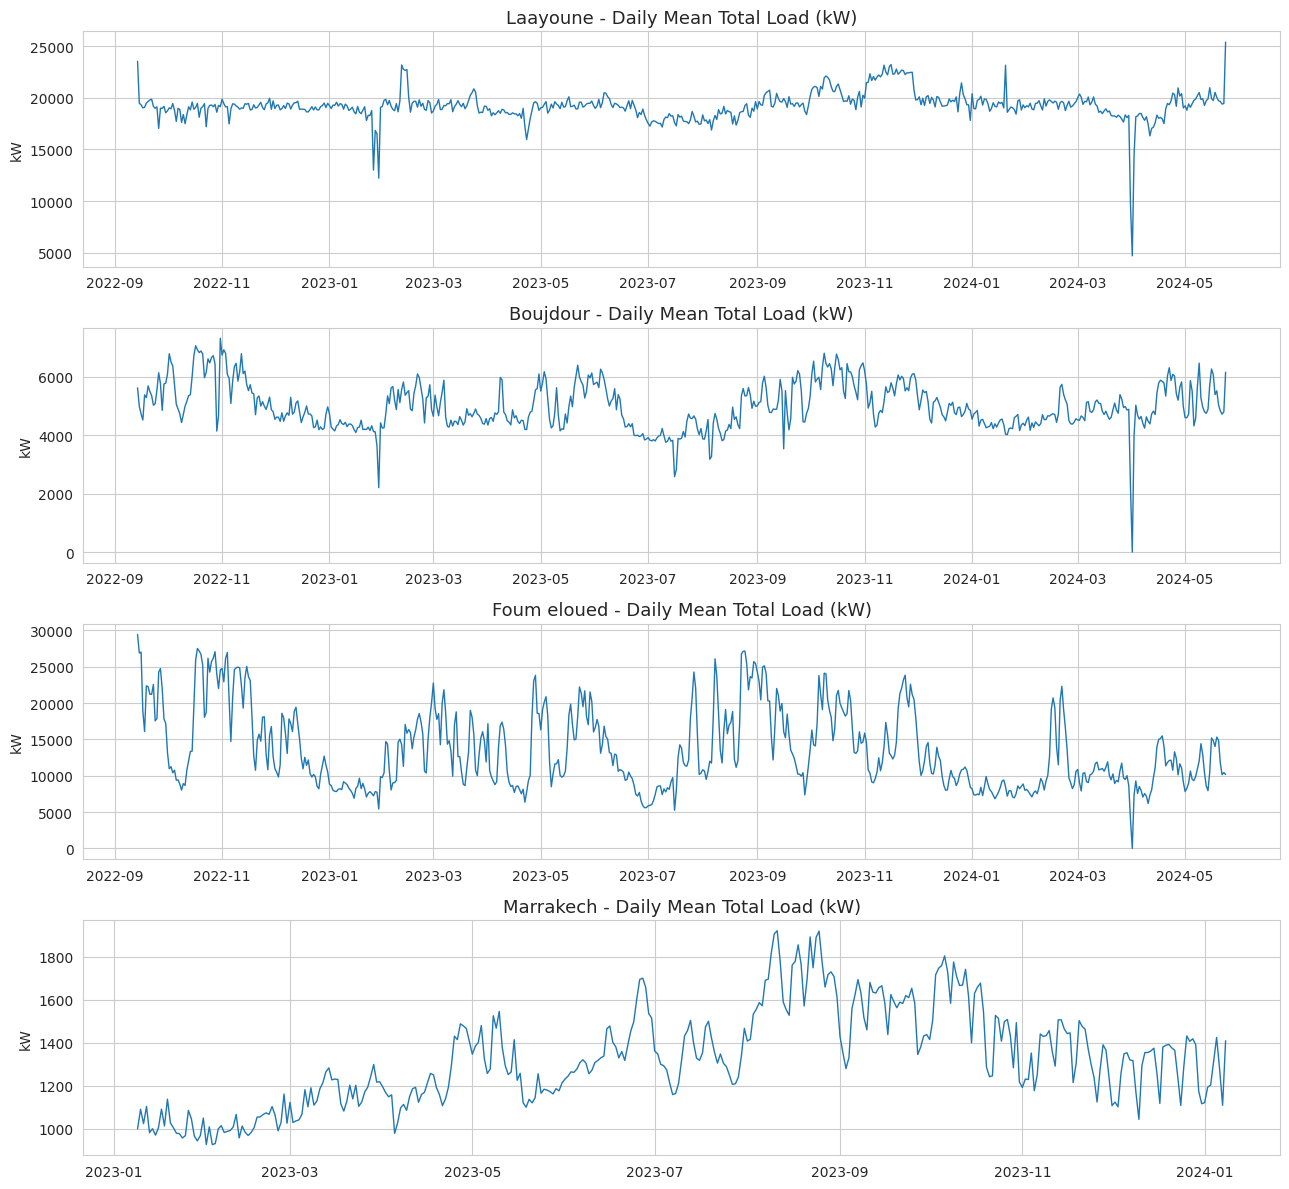

In [ ]:
# ------------------------------------------------------------
# Create subplots: one row per city (daily load series)
# ------------------------------------------------------------
fig, axes = plt.subplots(
    len(daily.columns),              # number of rows = number of cities
    1,                               # one column (single plot per row)
    figsize=(13, 3 * len(daily.columns)),  # figure size scales with number of cities
    sharex=False                     # each subplot has its own x-axis
)

# ------------------------------------------------------------
# Loop through each subplot and plot daily mean load for each city
# ------------------------------------------------------------
for ax, city in zip(axes, daily.columns):
    # Plot daily mean total load (kW) for the city
    ax.plot(daily.index, daily[city], lw=1)

    # Add title showing city name
    ax.set_title(f"{city} - Daily Mean Total Load (kW)")

    # Label y-axis as kilowatts
    ax.set_ylabel("kW")

# ------------------------------------------------------------
# Adjust layout to prevent overlap and improve readability
# ------------------------------------------------------------
plt.tight_layout()

# Display the plots
plt.show()


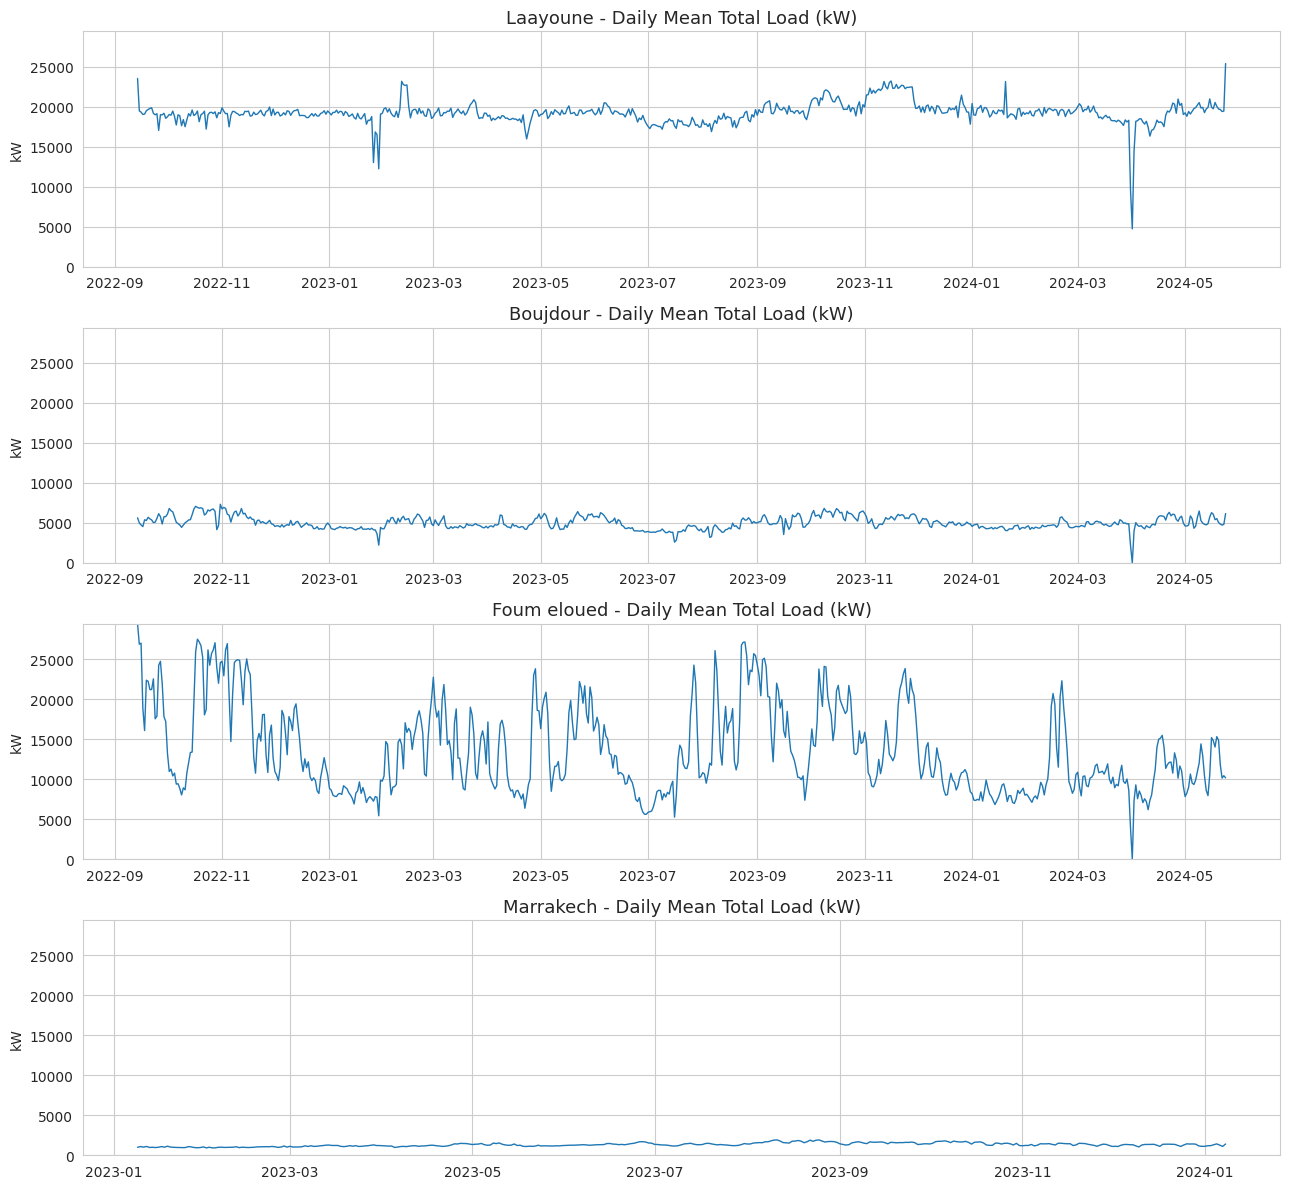

In [ ]:
# ------------------------------------------------------------
# Create subplots: one row per city (daily load series)
# ------------------------------------------------------------
fig, axes = plt.subplots(
    len(daily.columns),              # number of rows = number of cities
    1,                               # one column (single plot per row)
    figsize=(13, 3 * len(daily.columns)),  # figure size scales with number of cities
    sharex=False,                    # each subplot has its own x-axis
    sharey=True                      # all subplots share the same y-axis scale
)

# ------------------------------------------------------------
# Determine global maximum load across all cities
# ------------------------------------------------------------
ymax = daily.max().max()   # ensures consistent y-axis limits for comparison

# ------------------------------------------------------------
# Loop through each subplot and plot daily mean load for each city
# ------------------------------------------------------------
for ax, city in zip(axes, daily.columns):
    # Plot daily mean total load (kW) for the city
    ax.plot(daily.index, daily[city], lw=1)

    # Add title showing city name
    ax.set_title(f"{city} - Daily Mean Total Load (kW)")

    # Label y-axis as kilowatts
    ax.set_ylabel("kW")

    # Apply consistent y-axis scale across all subplots
    ax.set_ylim(0, ymax)

# ------------------------------------------------------------
# Adjust layout to prevent overlap and improve readability
# ------------------------------------------------------------
plt.tight_layout()

# Display the plots
plt.show()

> Plots the daily mean total load time-series for each city on separate axes, making long-term trends, seasonal swings, and sudden demand spikes visually apparent.

### **3. Per-zone time series within each city**

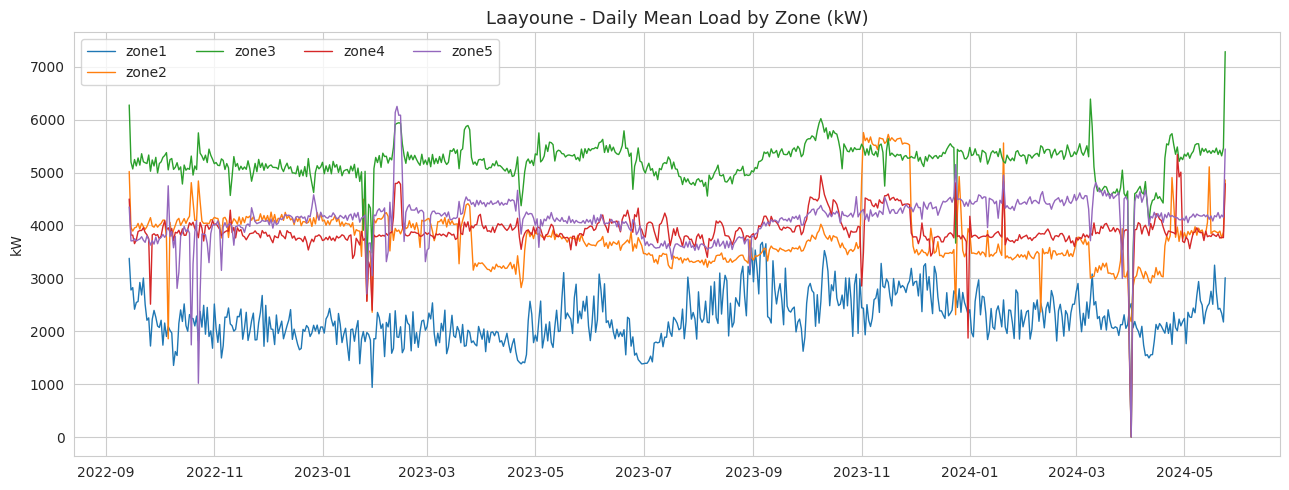

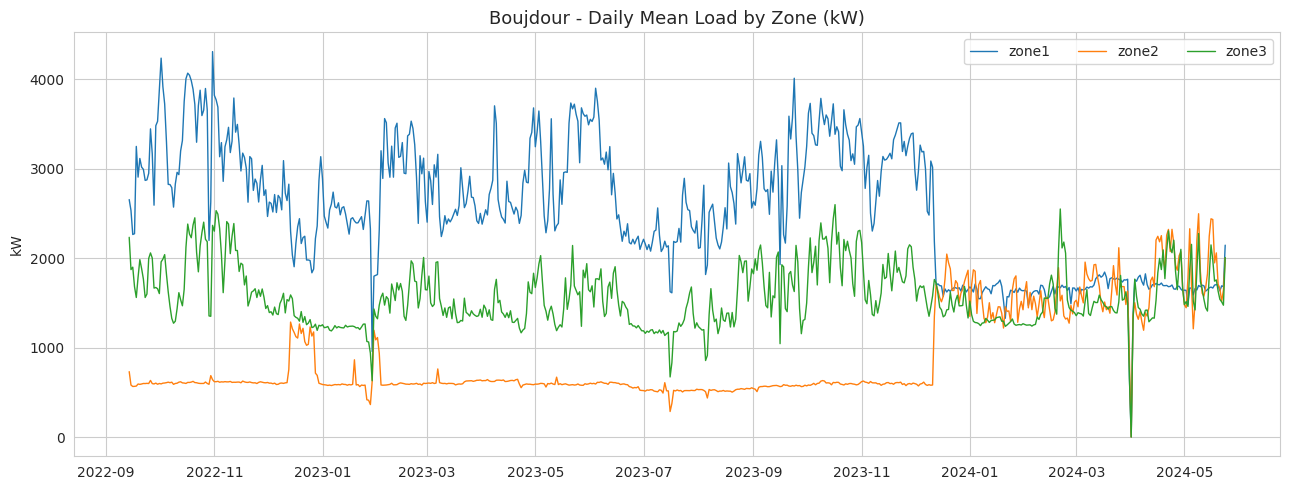

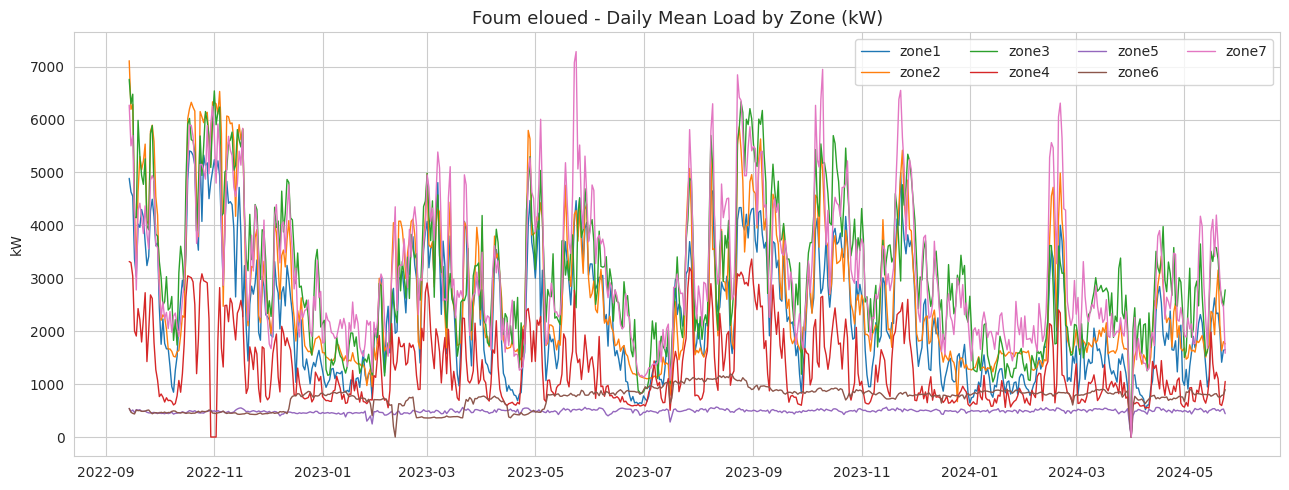

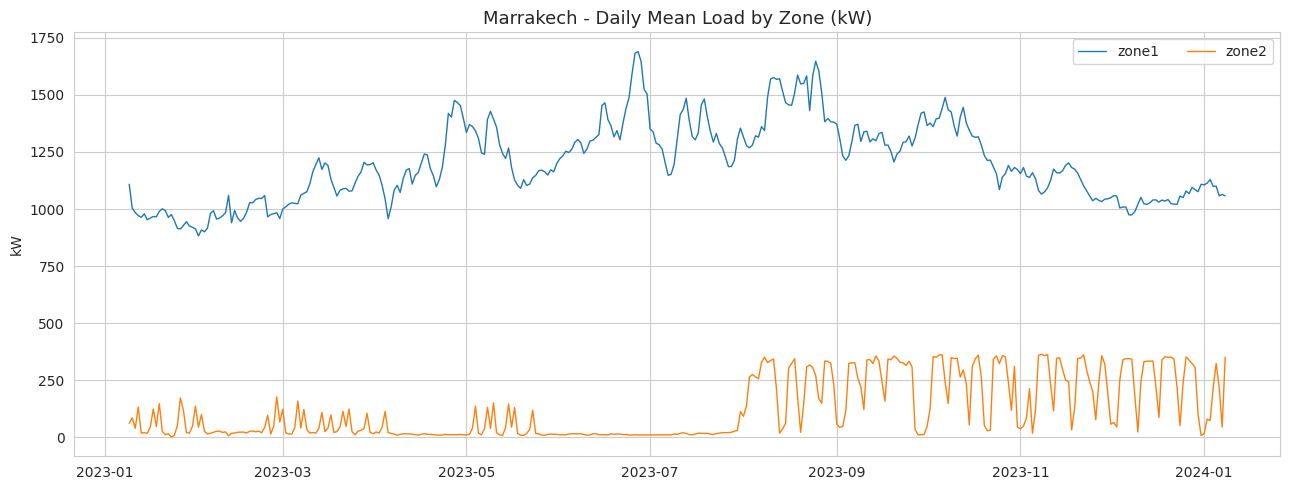

In [ ]:
# ------------------------------------------------------------
# Loop through each city dataset to plot daily mean load by zone
# ------------------------------------------------------------
for city, df in city_data.items():
    # Collect zone columns (already converted to kW)
    zone_cols = [f"{z}_kW" for z in CITY_ZONES[city]]

    # Resample each zone’s load to daily frequency (mean per day)
    daily_zones = df[zone_cols].resample("D").mean()

    # Create a new figure for the current city
    plt.figure()

    # ------------------------------------------------------------
    # Plot each zone’s daily mean load on the same figure
    # ------------------------------------------------------------
    for col in zone_cols:
        # Plot zone load with line width = 1
        plt.plot(daily_zones.index, daily_zones[col], lw=1, label=col.replace("_kW", ""))

    # Add informative title with city name
    plt.title(f"{city} - Daily Mean Load by Zone (kW)")

    # Label y-axis as kilowatts
    plt.ylabel("kW")

    # Add legend with up to 4 columns (for readability if many zones)
    plt.legend(ncol=min(len(zone_cols), 4))

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Display the plot
    plt.show()

> Plots daily mean load broken down by individual zone within each city, showing which zones dominate consumption and how zone-level patterns differ inside each region.

### **4. Average daily load profile (peak-hour identification)**

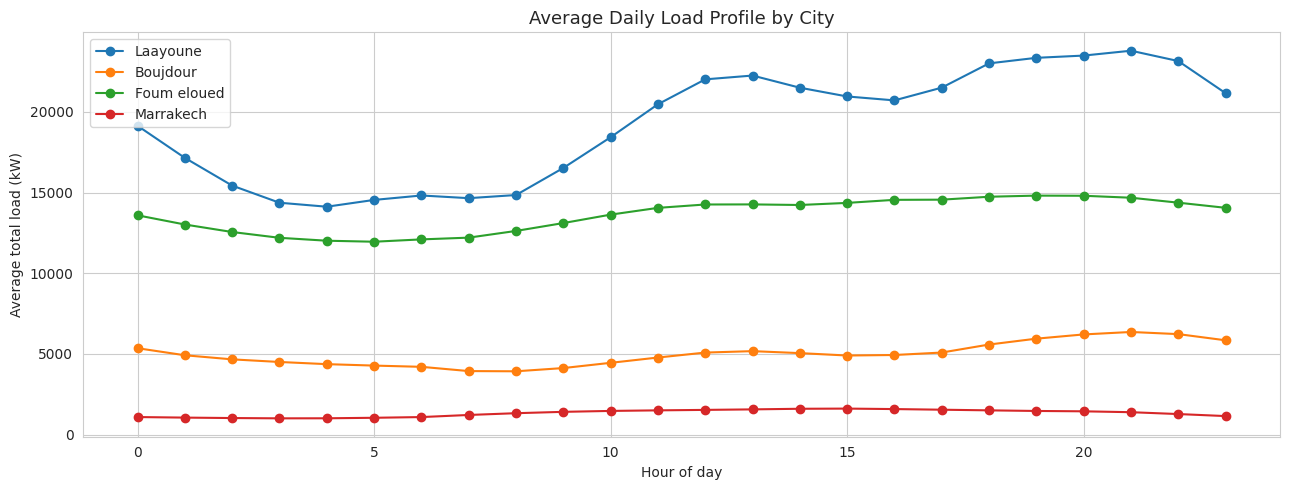

Peak average-load hour per city:
  Laayoune       : 21:00  (23794.2 kW)
  Boujdour       : 21:00  (6357.6 kW)
  Foum eloued    : 19:00  (14810.9 kW)
  Marrakech      : 15:00  (1607.5 kW)


In [ ]:
# ------------------------------------------------------------
# Compute average daily load profile by hour across all cities
# ------------------------------------------------------------

# Copy the standardized dataset (total load per city)
hourly = standardised.copy()

# Extract the hour of day from the timestamp index
hourly["hour"] = hourly.index.hour

# Group by hour and compute mean load across all days
hour_avg = hourly.groupby("hour").mean()

# ------------------------------------------------------------
# Plot average daily load profile for each city
# ------------------------------------------------------------
plt.figure()

# Loop through each city and plot its average hourly load
for city in standardised.columns:
    plt.plot(hour_avg.index, hour_avg[city], marker="o", label=city)

# Label axes
plt.xlabel("Hour of day")
plt.ylabel("Average total load (kW)")

# Add title and legend
plt.title("Average Daily Load Profile by City")
plt.legend()

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the plot
plt.show()

# ------------------------------------------------------------
# Print peak average-load hour for each city
# ------------------------------------------------------------
print("Peak average-load hour per city:")
for city in standardised.columns:
    # Find the hour with maximum average load
    peak_hour = hour_avg[city].idxmax()

    # Print city name, peak hour, and load value
    print(f"  {city:15s}: {peak_hour:02d}:00  ({hour_avg[city].max():.1f} kW)")

In [ ]:
print(hour_avg)

          Laayoune     Boujdour   Foum eloued    Marrakech
hour                                                      
0     19140.260460  5350.722477  13589.962058  1083.409589
1     17150.722098  4914.214599  13019.944376  1049.097945
2     15431.808540  4659.900437  12554.902606  1021.755479
3     14370.173694  4497.780541  12195.662237  1003.471233
4     14122.917120  4362.921035  12015.090290  1006.686301
5     14544.241101  4273.935453  11952.533708  1038.380822
6     14818.652981  4197.028266  12097.304915  1082.246575
7     14653.275833  3933.246493  12205.907777  1212.647945
8     14847.070558  3920.111952  12621.460840  1322.304110
9     16525.416252  4120.486779  13109.551733  1406.400000
10    18430.366130  4445.282127  13632.587987  1463.469863
11    20474.470056  4773.730330  14051.451444  1498.530137
12    22019.020899  5080.572551  14260.688988  1527.153425
13    22254.733920  5169.648186  14266.395311  1559.015068
14    21500.893930  5046.795539  14230.066892  1597.0246

> Computes the average load for each hour of the day and overlays all four cities on one chart; peak-demand hours (21:00 for Laâyoune/Boujdour, 19:00 for Foum Eloued, 15:00 for Marrakech) are printed below.

### **5. Weekly pattern (day of week)**

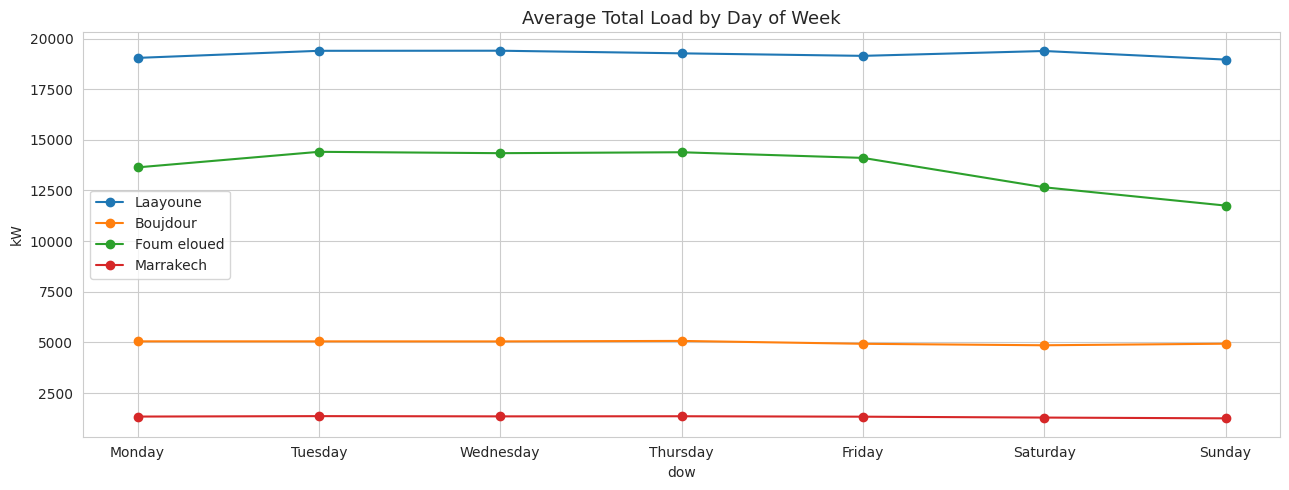

In [ ]:
# ------------------------------------------------------------
# Compute average load by day of the week across all cities
# ------------------------------------------------------------

# Copy the standardized dataset (total load per city)
dow = standardised.copy()

# Extract day of week names from the timestamp index
dow["dow"] = dow.index.day_name()

# Define the order of days (to keep plots consistent and readable)
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Group by day of week and compute mean load, reindex to match defined order
dow_avg = dow.groupby("dow").mean().reindex(dow_order)

# ------------------------------------------------------------
# Plot average total load by day of week for each city
# ------------------------------------------------------------
dow_avg.plot(marker="o")   # line plot with markers for clarity

# Add title and labels
plt.title("Average Total Load by Day of Week")
plt.ylabel("kW")

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
print(dow_avg)

               Laayoune     Boujdour   Foum eloued    Marrakech
dow                                                            
Monday     19044.106344  5051.847569  13639.355398  1338.006682
Tuesday    19393.625313  5050.608544  14407.393715  1360.149840
Wednesday  19398.166917  5048.266102  14340.148863  1347.986779
Thursday   19268.663562  5072.764380  14386.032655  1354.063702
Friday     19144.274415  4930.184322  14107.570721  1332.500000
Saturday   19383.916793  4857.649020  12655.951150  1288.828926
Sunday     18960.564974  4934.770388  11753.307138  1250.755208


> Averages load by day of the week for all cities and plots them together, revealing mid-week peaks and weekend dips that confirm the 7-day seasonal cycle used in SARIMA and the lag-feature window.



## **[8] Modelling & Evaluation**

**Models Selected and Why**

| Model | Family | Reason for Selection |
|---|---|---|
| **ARIMA** | Classical Statistical | Standard time-series baseline; captures linear autocorrelation and trend via AR, I, MA components |
| **SARIMA** | Classical Statistical | Extends ARIMA with explicit weekly seasonality (s = 7 days), confirmed by EDA heatmaps |
| **Random Forest** | Ensemble ML | Handles non-linear load patterns; robust through ensemble averaging; minimal hyperparameter tuning required |
| **XGBoost** | Gradient Boosting ML | Iteratively corrects residuals with built-in regularisation; strongest performer in recent load forecasting literature |
| **LSTM** | Deep Learning | Gated recurrent architecture retains long-range temporal dependencies that tree-based models cannot sequence-model natively |

**Original Study Comparison**

The dataset source paper (**Bensalah et al., 2025**, *Data in Brief*, DOI: 10.1016/j.dib.2025.112067) is a **data descriptor only** it presents no forecasting models.  
The companion paper (**Bensalah & Hair, 2025** *Machine Learning-Driven Load Forecasting for Urban Energy Optimization in Morocco*) performs actual modelling, but its full text was not publicly accessible; a direct model-for-model comparison therefore cannot be drawn.

### **1. Data preparation for modelling**

**Ramadan Load Comparison**

Checks whether mean daily load actually differs between Ramadan and non-Ramadan periods across the four cities, before relying on `is_ramadan` as a SHAP feature.

             Non-Ramadan Mean (kW)  Ramadan Mean (kW)  Change (%)
Laayoune                   19336.4            18218.7       -5.78
Boujdour                    5031.0             4634.9       -7.87
Foum eloued                13928.5            10697.6      -23.20
Marrakech                   1339.1             1163.6      -13.11


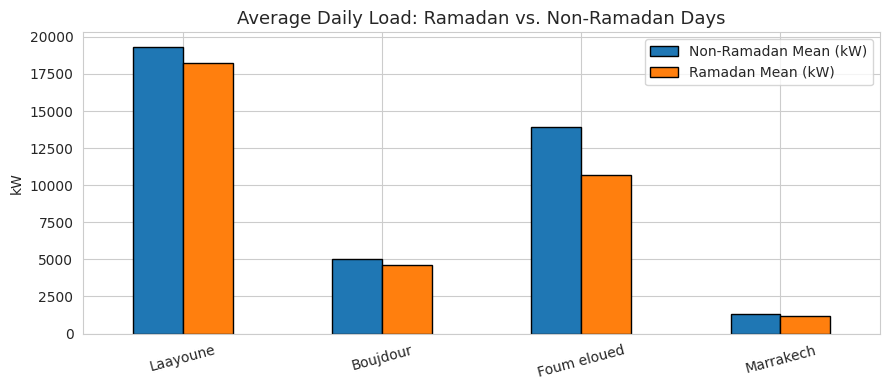

In [ ]:
# ------------------------------------------------------------
# Define Ramadan periods (1444 AH and 1445 AH) for analysis
# ------------------------------------------------------------
#     Ramadan 1444 AH : 22 March 2023 -> 21 April 2023
#     Ramadan 1445 AH : 10 March 2024 ->  9 April 2024
RAMADAN_PERIODS = [
    (pd.Timestamp("2023-03-22"), pd.Timestamp("2023-04-21")),
    (pd.Timestamp("2024-03-10"), pd.Timestamp("2024-04-09")),
]

# ------------------------------------------------------------
# Function to flag whether a given date falls in Ramadan
# ------------------------------------------------------------
def is_ramadan_date(dates: pd.DatetimeIndex) -> np.ndarray:
    """Return a 0/1 array: 1 if the date falls inside a Ramadan period."""
    flags = np.zeros(len(dates), dtype=int)
    for start, end in RAMADAN_PERIODS:
        # Mark dates within Ramadan as 1
        flags |= ((dates >= start) & (dates <= end)).astype(int)
    return flags

# ------------------------------------------------------------
# Create a boolean mask for Ramadan days in the dataset
# ------------------------------------------------------------
ramadan_mask = pd.Series(
    is_ramadan_date(standardised.index).astype(bool),
    index=standardised.index
)

# ------------------------------------------------------------
# Compute average loads for Ramadan vs. non-Ramadan days
# ------------------------------------------------------------
ramadan_avg     = standardised[ramadan_mask].mean()
non_ramadan_avg = standardised[~ramadan_mask].mean()

# Percentage change between Ramadan and non-Ramadan averages
pct_change = (ramadan_avg - non_ramadan_avg) / non_ramadan_avg * 100

# ------------------------------------------------------------
# Build comparison DataFrame for reporting
# ------------------------------------------------------------
comparison = pd.DataFrame({
    "Non-Ramadan Mean (kW)": non_ramadan_avg.round(1),
    "Ramadan Mean (kW)":     ramadan_avg.round(1),
    "Change (%)":            pct_change.round(2),
})

# Print the comparison table
print(comparison)

# ------------------------------------------------------------
# Plot Ramadan vs. Non-Ramadan average daily load
# ------------------------------------------------------------
comparison[["Non-Ramadan Mean (kW)", "Ramadan Mean (kW)"]].plot(
    kind="bar", figsize=(9, 4), edgecolor="black"
)
plt.title("Average Daily Load: Ramadan vs. Non-Ramadan Days")
plt.ylabel("kW")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


> Computes and plots the mean daily load during Ramadan periods vs. all other days for each city, with percentage change; this justifies (or challenges) the inclusion of `is_ramadan` as a predictive feature ahead of the modelling and SHAP sections.

In [ ]:
# ------------------------------------------------------------
# Import required preprocessing tools from scikit-learn
# ------------------------------------------------------------
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Define split ratios and lag parameters
# ------------------------------------------------------------
TRAIN_RATIO = 0.70   # 70% of data for training
VAL_RATIO   = 0.15   # 15% of data for validation
TEST_RATIO  = 0.15   # 15% of data for testing
LAGS = 14            # lagged features used for ML/DL models (2 weeks)

# Ensure ratios sum to 1.0 (sanity check)
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9

# Dictionary to store splits and scalers for each city
city_splits = {}   # {city: {train, val, test, scaler, ...}}

# ------------------------------------------------------------
# Loop through each city and perform train/val/test split
# ------------------------------------------------------------
for city in city_data:
    # Extract daily load series for the city (drop missing values)
    series = daily[city].dropna()

    # Step 1: Split TRAIN vs. (VAL+TEST). shuffle=False preserves time order
    train, rest = train_test_split(
        series, train_size=TRAIN_RATIO, shuffle=False
    )

    # Step 2: Split remainder into VAL vs. TEST
    # Since VAL_RATIO and TEST_RATIO are equal, this is a 50/50 split of the remainder
    val_size_of_rest = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
    val, test = train_test_split(
        rest, train_size=val_size_of_rest, shuffle=False
    )

    # ------------------------------------------------------------
    # Scale values using MinMaxScaler (fit only on TRAIN to avoid leakage)
    # ------------------------------------------------------------
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
    val_scaled   = scaler.transform(val.values.reshape(-1, 1)).flatten()
    test_scaled  = scaler.transform(test.values.reshape(-1, 1)).flatten()

    # Store results in dictionary for later use
    city_splits[city] = {
        "series": series,
        "train": train,
        "val": val,
        "test": test,
        "train_scaled": train_scaled,
        "val_scaled": val_scaled,
        "test_scaled": test_scaled,
        "scaler": scaler,
    }

    # ------------------------------------------------------------
    # Print summary of split sizes and proportions
    # ------------------------------------------------------------
    n = len(series)
    print(f"{city:15s}: train={len(train):>4d}d ({len(train)/n:5.1%})  "
          f"val={len(val):>4d}d ({len(val)/n:5.1%})  "
          f"test={len(test):>4d}d ({len(test)/n:5.1%})")

Laayoune       : train= 433d (70.0%)  val=  93d (15.0%)  test=  93d (15.0%)
Boujdour       : train= 433d (70.0%)  val=  93d (15.0%)  test=  93d (15.0%)
Foum eloued    : train= 433d (70.0%)  val=  93d (15.0%)  test=  93d (15.0%)
Marrakech      : train= 255d (69.9%)  val=  55d (15.1%)  test=  55d (15.1%)


> Converts each city's daily `total_kW` series into chronological **train (70%) / validation (15%) / test (15%)** blocks using `sklearn.model_selection.train_test_split` with `shuffle=False` (twice, to carve three blocks out of one ordered series). A `MinMaxScaler` is fit on the training block only and applied to validation and test. The validation block now exists specifically to support LSTM early-stopping/hyperparameter selection and a light Random Forest / XGBoost hyperparameter search, replacing the old fixed 90-day test cut-off.

### **2. Feature engineering (ML / DL)**

In [ ]:
# ------------------------------------------------------------
# Build supervised datasets with lag features
# ------------------------------------------------------------
# Two feature sets are produced:
#   1. LAG-ONLY arrays (X_tr / X_val / X_te)
#      -> used by sequence models (LSTM/GRU) which expect homogeneous
#         time-ordered input channels.
#   2. EXTENDED arrays (Xf_tr / Xf_val / Xf_te)
#      -> used by Random Forest / XGBoost, and later SHAP.
#         These include lag + calendar + Ramadan + rolling-stat features.

def make_lag_features(arr: np.ndarray, n_lags: int = LAGS):
    """
    Return (X, y) where:
      - X[i] = arr[i:i+n_lags]  (lag window)
      - y[i] = arr[i+n_lags]    (prediction target)
    """
    X, y = [], []
    for i in range(len(arr) - n_lags):
        X.append(arr[i:i + n_lags])
        y.append(arr[i + n_lags])
    return np.array(X), np.array(y)


def make_extended_features(scaled_arr: np.ndarray, dates: pd.DatetimeIndex, n_lags: int = LAGS):
    """
    Return (X, y, feature_names) where X includes:
      - lag-1d ... lag-Nd
      - day_of_week, month, is_weekend (calendar/seasonal signals)
      - is_ramadan (religious/cultural demand shift)
      - roll_mean_7d, roll_std_7d (short-term trend/volatility)
    Notes:
      - `dates` must align 1:1 with `scaled_arr` (target’s date index).
      - Calendar/Ramadan features describe the day being predicted (y),
        not the lag window itself.
    """
    # Build lag-only features first
    X_lag, y = make_lag_features(scaled_arr, n_lags)
    target_dates = dates[n_lags:]  # date of each prediction target

    # Calendar features
    dow = target_dates.dayofweek.values
    month = target_dates.month.values
    is_weekend = (dow >= 5).astype(int)
    is_ramadan = is_ramadan_date(target_dates)   # defined earlier in EDA

    # Rolling mean/std over trailing 7 lag values (no leakage)
    roll_mean_7 = X_lag[:, -7:].mean(axis=1)
    roll_std_7  = X_lag[:, -7:].std(axis=1)

    # Combine lag + extra features
    extra = np.column_stack([dow, month, is_weekend, is_ramadan, roll_mean_7, roll_std_7])
    X = np.hstack([X_lag, extra])

    # Define feature names
    feature_names = ([f"lag-{i+1}d" for i in range(n_lags)] +
                     ["day_of_week", "month", "is_weekend", "is_ramadan",
                      "roll_mean_7d", "roll_std_7d"])
    return X, y, feature_names


# ------------------------------------------------------------
# Build lag-only and extended feature arrays for each city
# ------------------------------------------------------------
FEATURE_NAMES = None
for city, sp in city_splits.items():
    # Lag-only arrays (for LSTM / GRU)
    X_tr,  y_tr  = make_lag_features(sp["train_scaled"])
    X_val, y_val = make_lag_features(sp["val_scaled"])
    X_te,  y_te  = make_lag_features(sp["test_scaled"])
    sp["X_tr"],  sp["y_tr"]  = X_tr,  y_tr
    sp["X_val"], sp["y_val"] = X_val, y_val
    sp["X_te"],  sp["y_te"]  = X_te,  y_te

    # Extended arrays (lags + calendar + Ramadan + rolling stats)
    Xf_tr,  yf_tr,  fn = make_extended_features(sp["train_scaled"], sp["train"].index)
    Xf_val, yf_val, _  = make_extended_features(sp["val_scaled"],   sp["val"].index)
    Xf_te,  yf_te,  _  = make_extended_features(sp["test_scaled"],  sp["test"].index)
    sp["Xf_tr"],  sp["yf_tr"]  = Xf_tr,  yf_tr
    sp["Xf_val"], sp["yf_val"] = Xf_val, yf_val
    sp["Xf_te"],  sp["yf_te"]  = Xf_te,  yf_te
    FEATURE_NAMES = fn

    # Count Ramadan-day samples in training set
    n_ramadan_train = int(Xf_tr[:, fn.index("is_ramadan")].sum())
    print(f"{city:15s}: {n_ramadan_train} Ramadan-day samples in training set")

# ------------------------------------------------------------
# Diagnostics: confirm arrays built and show example shapes
# ------------------------------------------------------------
print("\nLag-only arrays built (n_lags =", LAGS, ") for LSTM/GRU")
print("Extended arrays built (lags + calendar + is_ramadan + rolling stats) for RF/XGBoost/SHAP")
print("Feature names:", FEATURE_NAMES)
print("Example shape -- Laayoune X_tr (lag-only):", city_splits["Laayoune"]["X_tr"].shape)
print("Example shape -- Laayoune Xf_tr (extended):", city_splits["Laayoune"]["Xf_tr"].shape)

Laayoune       : 31 Ramadan-day samples in training set
Boujdour       : 31 Ramadan-day samples in training set
Foum eloued    : 31 Ramadan-day samples in training set
Marrakech      : 31 Ramadan-day samples in training set

Lag-only arrays built (n_lags = 14 ) for LSTM/GRU
Extended arrays built (lags + calendar + is_ramadan + rolling stats) for RF/XGBoost/SHAP
Feature names: ['lag-1d', 'lag-2d', 'lag-3d', 'lag-4d', 'lag-5d', 'lag-6d', 'lag-7d', 'lag-8d', 'lag-9d', 'lag-10d', 'lag-11d', 'lag-12d', 'lag-13d', 'lag-14d', 'day_of_week', 'month', 'is_weekend', 'is_ramadan', 'roll_mean_7d', 'roll_std_7d']
Example shape -- Laayoune X_tr (lag-only): (419, 14)
Example shape -- Laayoune Xf_tr (extended): (419, 20)


> Builds two supervised feature sets from the same 14-day sliding window: a **lag-only** array (for LSTM/GRU) and an **extended** array — lags + `day_of_week` + `month` + `is_weekend` + **`is_ramadan`** + `roll_mean_7d` + `roll_std_7d` — for Random Forest/XGBoost/SHAP. `is_ramadan` is a new binary flag (1 if the target date falls inside Morocco's Ramadan 2023 or Ramadan 2024 period, else 0), added because Ramadan is known to shift Moroccan electricity demand curves through reduced daytime activity and a post-Iftar evening spike.

In [ ]:
# ------------------------------------------------------------
# Import evaluation metrics from scikit-learn
# ------------------------------------------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------------
# Function to evaluate model predictions using RMSE, MAE, and MAPE
# ------------------------------------------------------------
def evaluate(y_true: np.ndarray, y_pred: np.ndarray, label: str = "") -> dict:
    # Root Mean Squared Error (RMSE): penalizes larger errors more heavily
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    # Mean Absolute Error (MAE): average absolute difference between predictions and actuals
    mae  = float(mean_absolute_error(y_true, y_pred))

    # Mean Absolute Percentage Error (MAPE):
    # Avoid division by zero by masking out zero-actual entries
    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

    # Print formatted results if a label is provided (e.g., model name)
    if label:
        print(f"  {label:25s}  RMSE={rmse:10.2f}  MAE={mae:10.2f}  MAPE={mape:6.2f}%")

    # Return metrics as a dictionary for programmatic use
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape}

> Defines the `evaluate()` that computes RMSE, MAE, and MAPE in original kW units for any (true, predicted) pair, with a zero-guard in MAPE to prevent division errors.



### **3. ARIMA Baseline**

In [ ]:
# ------------------------------------------------------------
# ARIMA model fitting for each city
# ------------------------------------------------------------
# Notes:
# - ARIMA is fit on the un-scaled training series (in kW).
# - Order (p,d,q) is selected via AIC using a constrained grid search
#   to keep runtime tractable.
# - Best order and AIC are printed for transparency.

from statsmodels.tsa.arima.model import ARIMA
import itertools

# Define grid of candidate (p,d,q) orders
ARIMA_GRID = list(itertools.product(range(3), [0, 1], range(3)))   # (p,d,q)

# Dictionary to store ARIMA results per city
results_arima = {}

# ------------------------------------------------------------
# Loop through each city and fit ARIMA
# ------------------------------------------------------------
for city, sp in city_splits.items():
    print(f"\n--- ARIMA  |  {city} ---")
    train_vals = sp["train"].values   # unscaled training series

    best_aic, best_order, best_model = np.inf, None, None

    # Grid search over candidate orders
    for order in ARIMA_GRID:
        try:
            # Fit ARIMA model with given order
            m = ARIMA(train_vals, order=order).fit(method_kwargs={"warn_convergence": False})

            # Track best model by lowest AIC
            if m.aic < best_aic:
                best_aic, best_order, best_model = m.aic, order, m
        except Exception:
            # Skip invalid orders or convergence failures
            continue

    # Print best order and AIC for the city
    print(f"  Best order {best_order}  AIC={best_aic:.1f}")

    # ------------------------------------------------------------
    # Forecast n_test steps ahead using best model
    # ------------------------------------------------------------
    fc = best_model.forecast(steps=len(sp["test"]))

    # Evaluate forecast against test set
    metrics = evaluate(sp["test"].values, fc, f"ARIMA{best_order}")

    # Store results in dictionary
    results_arima[city] = {"order": best_order, "forecast": fc, **metrics}


--- ARIMA  |  Laayoune ---
  Best order (1, 1, 1)  AIC=6923.5
  ARIMA(1, 1, 1)             RMSE=   4229.48  MAE=   3704.35  MAPE= 23.59%

--- ARIMA  |  Boujdour ---
  Best order (2, 1, 2)  AIC=6491.3
  ARIMA(2, 1, 2)             RMSE=   1044.39  MAE=    792.66  MAPE= 16.40%

--- ARIMA  |  Foum eloued ---
  Best order (2, 1, 1)  AIC=7997.5
  ARIMA(2, 1, 1)             RMSE=   6754.67  MAE=   6236.79  MAPE= 66.72%

--- ARIMA  |  Marrakech ---
  Best order (1, 1, 1)  AIC=2923.8
  ARIMA(1, 1, 1)             RMSE=    308.78  MAE=    284.63  MAPE= 23.02%


> Fits ARIMA on each city's unscaled training series; order (p, d, q) is chosen by AIC grid search over all combinations with p, q ≤ 2 and d ≤ 1; the best order and its AIC are printed before the held-out test forecast is generated.



### **4. SARIMA Baseline**

In [ ]:
# ------------------------------------------------------------
# SARIMA model fitting for each city
# ------------------------------------------------------------
# Notes:
# - SARIMA adds a seasonal component (s=7 for weekly seasonality on daily data).
# - Grid search is performed over small seasonal AR/MA orders to keep compute time reasonable.
# - Trend order is fixed at (1,1,1); seasonal orders vary.
# - Best configuration is selected by lowest AIC.

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define candidate trend and seasonal orders
SARIMA_TREND = [(1, 1, 1)]                 # fixed trend order
SARIMA_SEASON = list(itertools.product(range(2), [1], range(2), [7]))  # seasonal (p,d,q,s)

# Dictionary to store SARIMA results per city
results_sarima = {}

# ------------------------------------------------------------
# Loop through each city and fit SARIMA
# ------------------------------------------------------------
for city, sp in city_splits.items():
    print(f"\n--- SARIMA  |  {city} ---")
    train_vals = sp["train"].values   # unscaled training series

    best_aic, best_cfg, best_model = np.inf, None, None

    # Grid search over candidate seasonal orders
    for trend_ord in SARIMA_TREND:
        for seas_ord in SARIMA_SEASON:
            try:
                # Fit SARIMA model with given configuration
                m = SARIMAX(train_vals,
                            order=trend_ord,
                            seasonal_order=seas_ord,
                            enforce_stationarity=False,
                            enforce_invertibility=False).fit(disp=False)

                # Track best model by lowest AIC
                if m.aic < best_aic:
                    best_aic, best_cfg, best_model = m.aic, (trend_ord, seas_ord), m
            except Exception:
                # Skip invalid configurations or convergence failures
                continue

    # Print best configuration and AIC for the city
    print(f"  Best cfg trend={best_cfg[0]}  seasonal={best_cfg[1]}  AIC={best_aic:.1f}")

    # ------------------------------------------------------------
    # Forecast n_test steps ahead using best model
    # ------------------------------------------------------------
    fc = best_model.forecast(steps=len(sp["test"]))

    # Evaluate forecast against test set
    metrics = evaluate(sp["test"].values, fc, f"SARIMA{best_cfg[0]}{best_cfg[1]}")

    # Store results in dictionary
    results_sarima[city] = {"cfg": best_cfg, "forecast": fc, **metrics}


--- SARIMA  |  Laayoune ---
  Best cfg trend=(1, 1, 1)  seasonal=(1, 1, 1, 7)  AIC=6701.1
  SARIMA(1, 1, 1)(1, 1, 1, 7)  RMSE=   4786.08  MAE=   4327.90  MAPE= 27.01%

--- SARIMA  |  Boujdour ---
  Best cfg trend=(1, 1, 1)  seasonal=(1, 1, 1, 7)  AIC=6261.7
  SARIMA(1, 1, 1)(1, 1, 1, 7)  RMSE=   1095.96  MAE=    846.82  MAPE= 17.65%

--- SARIMA  |  Foum eloued ---
  Best cfg trend=(1, 1, 1)  seasonal=(0, 1, 1, 7)  AIC=7720.4
  SARIMA(1, 1, 1)(0, 1, 1, 7)  RMSE=  13422.70  MAE=  12798.36  MAPE=131.34%

--- SARIMA  |  Marrakech ---
  Best cfg trend=(1, 1, 1)  seasonal=(0, 1, 1, 7)  AIC=2746.5
  SARIMA(1, 1, 1)(0, 1, 1, 7)  RMSE=    281.80  MAE=    258.25  MAPE= 20.86%


> Extends ARIMA with a seasonal component (s = 7 days for weekly periodicity); trend and seasonal orders are both AIC-selected via constrained grid search; direct multi-step forecasts (length = test-set size) are produced without re-fitting on test data.



### **5. Random Forest Model**

In [ ]:
# ------------------------------------------------------------
# Random Forest model fitting for each city
# ------------------------------------------------------------
# Notes:
# - Trains on the EXTENDED feature set (lags + calendar + Ramadan + rolling stats).
# - Hyperparameter grid search is performed using the VALIDATION split
#   (test set remains unseen until final evaluation).
# - Best parameters are selected by lowest validation RMSE.

from sklearn.ensemble import RandomForestRegressor
import itertools as _it

# Define small hyperparameter grid
RF_GRID = {
    "n_estimators": [200, 300],   # number of trees
    "max_depth": [8, 10, 14],     # maximum depth of trees
    "min_samples_leaf": [1, 2],   # minimum samples per leaf
}

# Dictionary to store Random Forest results per city
results_rf = {}

# ------------------------------------------------------------
# Loop through each city and fit Random Forest
# ------------------------------------------------------------
for city, sp in city_splits.items():
    print(f"\n--- Random Forest  |  {city} ---")
    best_val_rmse, best_params, best_model = np.inf, None, None

    # Grid search over candidate hyperparameters
    for n_est, depth, leaf in _it.product(RF_GRID["n_estimators"],
                                          RF_GRID["max_depth"],
                                          RF_GRID["min_samples_leaf"]):
        params = {"n_estimators": n_est, "max_depth": depth,
                  "min_samples_leaf": leaf, "n_jobs": -1, "random_state": 42}

        # Train candidate model on training set
        cand = RandomForestRegressor(**params)
        cand.fit(sp["Xf_tr"], sp["yf_tr"])

        # Predict on validation set
        val_pred = cand.predict(sp["Xf_val"])

        # Compute validation RMSE (scaled values)
        val_rmse = np.sqrt(mean_squared_error(sp["yf_val"], val_pred))

        # Track best model by lowest validation RMSE
        if val_rmse < best_val_rmse:
            best_val_rmse, best_params, best_model = val_rmse, params, cand

    # Print best parameters found
    print(f"  Best params (by val RMSE={best_val_rmse:.4f} scaled): {best_params}")

    # ------------------------------------------------------------
    # Refit best model on TRAIN ONLY (test set remains unseen)
    # ------------------------------------------------------------
    rf = RandomForestRegressor(**best_params)
    rf.fit(sp["Xf_tr"], sp["yf_tr"])

    # Predict on test set (scaled)
    pred_scaled = rf.predict(sp["Xf_te"])

    # Inverse transform predictions and true values back to kW
    pred_kw = sp["scaler"].inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    true_kw = sp["scaler"].inverse_transform(sp["yf_te"].reshape(-1, 1)).flatten()

    # Evaluate predictions against true values
    metrics = evaluate(true_kw, pred_kw, "Random Forest")

    # Store results in dictionary
    results_rf[city] = {"model": rf, "pred_kw": pred_kw, "true_kw": true_kw,
                        "best_params": best_params, **metrics}


--- Random Forest  |  Laayoune ---
  Best params (by val RMSE=0.0677 scaled): {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 2, 'n_jobs': -1, 'random_state': 42}
  Random Forest              RMSE=   1889.23  MAE=    826.29  MAPE=  7.27%

--- Random Forest  |  Boujdour ---
  Best params (by val RMSE=0.0488 scaled): {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 1, 'n_jobs': -1, 'random_state': 42}
  Random Forest              RMSE=    757.42  MAE=    428.98  MAPE=  8.21%

--- Random Forest  |  Foum eloued ---
  Best params (by val RMSE=0.0641 scaled): {'n_estimators': 300, 'max_depth': 14, 'min_samples_leaf': 1, 'n_jobs': -1, 'random_state': 42}
  Random Forest              RMSE=   2257.82  MAE=   1663.74  MAPE= 16.07%

--- Random Forest  |  Marrakech ---
  Best params (by val RMSE=0.1200 scaled): {'n_estimators': 200, 'max_depth': 14, 'min_samples_leaf': 1, 'n_jobs': -1, 'random_state': 42}
  Random Forest              RMSE=    113.23  MAE=     89.48  MAPE=  7.1

> Searches a small Random Forest hyperparameter grid (`n_estimators`, `max_depth`, `min_samples_leaf`) against the **validation** split, then refits the best configuration on the training split and evaluates once on the held-out **test** split. Trains on the extended feature set (lags + calendar + rolling stats), not lags alone.


### **6. XGBoost Model**

In [ ]:
# ------------------------------------------------------------
# XGBoost model fitting for each city
# ------------------------------------------------------------
# Notes:
# - Trains on the EXTENDED feature set (lags + calendar + Ramadan + rolling stats).
# - Early stopping watches the VALIDATION split (not the test split, to avoid leakage).
# - Hyperparameter grid (max_depth, learning_rate) is searched against validation RMSE.
# - Best parameters are selected by lowest validation RMSE.

from xgboost import XGBRegressor

# Define small hyperparameter grid
XGB_GRID = {
    "max_depth": [4, 6],                 # tree depth
    "learning_rate": [0.03, 0.05, 0.1],  # step size shrinkage
}

# Dictionary to store XGBoost results per city
results_xgb = {}

# ------------------------------------------------------------
# Loop through each city and fit XGBoost
# ------------------------------------------------------------
for city, sp in city_splits.items():
    print(f"\n--- XGBoost  |  {city} ---")
    best_val_rmse, best_params, best_model = np.inf, None, None

    # Grid search over candidate hyperparameters
    for depth, lr in _it.product(XGB_GRID["max_depth"], XGB_GRID["learning_rate"]):
        params = {"n_estimators": 300, "max_depth": depth, "learning_rate": lr,
                  "subsample": 0.8, "colsample_bytree": 0.8,
                  "objective": "reg:squarederror", "random_state": 42,
                  "verbosity": 0, "device": "cpu"}

        # Candidate model with early stopping (monitors validation set)
        cand = XGBRegressor(**params, early_stopping_rounds=20)
        cand.fit(sp["Xf_tr"], sp["yf_tr"],
                 eval_set=[(sp["Xf_val"], sp["yf_val"])], verbose=False)

        # Predict on validation set
        val_pred = cand.predict(sp["Xf_val"])

        # Compute validation RMSE (scaled values)
        val_rmse = np.sqrt(mean_squared_error(sp["yf_val"], val_pred))

        # Track best model by lowest validation RMSE
        if val_rmse < best_val_rmse:
            best_val_rmse, best_params, best_model = val_rmse, params, cand

    # Print best parameters found
    print(f"  Best params (by val RMSE={best_val_rmse:.4f} scaled): "
          f"depth={best_params['max_depth']}, lr={best_params['learning_rate']}, "
          f"best_iteration={best_model.best_iteration}")

    # ------------------------------------------------------------
    # Reuse best model (already early-stopped on validation)
    # ------------------------------------------------------------
    xgb = best_model

    # Predict on test set (scaled)
    pred_scaled = xgb.predict(sp["Xf_te"])

    # Inverse transform predictions and true values back to kW
    pred_kw = sp["scaler"].inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    true_kw = sp["scaler"].inverse_transform(sp["yf_te"].reshape(-1, 1)).flatten()

    # Evaluate predictions against true values
    metrics = evaluate(true_kw, pred_kw, "XGBoost")

    # Store results in dictionary
    results_xgb[city] = {"model": xgb, "pred_kw": pred_kw, "true_kw": true_kw,
                         "best_params": best_params, **metrics}


--- XGBoost  |  Laayoune ---
  Best params (by val RMSE=0.0624 scaled): depth=4, lr=0.03, best_iteration=15
  XGBoost                    RMSE=   2173.34  MAE=   1008.88  MAPE=  8.74%

--- XGBoost  |  Boujdour ---
  Best params (by val RMSE=0.0488 scaled): depth=4, lr=0.03, best_iteration=102
  XGBoost                    RMSE=    745.33  MAE=    408.67  MAPE=  7.79%

--- XGBoost  |  Foum eloued ---
  Best params (by val RMSE=0.0593 scaled): depth=4, lr=0.05, best_iteration=77
  XGBoost                    RMSE=   2200.83  MAE=   1659.06  MAPE= 16.31%

--- XGBoost  |  Marrakech ---
  Best params (by val RMSE=0.1123 scaled): depth=4, lr=0.1, best_iteration=33
  XGBoost                    RMSE=    113.48  MAE=     91.82  MAPE=  7.52%


> Searches a small XGBoost hyperparameter grid (`max_depth`, `learning_rate`) with early stopping (`patience=20` rounds) monitored on the **validation** split -- not the test split, avoiding the leakage in the original version. The best configuration is evaluated once on the held-out test split, using the extended feature set (lags + calendar + rolling stats).

### **7. LSTM Model**

In [ ]:
# ------------------------------------------------------------
# LSTM model fitting for each city
# ------------------------------------------------------------
# Notes:
# - Trains on the LAG-ONLY feature set (sequence input).
# - Hyperparameter grid search is performed over units, dropout,
#   learning rate, and batch size.
# - Early stopping monitors the VALIDATION split (not the test set).
# - Best configuration is selected by lowest validation RMSE.

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import os

# Suppress TensorFlow warnings for cleaner output
tf.get_logger().setLevel("ERROR")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# ------------------------------------------------------------
# Define hyperparameter grid and training settings
# ------------------------------------------------------------
LSTM_GRID = [
    {"units": 64, "dropout": 0.2, "lr": 1e-3, "batch": 32},
    {"units": 32, "dropout": 0.2, "lr": 1e-3, "batch": 32},
    {"units": 64, "dropout": 0.3, "lr": 5e-4, "batch": 16},
]
LSTM_EPOCHS = 50
results_lstm = {}

# ------------------------------------------------------------
# Function to build LSTM model with given hyperparameters
# ------------------------------------------------------------
def build_lstm(units, dropout, lr):
    tf.random.set_seed(42)  # reproducibility
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(LAGS, 1)),
        Dropout(dropout),
        LSTM(units // 2),
        Dropout(dropout),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse")
    return model

# ------------------------------------------------------------
# Loop through each city and fit LSTM
# ------------------------------------------------------------
for city, sp in city_splits.items():
    print(f"\n--- LSTM  |  {city} ---")

    # Reshape lag-only arrays into 3D (samples, timesteps, features)
    X_tr_3d  = sp["X_tr"].reshape(*sp["X_tr"].shape, 1)
    X_val_3d = sp["X_val"].reshape(*sp["X_val"].shape, 1)
    X_te_3d  = sp["X_te"].reshape(*sp["X_te"].shape, 1)

    best_val_rmse, best_cfg, best_history, best_model = np.inf, None, None, None

    # Grid search over candidate hyperparameters
    for cfg in LSTM_GRID:
        model = build_lstm(cfg["units"], cfg["dropout"], cfg["lr"])
        es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

        # Train model on training set, validate on validation set
        history = model.fit(X_tr_3d, sp["y_tr"],
                            epochs=LSTM_EPOCHS, batch_size=cfg["batch"],
                            validation_data=(X_val_3d, sp["y_val"]),
                            callbacks=[es], verbose=0)

        # Predict on validation set
        val_pred = model.predict(X_val_3d, verbose=0).flatten()

        # Compute validation RMSE (scaled values)
        val_rmse = np.sqrt(mean_squared_error(sp["y_val"], val_pred))

        # Print diagnostics for each configuration
        print(f"    cfg={cfg}  val_RMSE(scaled)={val_rmse:.4f}  "
              f"epochs_run={len(history.history['loss'])}")

        # Track best configuration by lowest validation RMSE
        if val_rmse < best_val_rmse:
            best_val_rmse, best_cfg = val_rmse, cfg
            best_history, best_model = history, model

    # Print best configuration found
    print(f"  Best LSTM config: {best_cfg}  (val_RMSE={best_val_rmse:.4f} scaled)")

    # ------------------------------------------------------------
    # Evaluate best model on test set
    # ------------------------------------------------------------
    pred_scaled = best_model.predict(X_te_3d, verbose=0).flatten()

    # Inverse transform predictions and true values back to kW
    pred_kw = sp["scaler"].inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    true_kw = sp["scaler"].inverse_transform(sp["y_te"].reshape(-1, 1)).flatten()

    # Evaluate predictions against true values
    epochs_run = len(best_history.history["loss"])
    metrics = evaluate(true_kw, pred_kw, f"LSTM (stopped @ ep{epochs_run})")

    # Store results in dictionary
    results_lstm[city] = {"model": best_model, "pred_kw": pred_kw, "true_kw": true_kw,
                          "history": best_history, "best_cfg": best_cfg, **metrics}


--- LSTM  |  Laayoune ---
    cfg={'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  val_RMSE(scaled)=0.0619  epochs_run=14
    cfg={'units': 32, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  val_RMSE(scaled)=0.0615  epochs_run=13
    cfg={'units': 64, 'dropout': 0.3, 'lr': 0.0005, 'batch': 16}  val_RMSE(scaled)=0.0627  epochs_run=10
  Best LSTM config: {'units': 32, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  (val_RMSE=0.0615 scaled)
  LSTM (stopped @ ep13)      RMSE=   2129.77  MAE=   1021.19  MAPE=  8.67%

--- LSTM  |  Boujdour ---
    cfg={'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  val_RMSE(scaled)=0.0534  epochs_run=50
    cfg={'units': 32, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  val_RMSE(scaled)=0.0558  epochs_run=12
    cfg={'units': 64, 'dropout': 0.3, 'lr': 0.0005, 'batch': 16}  val_RMSE(scaled)=0.0536  epochs_run=50
  Best LSTM config: {'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  (val_RMSE=0.0534 scaled)
  LSTM (stopped @ ep50)      RMSE=    796

> **LSTM hyperparameter tuning:** a small grid over `units` (64/32), `dropout` (0.2/0.3), `learning_rate` (1e-3/5e-4), and `batch_size` (32/16) is trained on the training split and scored on the true validation split. The best configuration per city is then refit-evaluated once on the held-out test split; Early Stopping (`patience=8`, monitoring real validation loss) is retained inside each candidate's training run.

### **8. GRU Model**
Gated Recurrent Unit: same gating concept as LSTM but lighter architecture.

In [ ]:
# ------------------------------------------------------------
# GRU model fitting for each city
# ------------------------------------------------------------
# Notes:
# - GRU uses two gates (reset + update) vs LSTM’s three (forget, input, output).
# - This makes GRU faster to train with fewer parameters, while still
#   capturing long-range temporal dependencies.
# - Same hyperparameter grid, validation-based selection, and early stopping
#   as LSTM above for a fair comparison (same split, same lag-only input arrays).

from tensorflow.keras.layers import GRU as GRULayer

# Define hyperparameter grid
GRU_GRID = [
    {"units": 64, "dropout": 0.2, "lr": 1e-3, "batch": 32},
    {"units": 32, "dropout": 0.2, "lr": 1e-3, "batch": 32},
    {"units": 64, "dropout": 0.3, "lr": 5e-4, "batch": 16},
]
GRU_EPOCHS = 50
results_gru = {}

# ------------------------------------------------------------
# Function to build GRU model with given hyperparameters
# ------------------------------------------------------------
def build_gru(units, dropout, lr):
    tf.random.set_seed(42)  # reproducibility
    model = Sequential([
        GRULayer(units, return_sequences=True, input_shape=(LAGS, 1)),
        Dropout(dropout),
        GRULayer(units // 2),
        Dropout(dropout),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse")
    return model

# ------------------------------------------------------------
# Loop through each city and fit GRU
# ------------------------------------------------------------
for city, sp in city_splits.items():
    print(f"\n--- GRU  |  {city} ---")

    # Reshape lag-only arrays into 3D (samples, timesteps, features)
    X_tr_3d  = sp["X_tr"].reshape(*sp["X_tr"].shape, 1)
    X_val_3d = sp["X_val"].reshape(*sp["X_val"].shape, 1)
    X_te_3d  = sp["X_te"].reshape(*sp["X_te"].shape, 1)

    best_val_rmse, best_cfg, best_history, best_model = np.inf, None, None, None

    # Grid search over candidate hyperparameters
    for cfg in GRU_GRID:
        model = build_gru(cfg["units"], cfg["dropout"], cfg["lr"])
        es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

        # Train model on training set, validate on validation set
        history = model.fit(
            X_tr_3d, sp["y_tr"],
            epochs=GRU_EPOCHS, batch_size=cfg["batch"],
            validation_data=(X_val_3d, sp["y_val"]),
            callbacks=[es], verbose=0
        )

        # Predict on validation set
        val_pred = model.predict(X_val_3d, verbose=0).flatten()

        # Compute validation RMSE (scaled values)
        val_rmse = np.sqrt(mean_squared_error(sp["y_val"], val_pred))

        # Print diagnostics for each configuration
        print(f"    cfg={cfg}  val_RMSE(scaled)={val_rmse:.4f}  "
              f"epochs_run={len(history.history['loss'])}")

        # Track best configuration by lowest validation RMSE
        if val_rmse < best_val_rmse:
            best_val_rmse, best_cfg = val_rmse, cfg
            best_history, best_model = history, model

    # Print best configuration found
    print(f"  Best GRU config: {best_cfg}  (val_RMSE={best_val_rmse:.4f} scaled)")

    # ------------------------------------------------------------
    # Evaluate best model on test set
    # ------------------------------------------------------------
    pred_scaled = best_model.predict(X_te_3d, verbose=0).flatten()

    # Inverse transform predictions and true values back to kW
    pred_kw = sp["scaler"].inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    true_kw = sp["scaler"].inverse_transform(sp["y_te"].reshape(-1, 1)).flatten()

    # Evaluate predictions against true values
    epochs_run = len(best_history.history["loss"])
    metrics = evaluate(true_kw, pred_kw, f"GRU (stopped @ ep{epochs_run})")

    # Store results in dictionary
    results_gru[city] = {
        "model": best_model, "pred_kw": pred_kw, "true_kw": true_kw,
        "history": best_history, "best_cfg": best_cfg, **metrics
    }


--- GRU  |  Laayoune ---
    cfg={'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  val_RMSE(scaled)=0.0616  epochs_run=13
    cfg={'units': 32, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  val_RMSE(scaled)=0.0614  epochs_run=11
    cfg={'units': 64, 'dropout': 0.3, 'lr': 0.0005, 'batch': 16}  val_RMSE(scaled)=0.0626  epochs_run=16
  Best GRU config: {'units': 32, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  (val_RMSE=0.0614 scaled)
  GRU (stopped @ ep11)       RMSE=   2079.46  MAE=    979.85  MAPE=  8.35%

--- GRU  |  Boujdour ---
    cfg={'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  val_RMSE(scaled)=0.0466  epochs_run=50
    cfg={'units': 32, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  val_RMSE(scaled)=0.0483  epochs_run=50
    cfg={'units': 64, 'dropout': 0.3, 'lr': 0.0005, 'batch': 16}  val_RMSE(scaled)=0.0471  epochs_run=50
  Best GRU config: {'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  (val_RMSE=0.0466 scaled)
  GRU (stopped @ ep50)       RMSE=    719.29 

> **GRU Model:** Builds a two-layer GRU (units → units//2) with Dropout after each layer; hyperparameter grid is searched on the validation set using the same lag-only input arrays as LSTM, making the comparison between the two gated architectures directly controlled and fair.

### **9 GRU (Extended Features)**

In [ ]:
# GRU (Extended Features) -- trained purely for SHAP consistency with
# Random Forest and XGBoost, which already use the full extended feature
# set (14 lags + day_of_week + month + is_weekend + is_ramadan +
# roll_mean_7d + roll_std_7d). The original lag-only GRU above remains the
# model used for the main forecasting results; this version exists so SHAP
# can compare identical inputs across all three interpretable models.
#
# Neural networks are sensitive to feature scale, unlike tree models, so a
# dedicated MinMaxScaler is fit on the extended feature matrix (train split
# only) before reshaping to GRU's required (samples, features, 1) input --
# each of the 20 named features is treated as one step in a length-20
# "sequence", a standard trick for feeding tabular data to a sequence model
# while keeping every feature individually named for SHAP.

# ------------------------------------------------------------
# GRU (Extended Features) model fitting for each city
# ------------------------------------------------------------
# Notes:
# - Uses EXTENDED feature set (lags + calendar + Ramadan + rolling stats).
# - Input is reshaped to (samples, features, 1) instead of lag-only sequences.
# - Same hyperparameter grid, validation-based selection, and early stopping
#   as GRU/LSTM for fair comparison.
# - These models are trained mainly for SHAP consistency checks, not for
#   inclusion in the main forecasting results table.

N_FEATURES = len(FEATURE_NAMES)

# Define hyperparameter grid
GRU_EXT_GRID = [
    {"units": 64, "dropout": 0.2, "lr": 1e-3, "batch": 32},
    {"units": 32, "dropout": 0.2, "lr": 1e-3, "batch": 32},
    {"units": 64, "dropout": 0.3, "lr": 5e-4, "batch": 16},
]
GRU_EXT_EPOCHS = 50
results_gru_ext = {}

# ------------------------------------------------------------
# Function to build GRU model with extended features
# ------------------------------------------------------------
def build_gru_ext(units, dropout, lr, n_features):
    tf.random.set_seed(42)  # reproducibility
    model = Sequential([
        GRULayer(units, return_sequences=True, input_shape=(n_features, 1)),
        Dropout(dropout),
        GRULayer(units // 2),
        Dropout(dropout),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse")
    return model

# ------------------------------------------------------------
# Loop through each city and fit GRU (Extended Features)
# ------------------------------------------------------------
for city, sp in city_splits.items():
    print(f"\n--- GRU (Extended Features)  |  {city} ---")

    # Scale extended feature arrays (fit on train only)
    ext_scaler = MinMaxScaler()
    Xf_tr_s  = ext_scaler.fit_transform(sp["Xf_tr"])
    Xf_val_s = ext_scaler.transform(sp["Xf_val"])
    Xf_te_s  = ext_scaler.transform(sp["Xf_te"])

    # Reshape into 3D (samples, features, 1)
    Xf_tr_3d  = Xf_tr_s.reshape(Xf_tr_s.shape[0], N_FEATURES, 1)
    Xf_val_3d = Xf_val_s.reshape(Xf_val_s.shape[0], N_FEATURES, 1)
    Xf_te_3d  = Xf_te_s.reshape(Xf_te_s.shape[0], N_FEATURES, 1)

    best_val_rmse, best_cfg, best_history, best_model = np.inf, None, None, None

    # Grid search over candidate hyperparameters
    for cfg in GRU_EXT_GRID:
        model = build_gru_ext(cfg["units"], cfg["dropout"], cfg["lr"], N_FEATURES)
        es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

        # Train model on training set, validate on validation set
        history = model.fit(
            Xf_tr_3d, sp["yf_tr"],
            epochs=GRU_EXT_EPOCHS, batch_size=cfg["batch"],
            validation_data=(Xf_val_3d, sp["yf_val"]),
            callbacks=[es], verbose=0
        )

        # Predict on validation set
        val_pred = model.predict(Xf_val_3d, verbose=0).flatten()

        # Compute validation RMSE (scaled values)
        val_rmse = np.sqrt(mean_squared_error(sp["yf_val"], val_pred))

        # Print diagnostics for each configuration
        print(f"    cfg={cfg}  val_RMSE(scaled)={val_rmse:.4f}  "
              f"epochs_run={len(history.history['loss'])}")

        # Track best configuration by lowest validation RMSE
        if val_rmse < best_val_rmse:
            best_val_rmse, best_cfg = val_rmse, cfg
            best_history, best_model = history, model

    # Print best configuration found
    print(f"  Best GRU-Extended config: {best_cfg}  (val_RMSE={best_val_rmse:.4f} scaled)")

    # ------------------------------------------------------------
    # Evaluate best model on test set
    # ------------------------------------------------------------
    pred_scaled = best_model.predict(Xf_te_3d, verbose=0).flatten()

    # Inverse transform predictions and true values back to kW
    pred_kw = sp["scaler"].inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    true_kw = sp["scaler"].inverse_transform(sp["yf_te"].reshape(-1, 1)).flatten()

    # Evaluate predictions against true values
    metrics = evaluate(true_kw, pred_kw, "GRU (Extended Features)")

    # Store results in dictionary
    results_gru_ext[city] = {
        "model": best_model, "pred_kw": pred_kw, "true_kw": true_kw,
        "history": best_history, "best_cfg": best_cfg,
        "ext_scaler": ext_scaler, "Xf_te_3d": Xf_te_3d, "Xf_tr_3d": Xf_tr_3d,
        **metrics
    }

print("\nGRU (Extended Features) trained for all cities -- used for SHAP consistency, "
      "not for the main forecasting results table.")



--- GRU (Extended Features)  |  Laayoune ---
    cfg={'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  val_RMSE(scaled)=0.0669  epochs_run=28
    cfg={'units': 32, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  val_RMSE(scaled)=0.0695  epochs_run=36
    cfg={'units': 64, 'dropout': 0.3, 'lr': 0.0005, 'batch': 16}  val_RMSE(scaled)=0.0689  epochs_run=27
  Best GRU-Extended config: {'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  (val_RMSE=0.0669 scaled)
  GRU (Extended Features)    RMSE=   2411.61  MAE=   1225.36  MAPE= 10.22%

--- GRU (Extended Features)  |  Boujdour ---
    cfg={'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  val_RMSE(scaled)=0.0522  epochs_run=34
    cfg={'units': 32, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  val_RMSE(scaled)=0.0524  epochs_run=38
    cfg={'units': 64, 'dropout': 0.3, 'lr': 0.0005, 'batch': 16}  val_RMSE(scaled)=0.0555  epochs_run=26
  Best GRU-Extended config: {'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}  (val_RMSE=0.

> Trains a second GRU model on the identical extended feature set used by RF/XGBoost (scaled with its own MinMaxScaler since neural networks are scale-sensitive), reshaping the 20 named features into a (samples, 20, 1) sequence input; stored separately in `results_gru_ext` and used only for SHAP comparison, leaving the original lag-only GRU forecasting results untouched.

### **10. Results Summary**

In [ ]:
import pandas as pd

# ------------------------------------------------------------
# Define which metrics we want to collect from each model
# ------------------------------------------------------------
MODEL_KEYS = ["RMSE", "MAE", "MAPE"]

# Prepare an empty list to store rows of results
rows = []

# ------------------------------------------------------------
# Loop through each city and each model, collect metrics
# ------------------------------------------------------------
for city in city_data:
    for model_name, res_dict in [
        ("ARIMA",         results_arima),
        ("SARIMA",        results_sarima),
        ("Random Forest", results_rf),
        ("XGBoost",       results_xgb),
        ("LSTM",          results_lstm),
        ("GRU",           results_gru),
    ]:
        # For each city-model pair, append metrics to rows list
        rows.append({
            "City":      city,
            "Model":     model_name,
            "RMSE (kW)": round(res_dict[city]["RMSE"], 2),   # Root Mean Squared Error
            "MAE (kW)":  round(res_dict[city]["MAE"],  2),   # Mean Absolute Error
            "MAPE (%)":  round(res_dict[city]["MAPE"], 2),   # Mean Absolute Percentage Error
        })

# ------------------------------------------------------------
# Convert collected rows into a DataFrame
# ------------------------------------------------------------
summary_df = pd.DataFrame(rows)

# Save summary table to CSV file (for examiner submission)
summary_df.to_csv(OUTPUT_DIR / "model_performance_summary_v3.csv", index=False)

# ------------------------------------------------------------
# Print formatted summary table to console
# ------------------------------------------------------------
print("\n========== MODEL PERFORMANCE SUMMARY (V3 — 7 Models) ==========")
print(summary_df.to_string(index=False))


========== MODEL PERFORMANCE SUMMARY (V3 — 7 Models) ==========
       City         Model  RMSE (kW)  MAE (kW)  MAPE (%)
   Laayoune         ARIMA    4229.48   3704.35     23.59
   Laayoune        SARIMA    4786.08   4327.90     27.01
   Laayoune Random Forest    1889.23    826.29      7.27
   Laayoune       XGBoost    2173.34   1008.88      8.74
   Laayoune          LSTM    2129.77   1021.19      8.67
   Laayoune           GRU    2079.46    979.85      8.35
   Boujdour         ARIMA    1044.39    792.66     16.40
   Boujdour        SARIMA    1095.96    846.82     17.65
   Boujdour Random Forest     757.42    428.98      8.21
   Boujdour       XGBoost     745.33    408.67      7.79
   Boujdour          LSTM     796.37    493.03      9.27
   Boujdour           GRU     719.29    427.42      8.41
Foum eloued         ARIMA    6754.67   6236.79     66.72
Foum eloued        SARIMA   13422.70  12798.36    131.34
Foum eloued Random Forest    2257.82   1663.74     16.07
Foum eloued       XGBoo

> Collects RMSE, MAE, and MAPE for all **seven** models across all four cities — now including GRU and Hybrid ARIMA-XGBoost exports to CSV, and prints the full table.

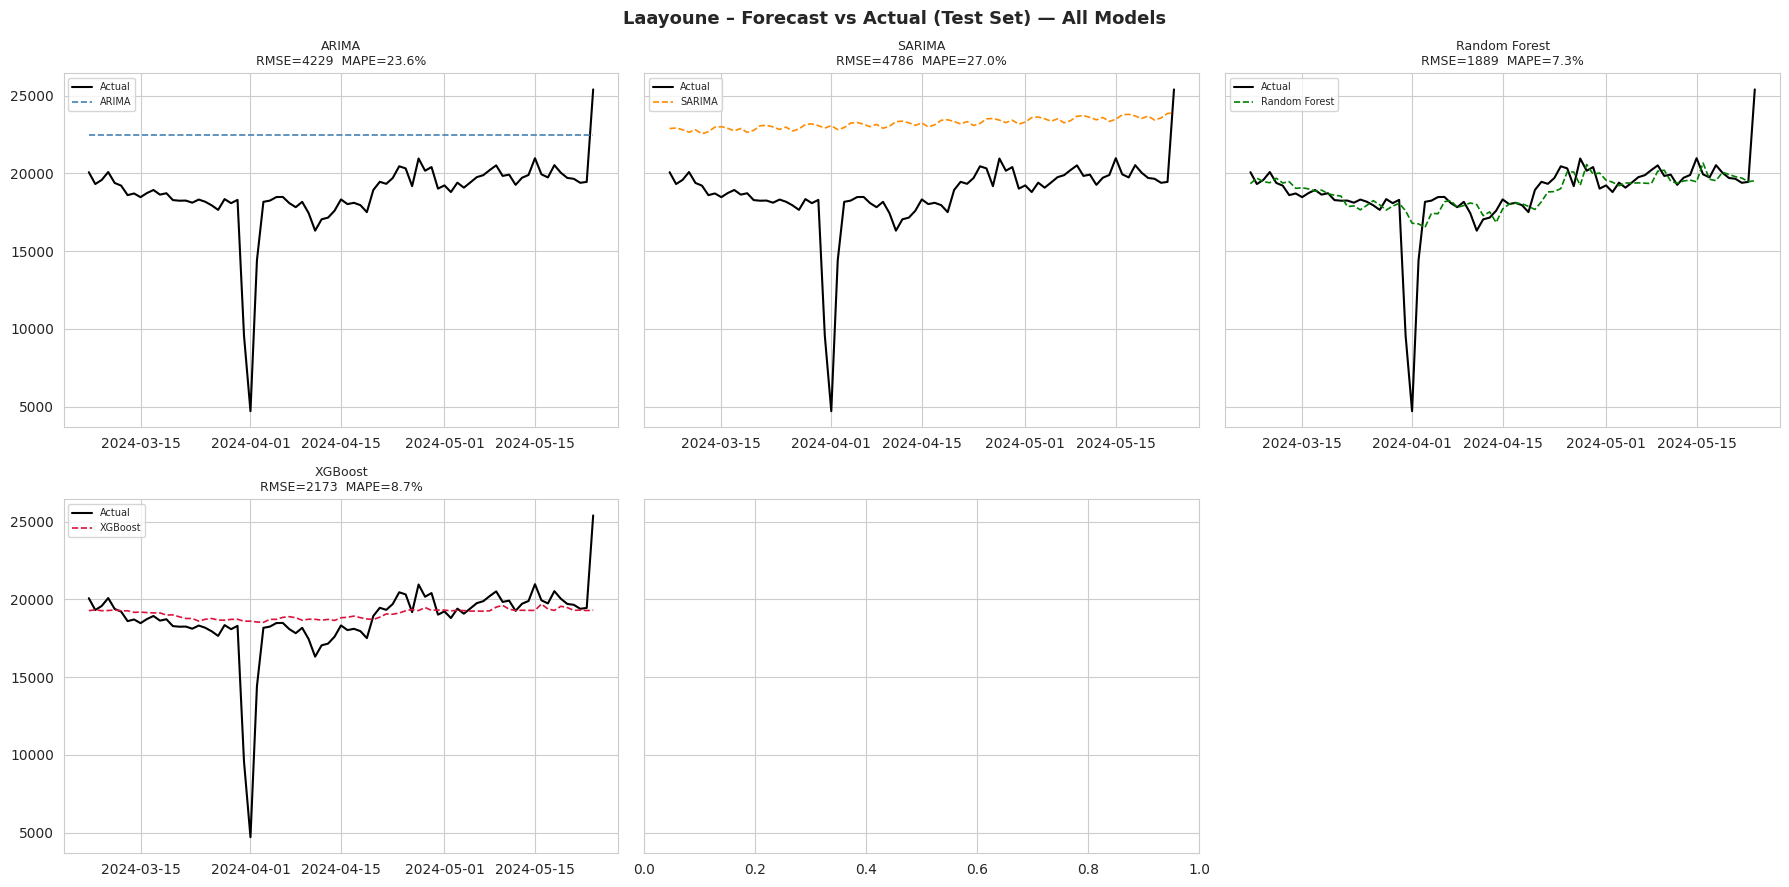

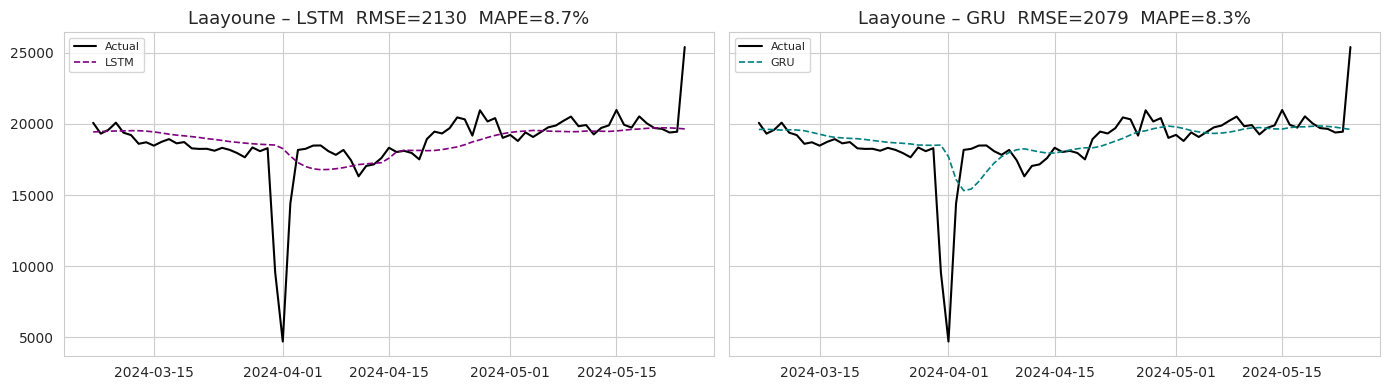

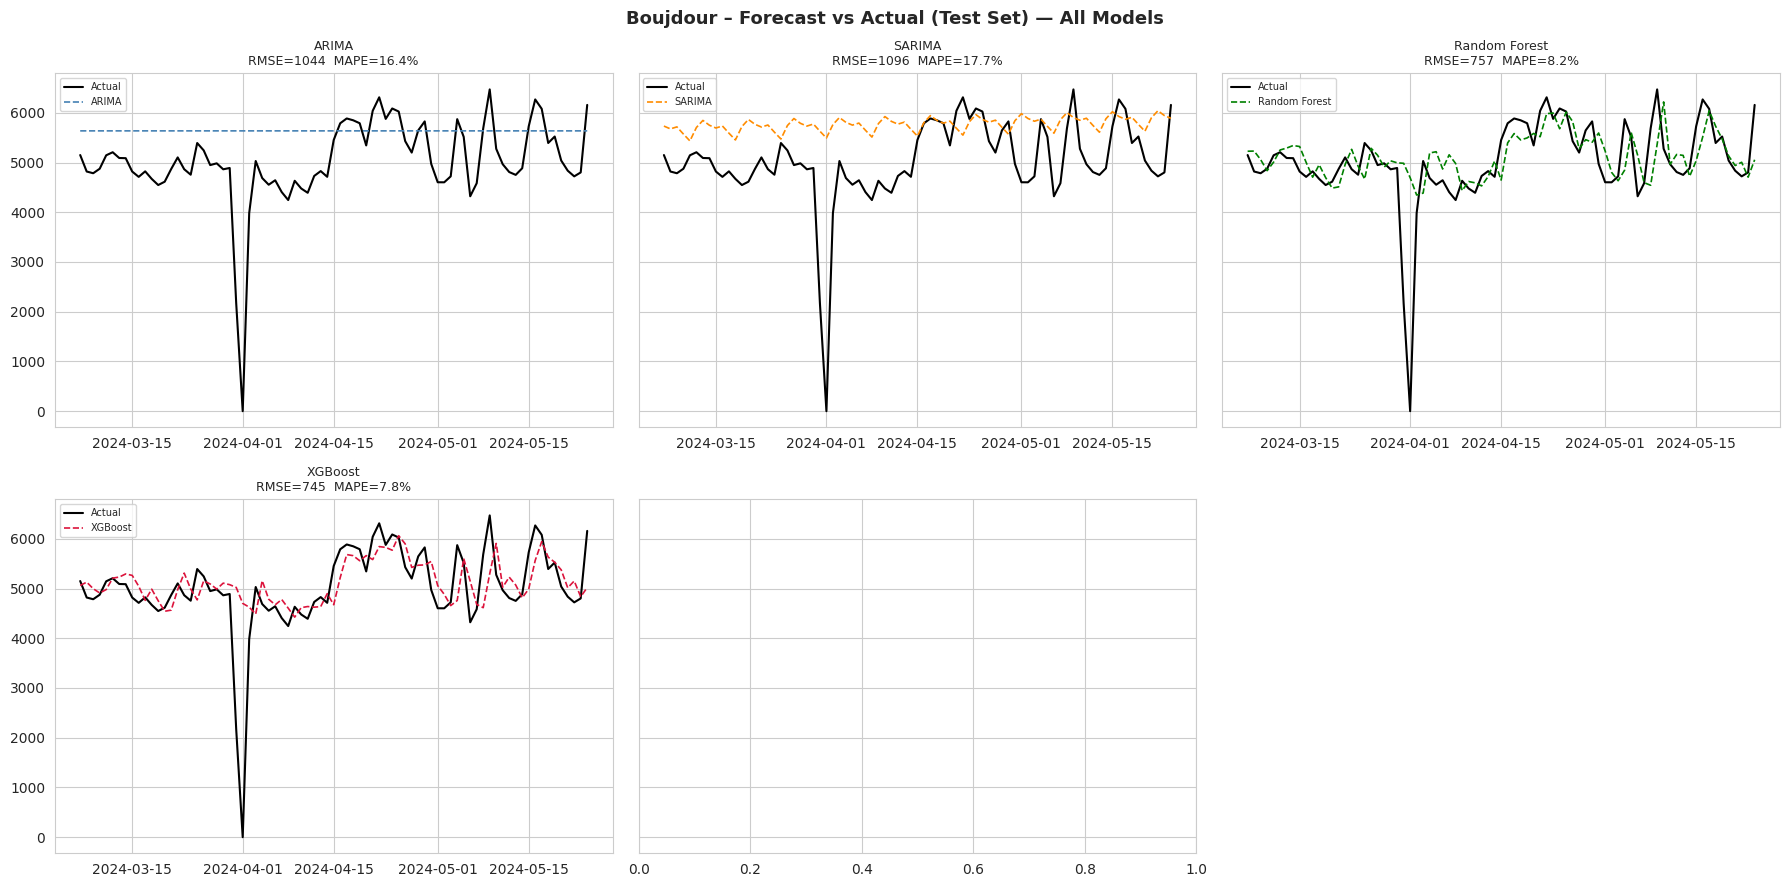

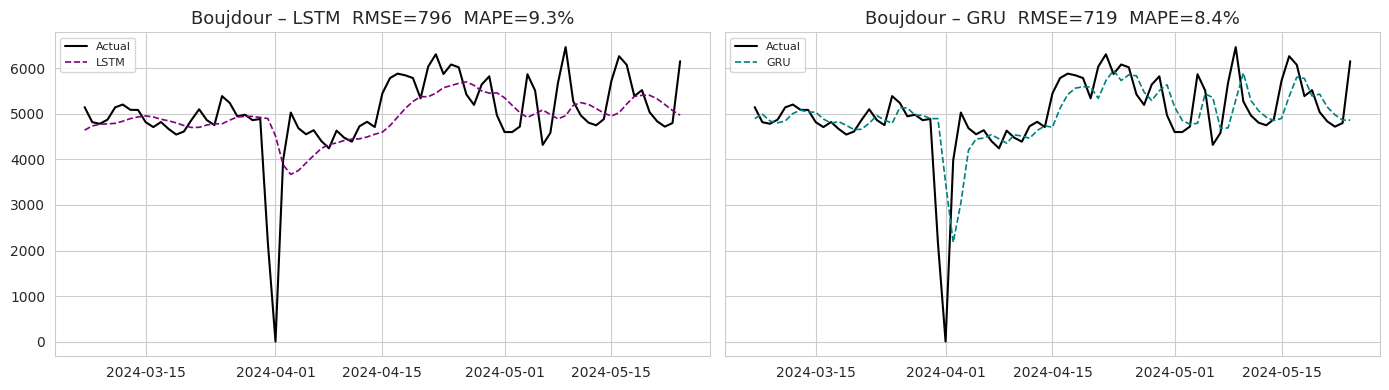

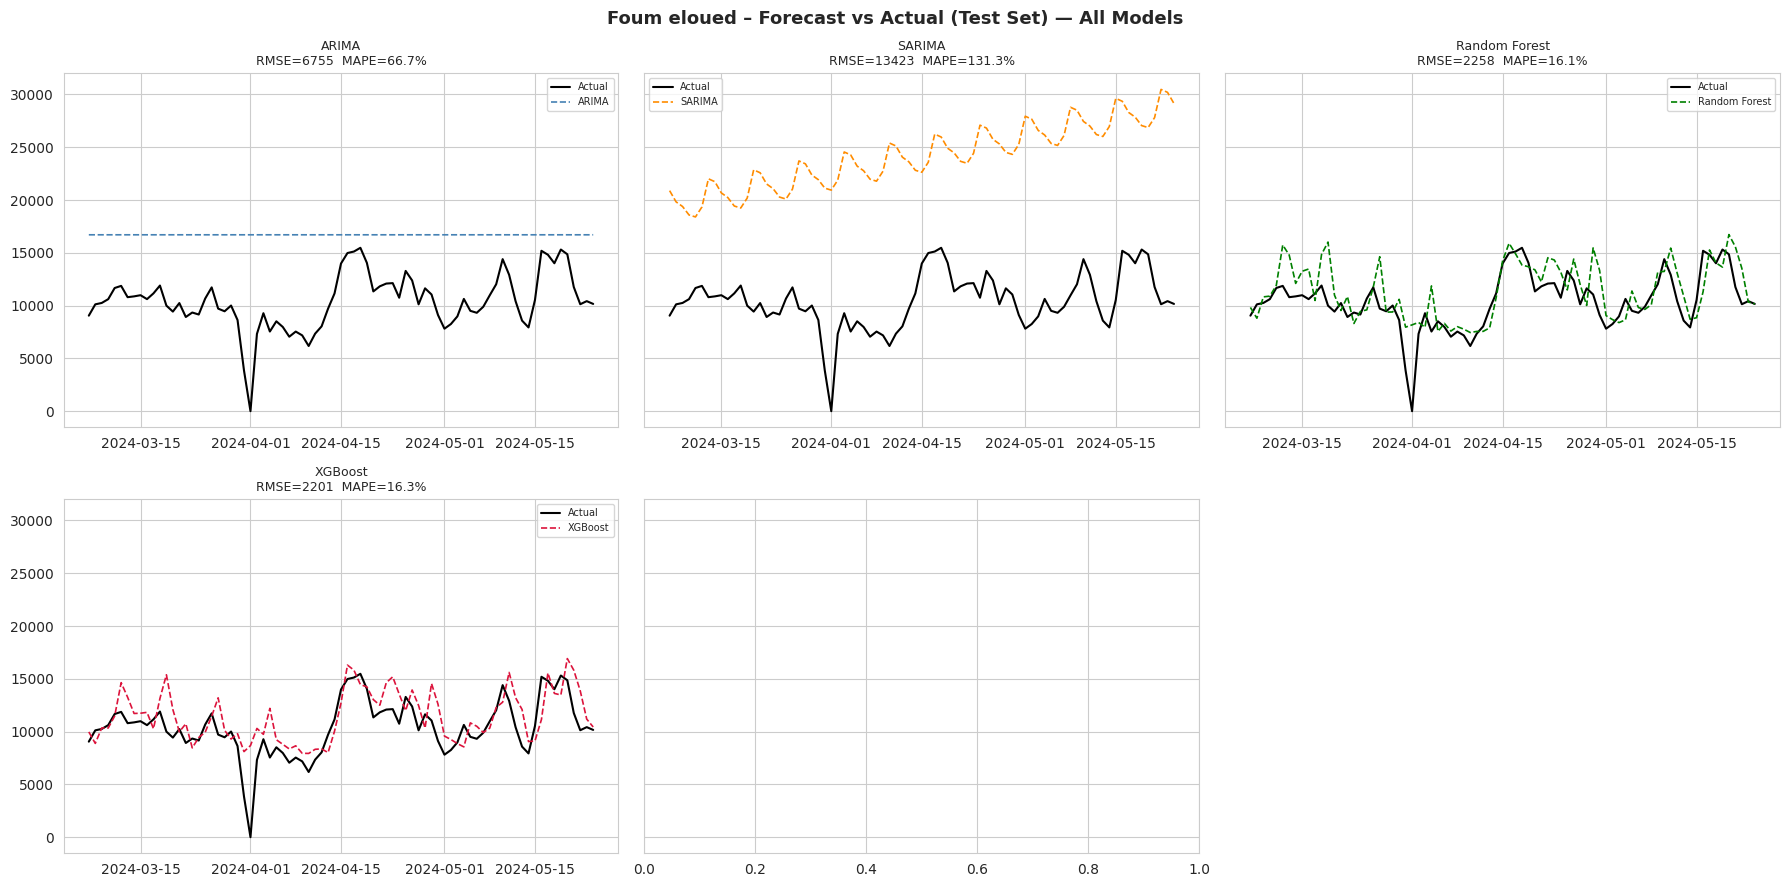

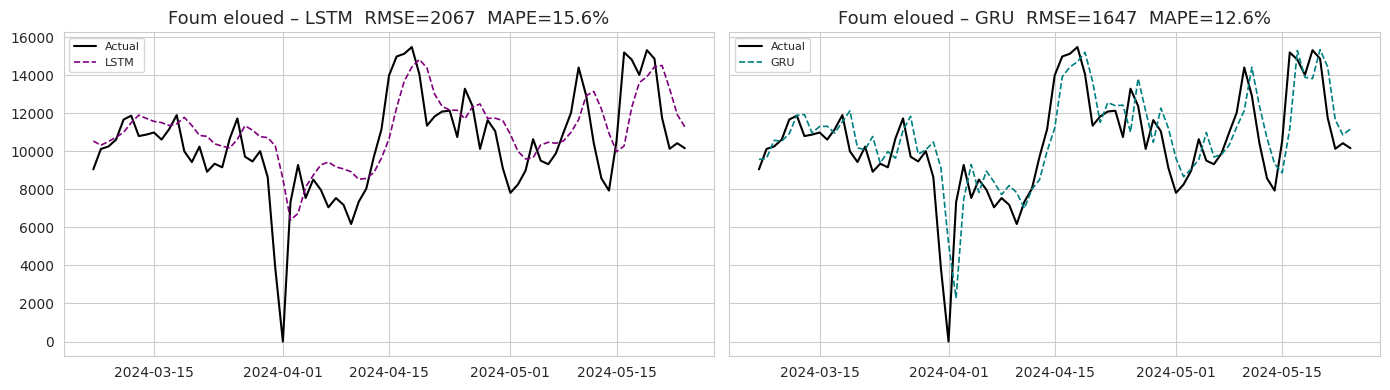

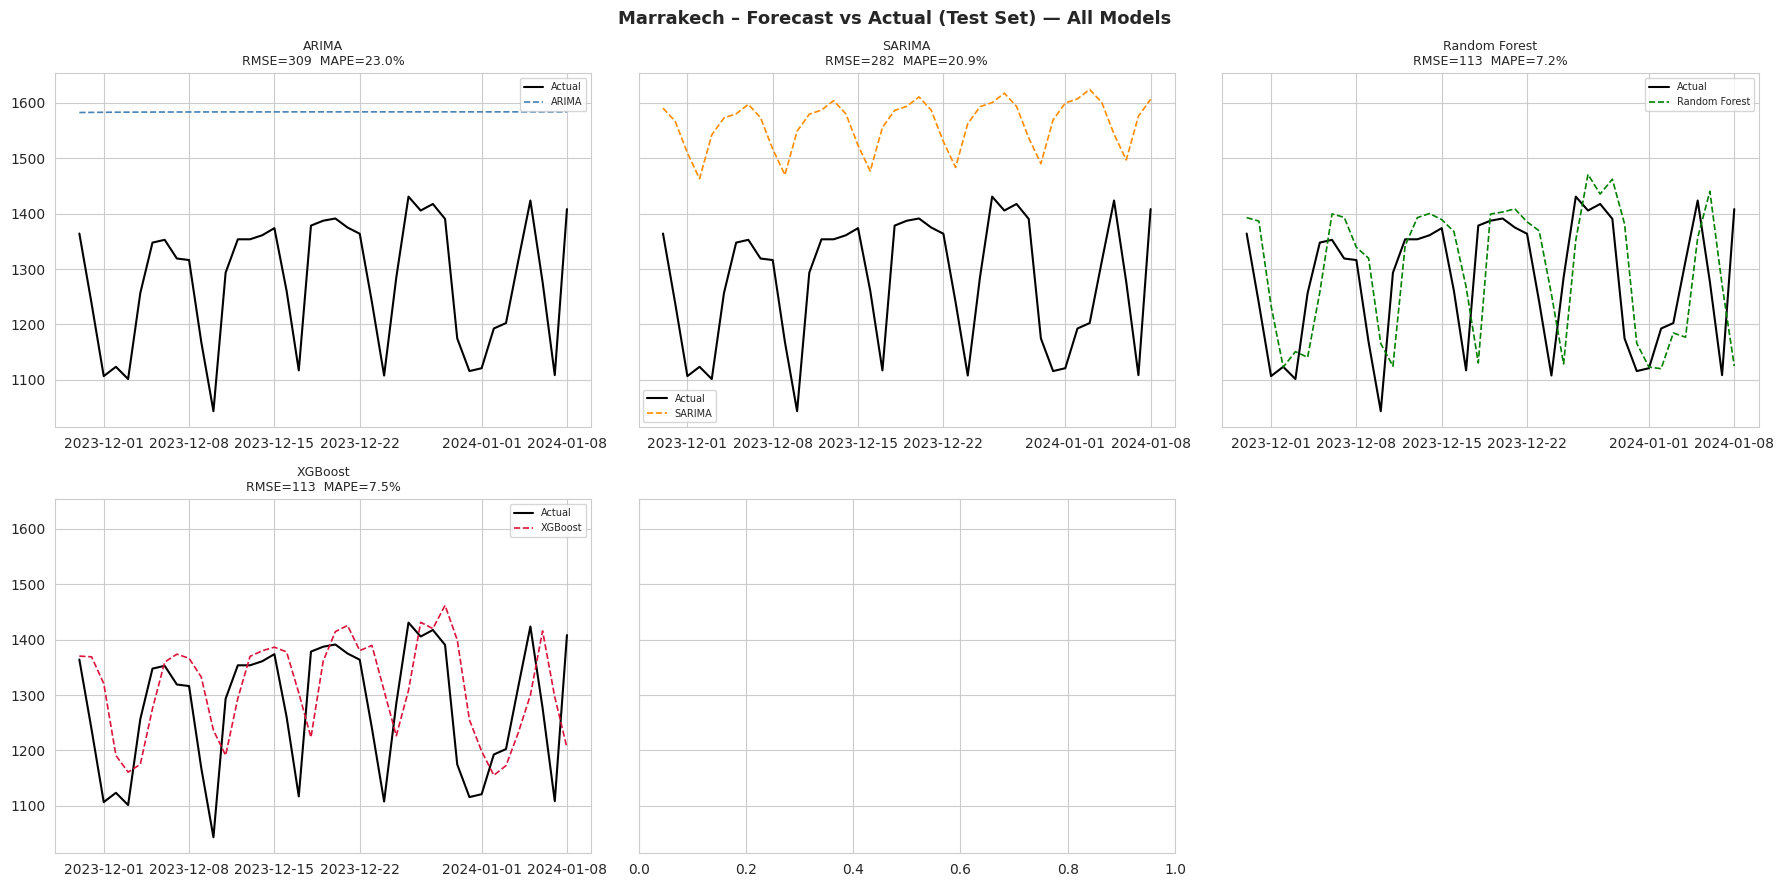

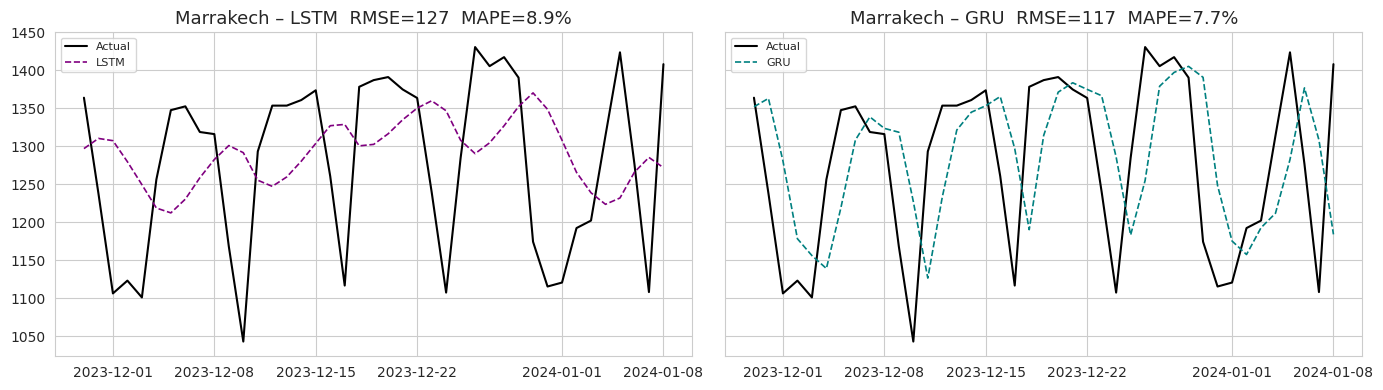

In [ ]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Loop through each city and plot model forecasts vs actuals
# ------------------------------------------------------------
for city in city_data:
    # Extract test set dates and actual load values
    test_dates = city_splits[city]["test"].index[-len(results_rf[city]["true_kw"]):]
    true_kw    = results_rf[city]["true_kw"]

    # ------------------------------------------------------------
    # Create 2x3 panel for ARIMA, SARIMA, RF, XGBoost, Hybrid, (blank)
    # ------------------------------------------------------------
    fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
    configs = [
        ("ARIMA",         results_arima[city]["forecast"][-len(true_kw):],  "steelblue"),
        ("SARIMA",        results_sarima[city]["forecast"][-len(true_kw):], "darkorange"),
        ("Random Forest", results_rf[city]["pred_kw"],                      "green"),
        ("XGBoost",       results_xgb[city]["pred_kw"],                     "crimson"),
    ]

    # Plot each model’s forecast vs actual
    for ax, (name, pred, colour) in zip(axes.flat, configs):
        ax.plot(test_dates, true_kw, label="Actual", color="black", lw=1.5)
        ax.plot(test_dates, pred,    label=name,     color=colour,  lw=1.2, ls="--")

        # Select correct metrics dictionary for title
        for rd in [results_arima, results_sarima, results_rf, results_xgb]:
            if rd is (results_arima if name=="ARIMA"
                      else results_sarima if name=="SARIMA"
                      else results_rf if name=="Random Forest"
                      else results_xgb):
                r = rd[city]; break
        else:
            r = results_arima[city]

        # Add RMSE and MAPE in subplot title
        ax.set_title(
            f"{name}\nRMSE={results_arima[city]['RMSE'] if name=='ARIMA' else results_sarima[city]['RMSE'] if name=='SARIMA' else results_rf[city]['RMSE'] if name=='Random Forest' else results_xgb[city]['RMSE']:.0f}  "
            f"MAPE={results_arima[city]['MAPE'] if name=='ARIMA' else results_sarima[city]['MAPE'] if name=='SARIMA' else results_rf[city]['MAPE'] if name=='Random Forest' else results_xgb[city]['MAPE']:.1f}%",
            fontsize=9
        )
        ax.legend(fontsize=7)

    # Hide empty 6th panel
    axes.flat[-1].set_visible(False)

    # Add overall title for the city
    fig.suptitle(f"{city} – Forecast vs Actual (Test Set) — All Models",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot LSTM & GRU side by side for deep learning comparison
    # ------------------------------------------------------------
    deep_dates = city_splits[city]["test"].index[LAGS:]
    fig2, (ax_l, ax_g) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    for ax, name, res, colour in [
        (ax_l, "LSTM", results_lstm[city], "purple"),
        (ax_g, "GRU",  results_gru[city],  "teal"),
    ]:
        ax.plot(deep_dates, res["true_kw"], label="Actual", color="black", lw=1.5)
        ax.plot(deep_dates, res["pred_kw"], label=name,     color=colour,  lw=1.2, ls="--")
        ax.set_title(f"{city} – {name}  RMSE={res['RMSE']:.0f}  MAPE={res['MAPE']:.1f}%")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

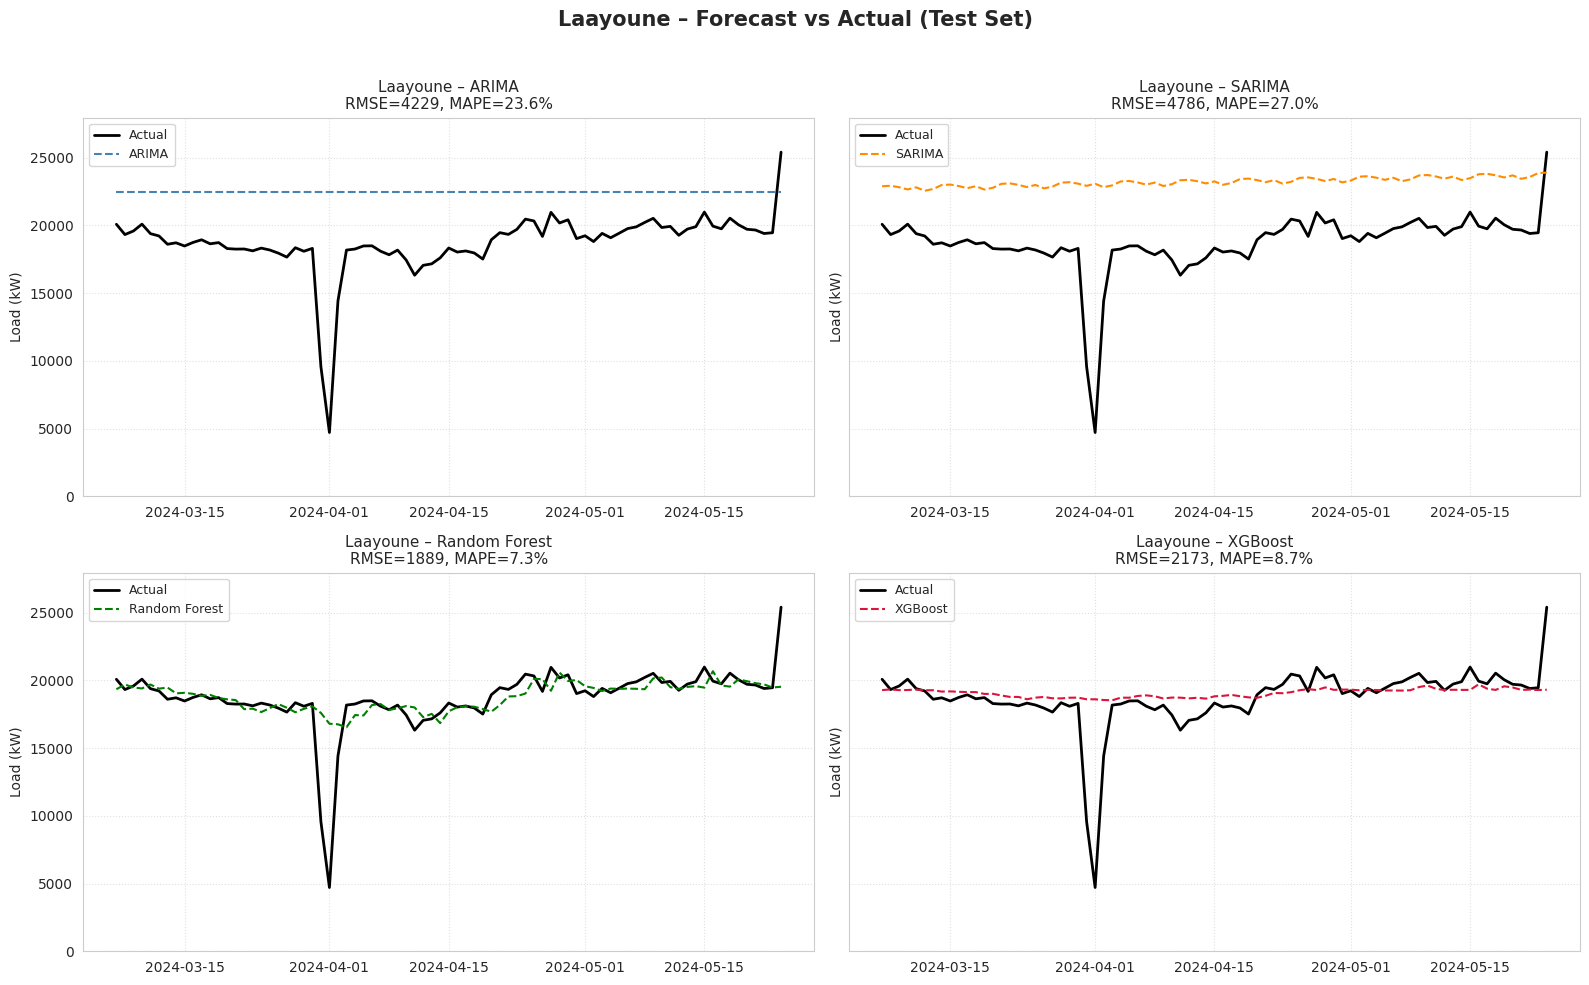

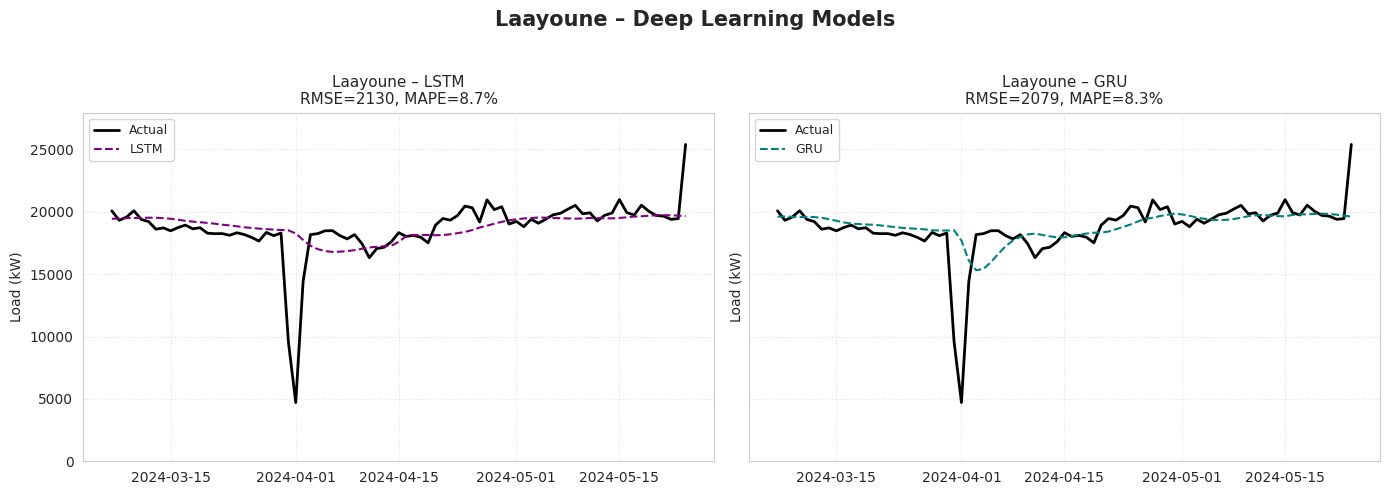

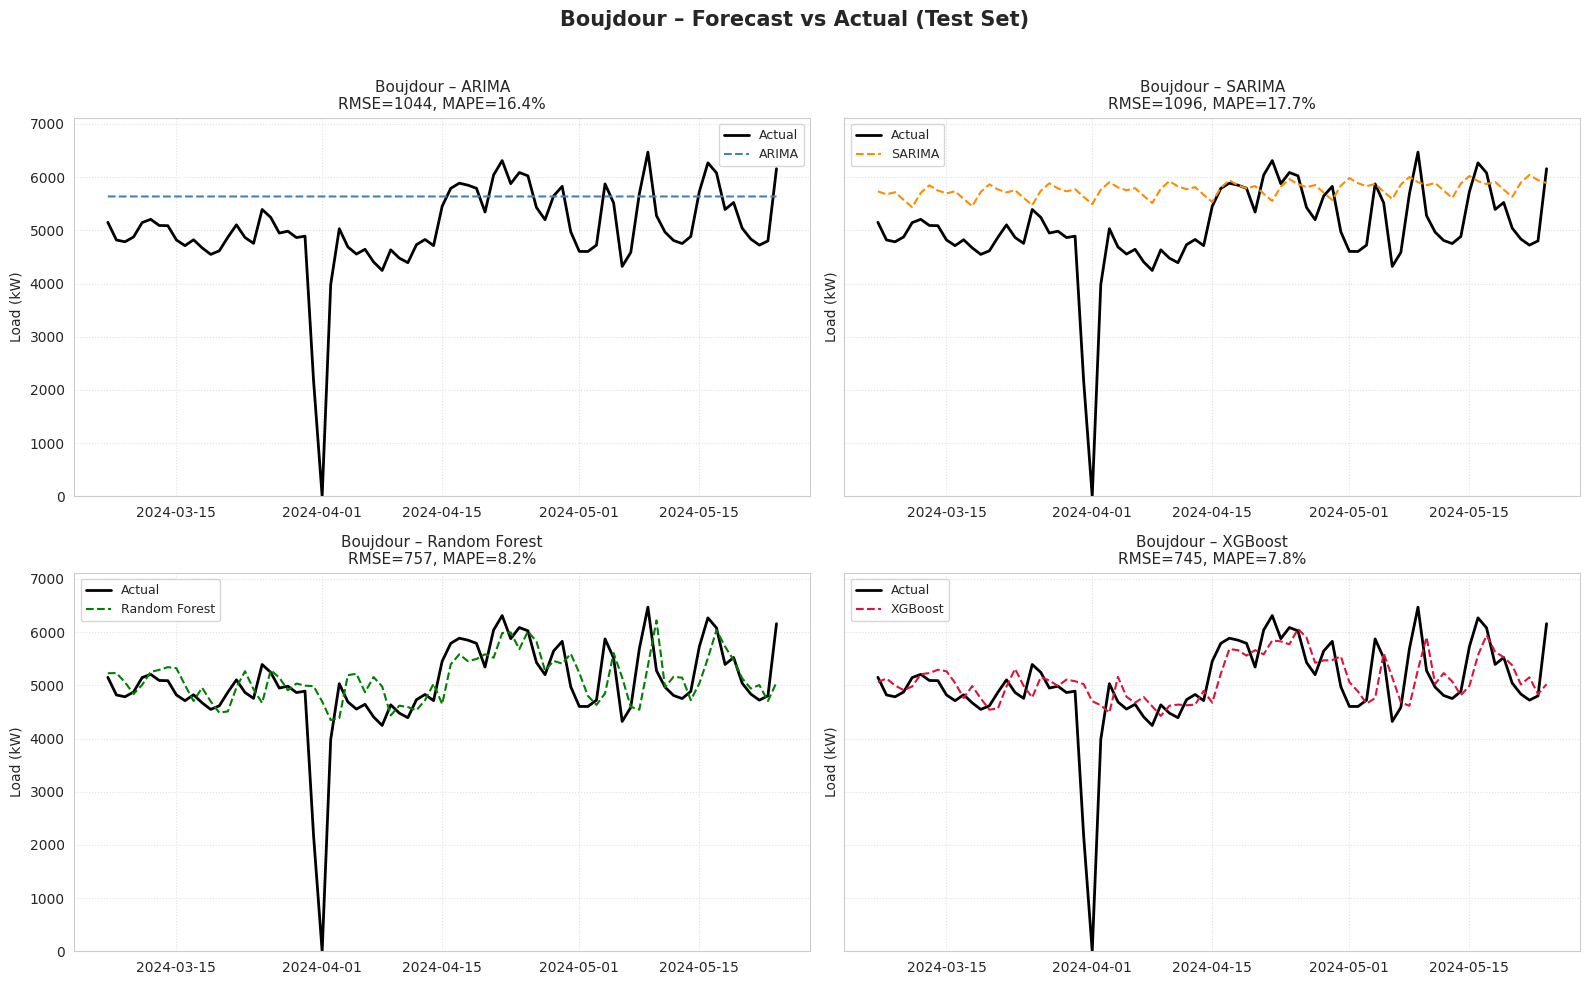

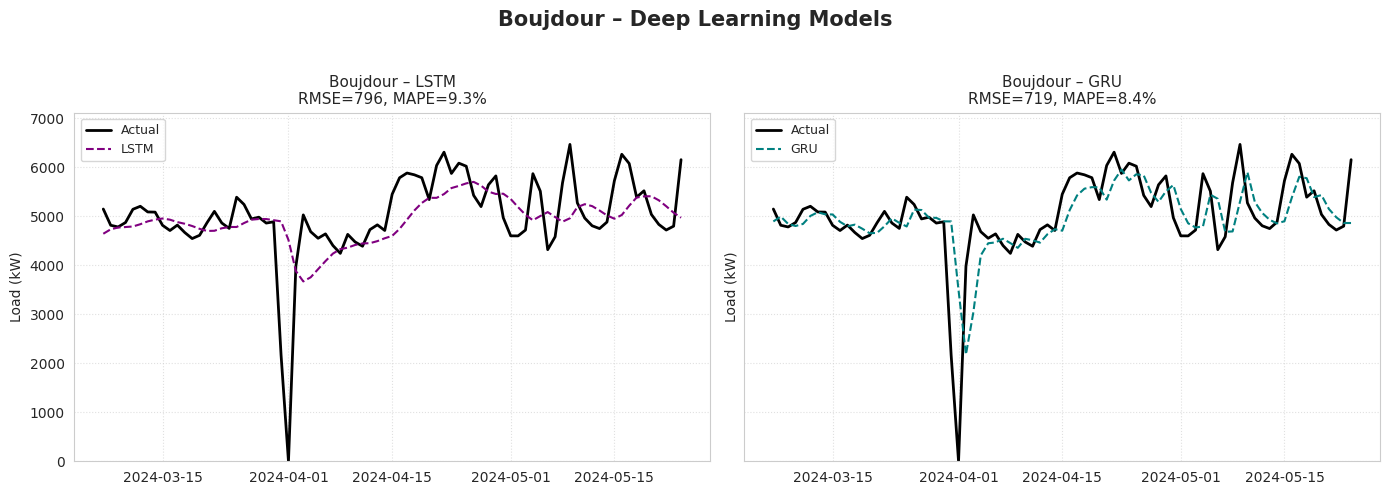

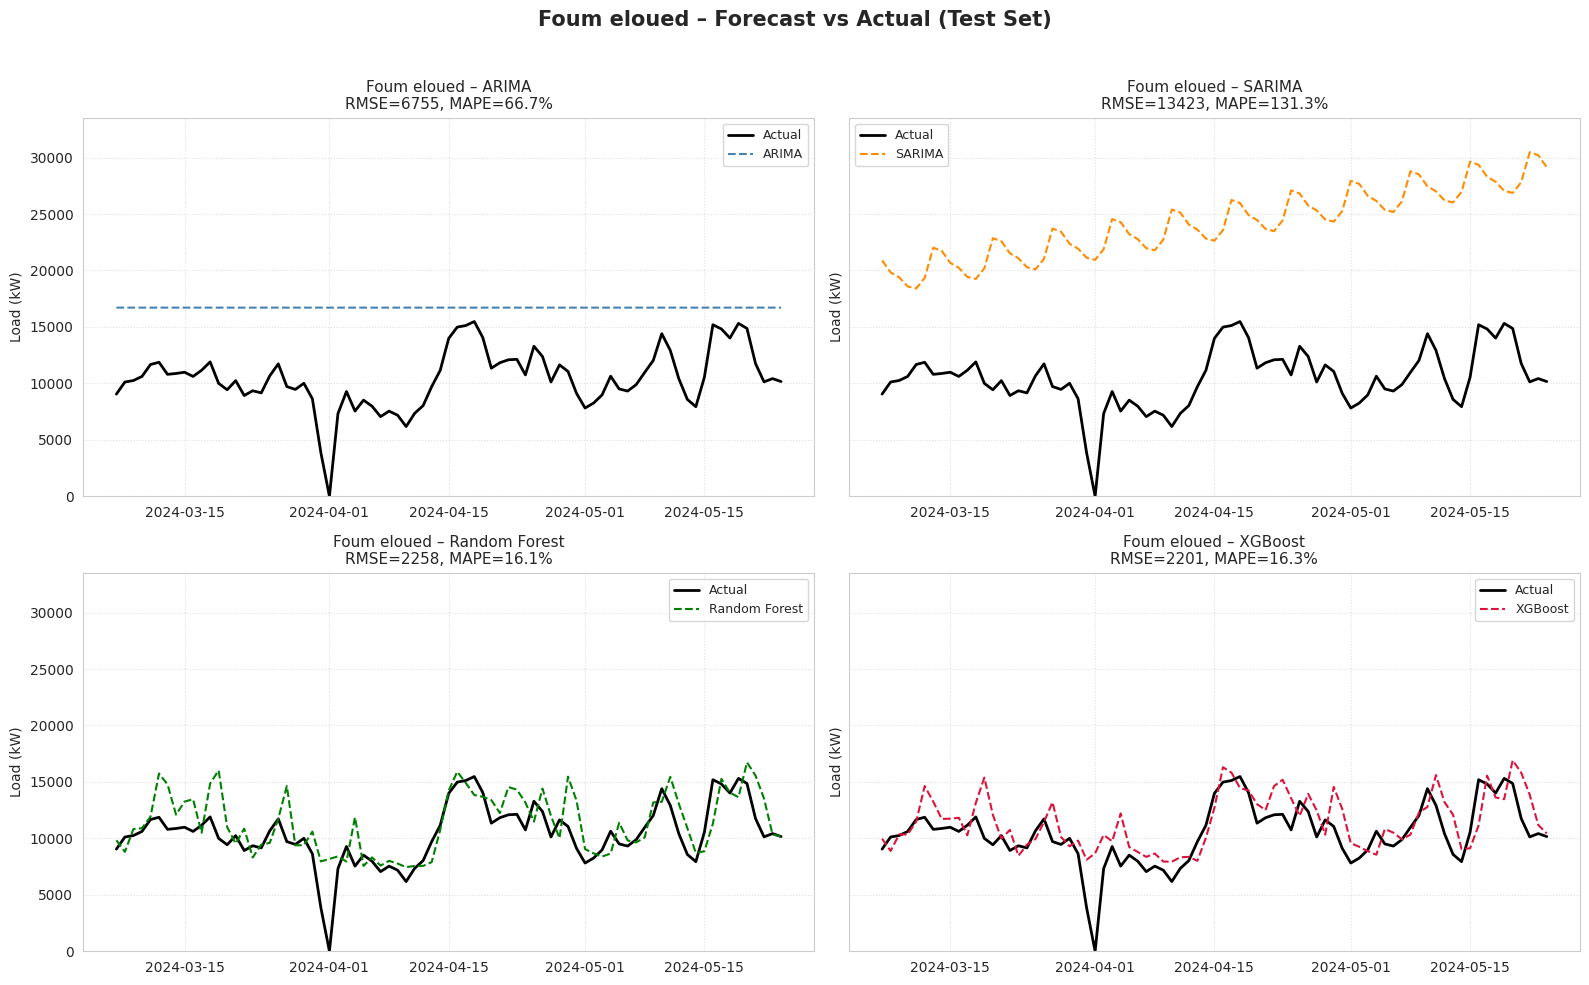

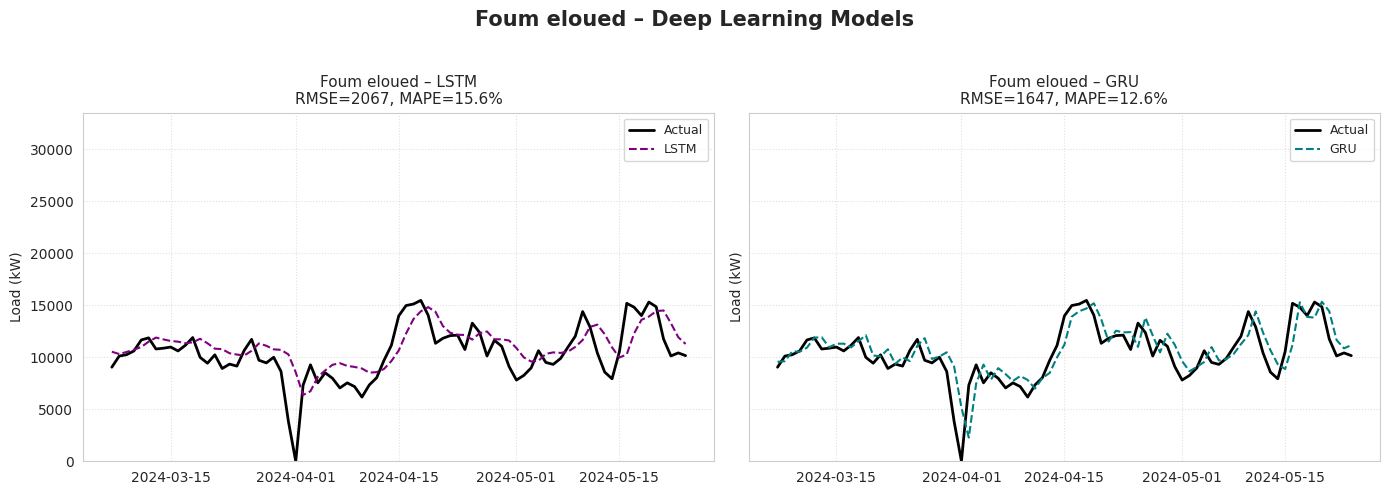

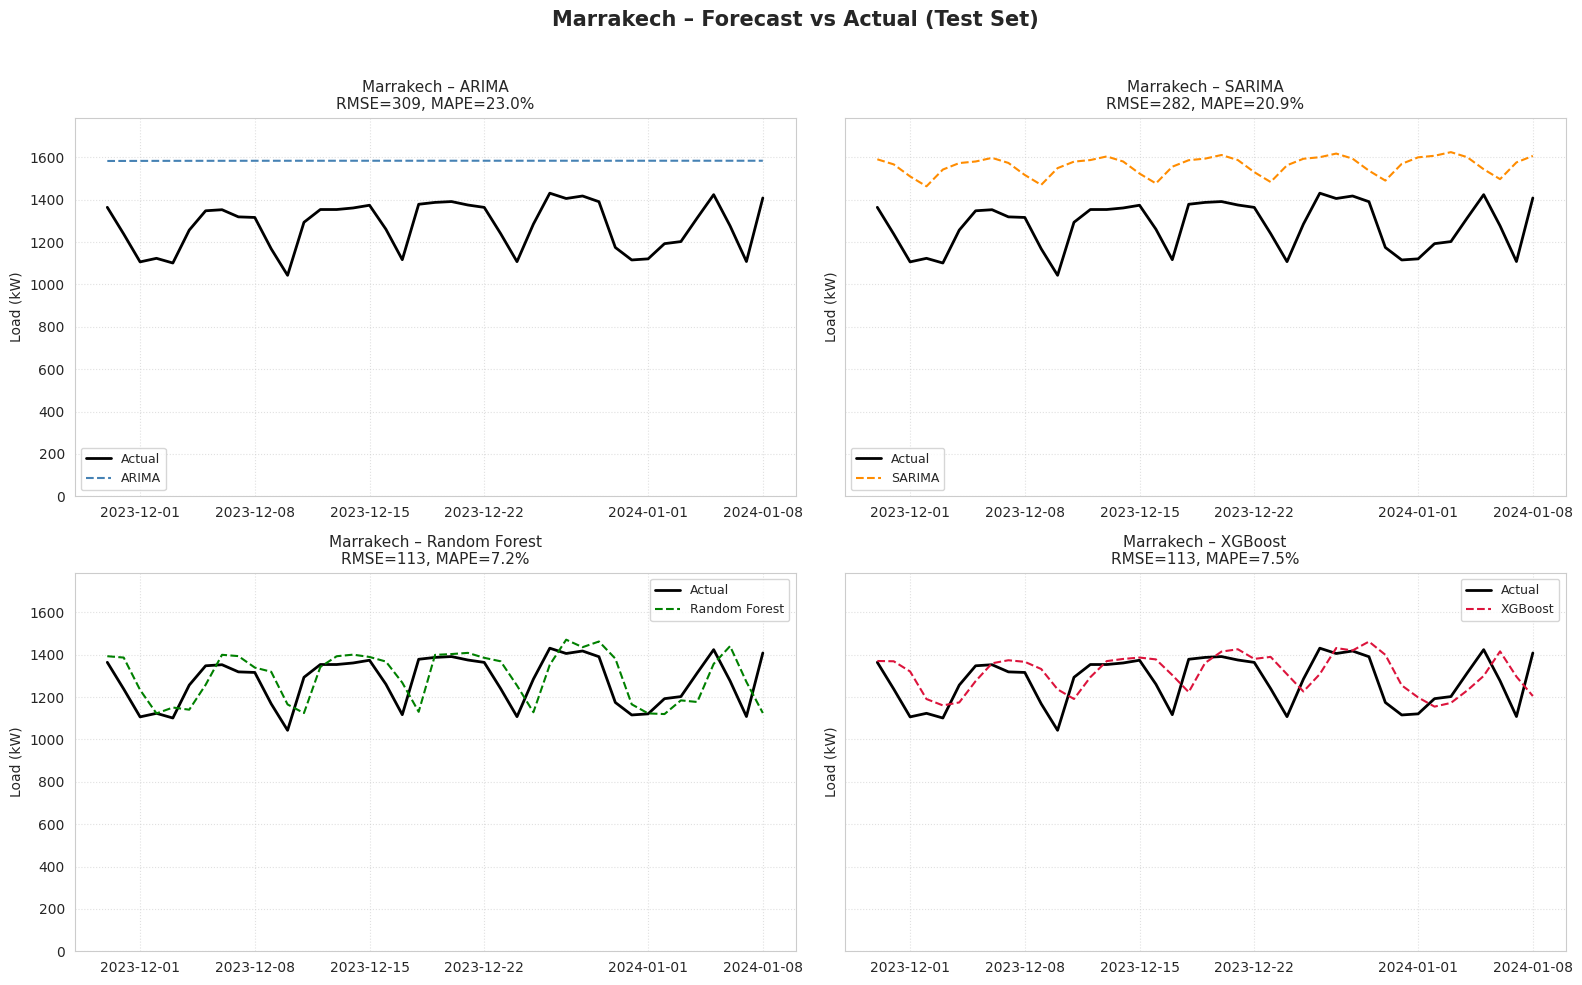

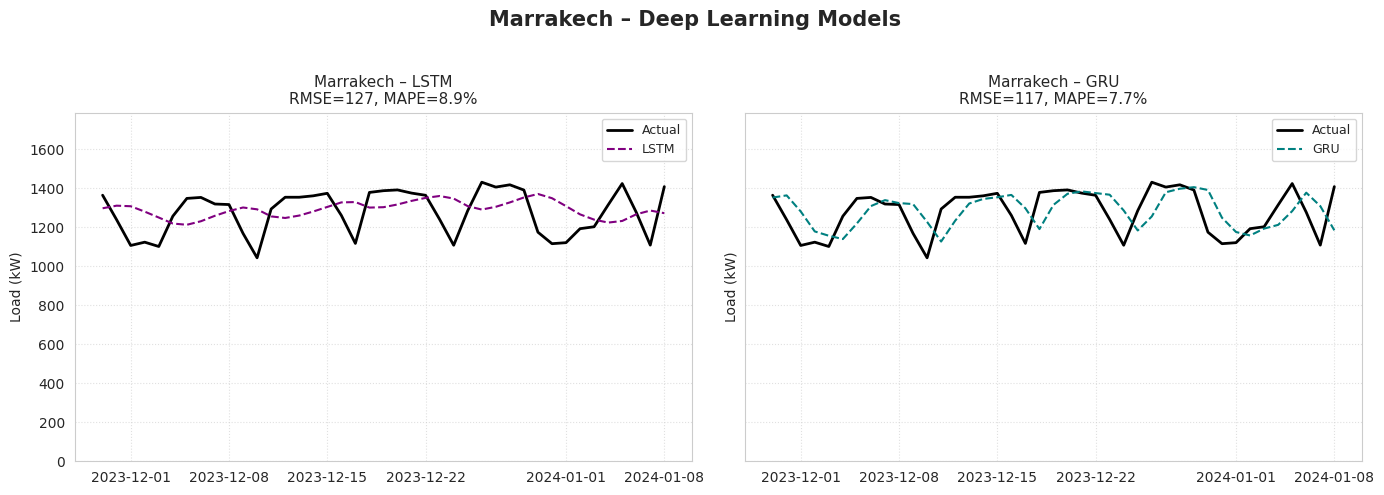

In [ ]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Loop through each city and plot model forecasts vs actuals
# ------------------------------------------------------------
for city in city_data:
    # Extract test set dates and actual load values
    test_dates = city_splits[city]["test"].index[-len(results_rf[city]["true_kw"]):]
    true_kw    = results_rf[city]["true_kw"]

    # ------------------------------------------------------------
    # Create 2x2 panel for ARIMA, SARIMA, RF, XGBoost
    # ------------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
    configs = [
        ("ARIMA",         results_arima[city]["forecast"][-len(true_kw):],  "steelblue", results_arima[city]),
        ("SARIMA",        results_sarima[city]["forecast"][-len(true_kw):], "darkorange", results_sarima[city]),
        ("Random Forest", results_rf[city]["pred_kw"],                      "green",     results_rf[city]),
        ("XGBoost",       results_xgb[city]["pred_kw"],                     "crimson",   results_xgb[city]),
    ]

    # Determine global y‑axis max for consistency across subplots
    ymax = max(true_kw.max(), max(cfg[1].max() for cfg in configs)) * 1.1

    # ------------------------------------------------------------
    # Plot each classical/statistical model forecast vs actual
    # ------------------------------------------------------------
    for ax, (name, pred, colour, res) in zip(axes.flat, configs):
        ax.plot(test_dates, true_kw, label="Actual", color="black", lw=2)          # actual load
        ax.plot(test_dates, pred,    label=name,     color=colour,  lw=1.5, ls="--") # forecasted load
        ax.set_title(f"{city} – {name}\nRMSE={res['RMSE']:.0f}, MAPE={res['MAPE']:.1f}%", fontsize=11)
        ax.set_ylabel("Load (kW)")
        ax.set_ylim(0, ymax)                 # consistent y-axis limit
        ax.legend(fontsize=9)
        ax.grid(True, linestyle=":", alpha=0.6)  # add grid for readability

    # Add overall title for the city
    fig.suptitle(f"{city} – Forecast vs Actual (Test Set)", fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # ------------------------------------------------------------
    # Plot LSTM & GRU side by side for deep learning comparison
    # ------------------------------------------------------------
    deep_dates = city_splits[city]["test"].index[LAGS:]
    fig2, (ax_l, ax_g) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, name, res, colour in [
        (ax_l, "LSTM", results_lstm[city], "purple"),
        (ax_g, "GRU",  results_gru[city],  "teal"),
    ]:
        ax.plot(deep_dates, res["true_kw"], label="Actual", color="black", lw=2)   # actual load
        ax.plot(deep_dates, res["pred_kw"], label=name,     color=colour,  lw=1.5, ls="--") # forecasted load
        ax.set_title(f"{city} – {name}\nRMSE={res['RMSE']:.0f}, MAPE={res['MAPE']:.1f}%", fontsize=11)
        ax.set_ylabel("Load (kW)")
        ax.set_ylim(0, ymax)                 # consistent y-axis limit
        ax.legend(fontsize=9)
        ax.grid(True, linestyle=":", alpha=0.6)

    # Add overall title for deep learning comparison
    fig2.suptitle(f"{city} – Deep Learning Models", fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

**Actual vs Forecasting Load by City regarding Best Models**

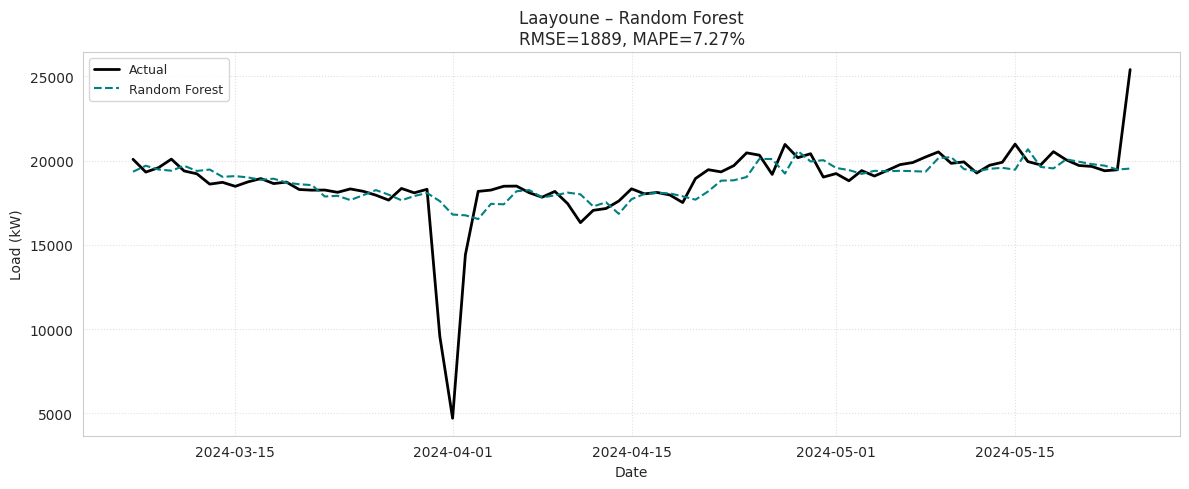

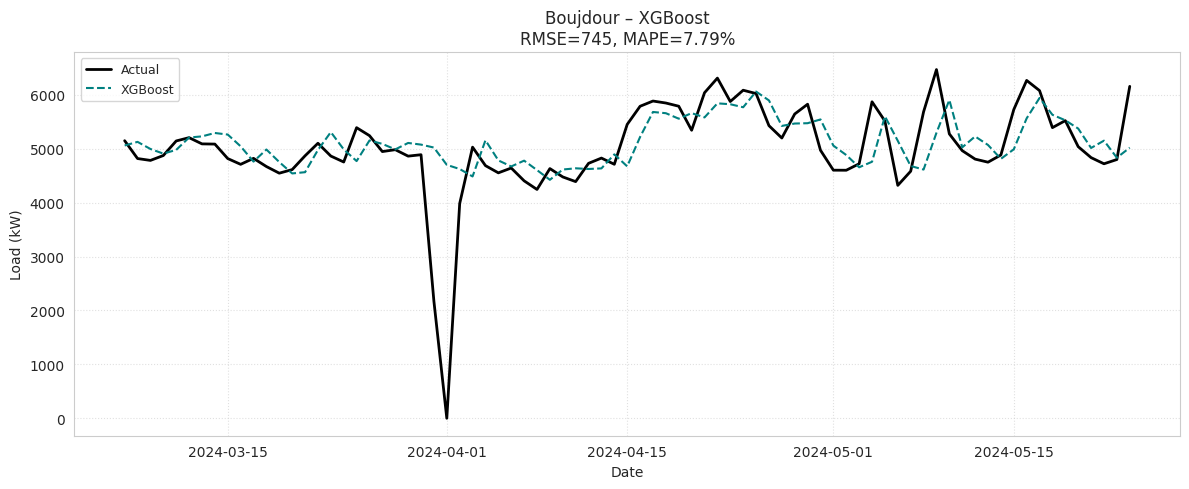

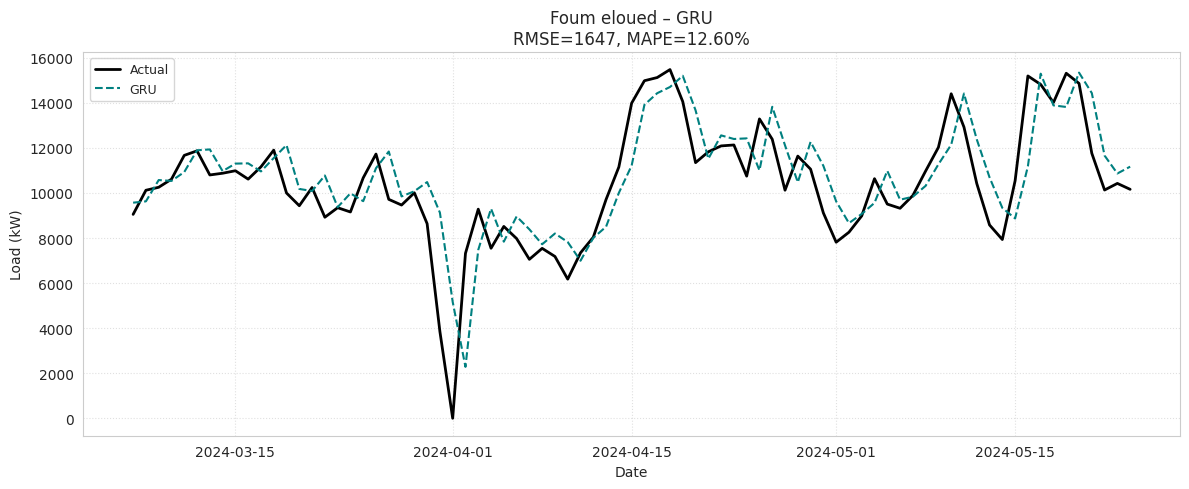

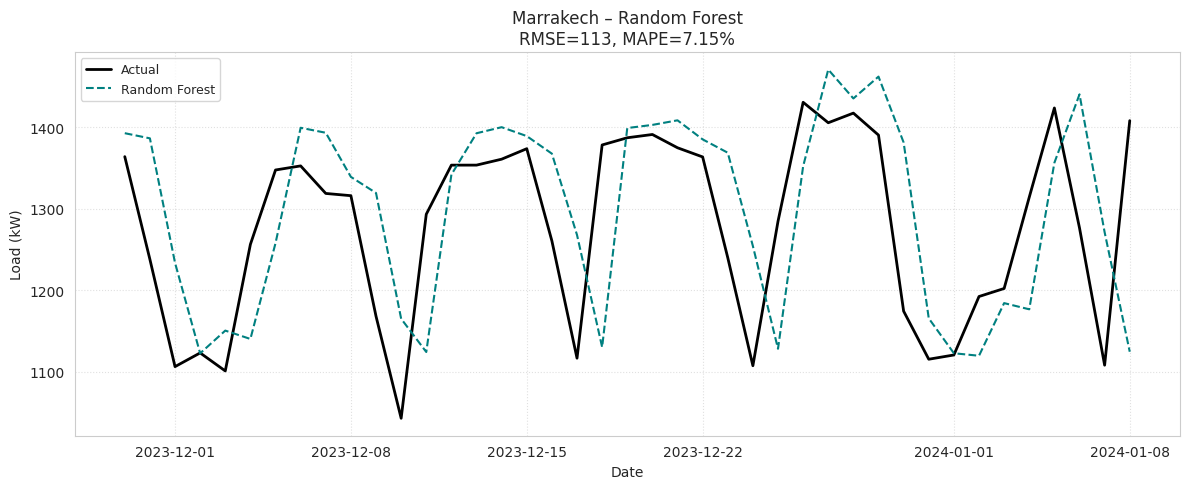

In [ ]:
import matplotlib.pyplot as plt

# Dictionary of best models per city based on lowest MAPE and competitive RMSE
best_models = {
    "Laayoune": ("Random Forest", results_rf),
    "Boujdour": ("XGBoost", results_xgb),
    "Foum eloued": ("GRU", results_gru),
    "Marrakech": ("Random Forest", results_rf),
}

# Loop through each city and plot only the best model
for city, (model_name, res_dict) in best_models.items():

    # For tree-based models (RF, XGBoost) use full test set length
    if model_name in ["Random Forest", "XGBoost"]:
        test_dates = city_splits[city]["test"].index[-len(res_dict[city]["true_kw"]):]
        true_kw = res_dict[city]["true_kw"]   # actual load values
        pred_kw = res_dict[city]["pred_kw"]   # forecasted load values

    # For GRU (and LSTM if used), account for lagged input window
    else:
        test_dates = city_splits[city]["test"].index[LAGS:]
        true_kw = res_dict[city]["true_kw"]
        pred_kw = res_dict[city]["pred_kw"]

    # Create figure with larger size for readability
    plt.figure(figsize=(12, 5))

    # Plot actual load in black solid line
    plt.plot(test_dates, true_kw, label="Actual", color="black", lw=2)

    # Plot forecasted load in dashed line with model-specific color
    plt.plot(test_dates, pred_kw, label=model_name, color="teal", lw=1.5, ls="--")

    # Add informative title including RMSE and MAPE
    plt.title(f"{city} – {model_name}\nRMSE={res_dict[city]['RMSE']:.0f}, MAPE={res_dict[city]['MAPE']:.2f}%", fontsize=12)

    # Label axes
    plt.ylabel("Load (kW)")
    plt.xlabel("Date")

    # Add legend for clarity
    plt.legend(fontsize=9)

    # Add grid lines for easier interpretation
    plt.grid(True, linestyle=":", alpha=0.6)

    # Adjust layout to avoid overlap
    plt.tight_layout()

    # Display the plot
    plt.show()


> **Forecast vs Actual:** A 2×3 panel covers the five non-sequential models (ARIMA, SARIMA, Random Forest, XGBoost, Hybrid ARIMA-XGBoost) with a blank sixth panel; a separate side-by-side figure compares LSTM and GRU directly on the same test window.

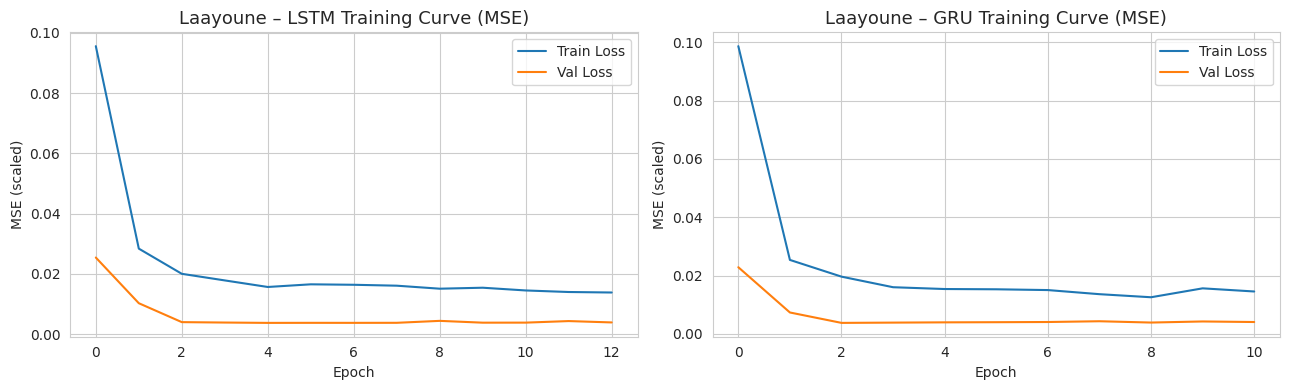

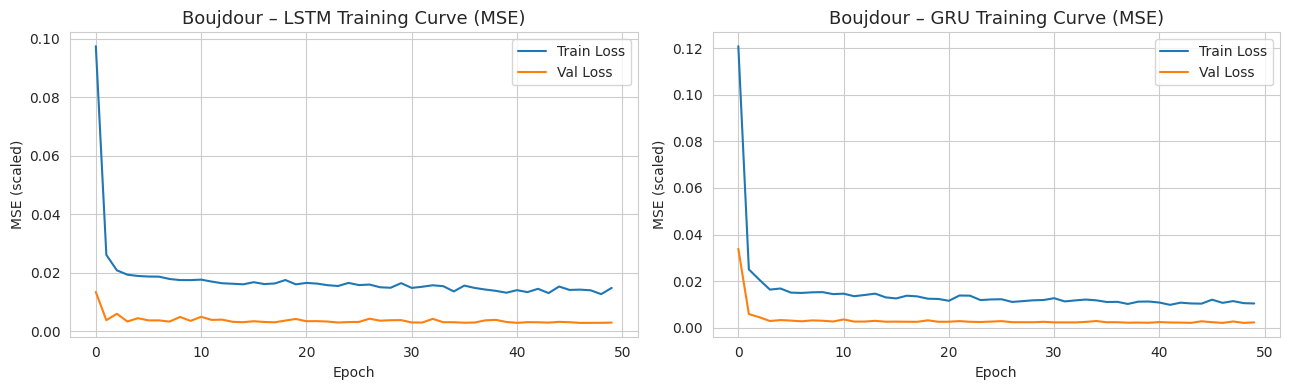

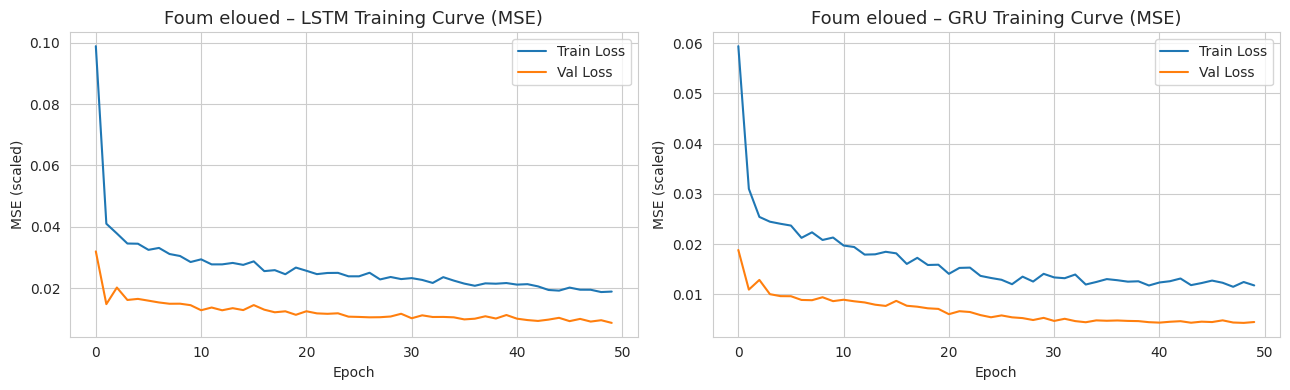

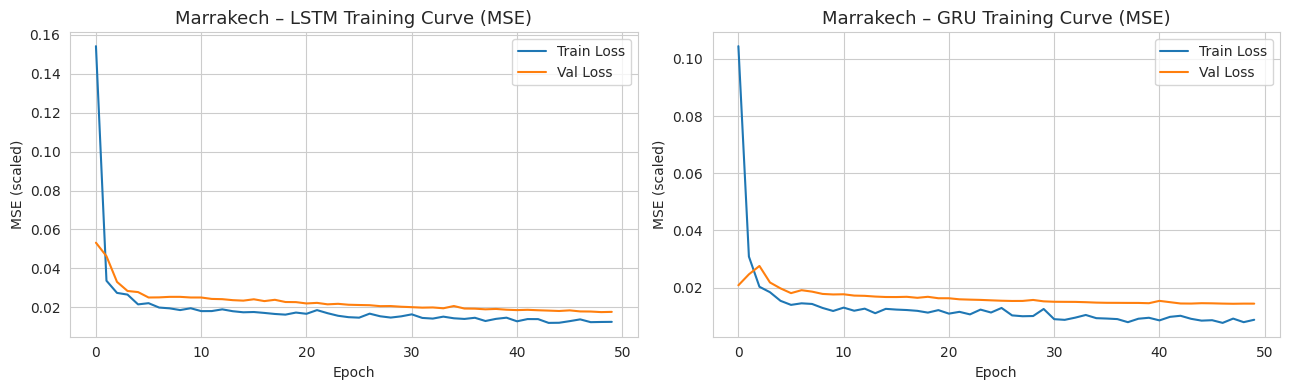

In [ ]:
# ------------------------------------------------------------
# Training / validation loss curves for LSTM and GRU side-by-side
# ------------------------------------------------------------
for city in city_data:
    # Create a figure with 1 row, 2 columns (LSTM vs GRU)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    # ------------------------------------------------------------
    # Loop over both models (LSTM, GRU) for the current city
    # ------------------------------------------------------------
    for ax, name, res in [
        (ax1, "LSTM", results_lstm[city]),
        (ax2, "GRU",  results_gru[city])
    ]:
        h = res["history"]  # training history object from Keras

        # Plot training loss curve
        ax.plot(h.history["loss"],     label="Train Loss")

        # Plot validation loss curve
        ax.plot(h.history["val_loss"], label="Val Loss")

        # Add title and axis labels
        ax.set_title(f"{city} – {name} Training Curve (MSE)")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE (scaled)")

        # Add legend for clarity
        ax.legend()

    # Adjust layout to avoid overlap
    plt.tight_layout()

    # Show the figure
    plt.show()

> **Training curves:** Plots LSTM and GRU training/validation MSE loss curves side-by-side for each city so convergence speed and early-stopping epoch can be compared directly between the two gated architectures.

Best model by RMSE per city:
       City         Model  RMSE (kW)
   Boujdour           GRU     719.29
Foum eloued           GRU    1646.85
   Laayoune Random Forest    1889.23
  Marrakech Random Forest     113.23

Best model by MAPE per city:
       City         Model  MAPE (%)
   Boujdour       XGBoost      7.79
Foum eloued           GRU     12.60
   Laayoune Random Forest      7.27
  Marrakech Random Forest      7.15


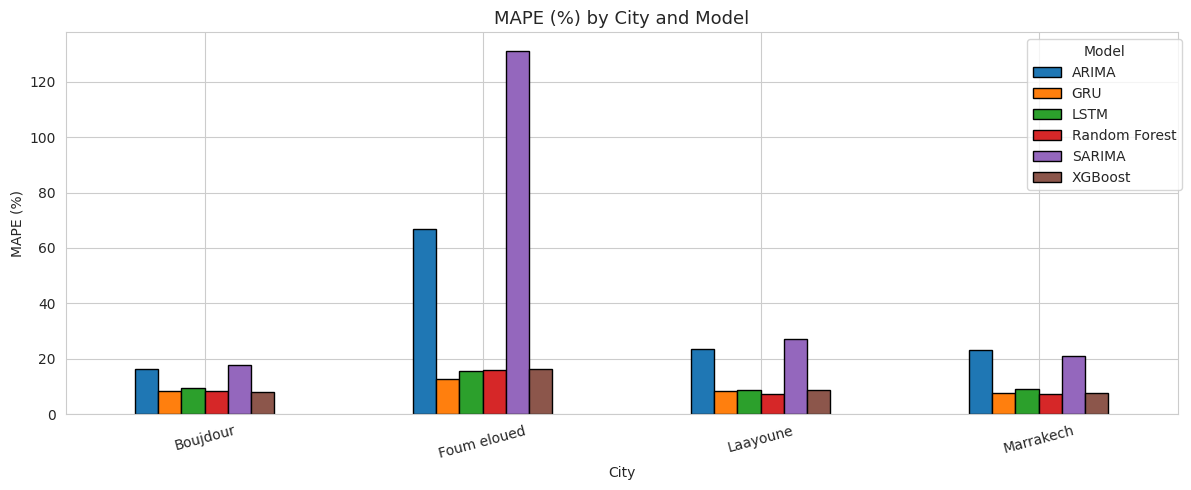

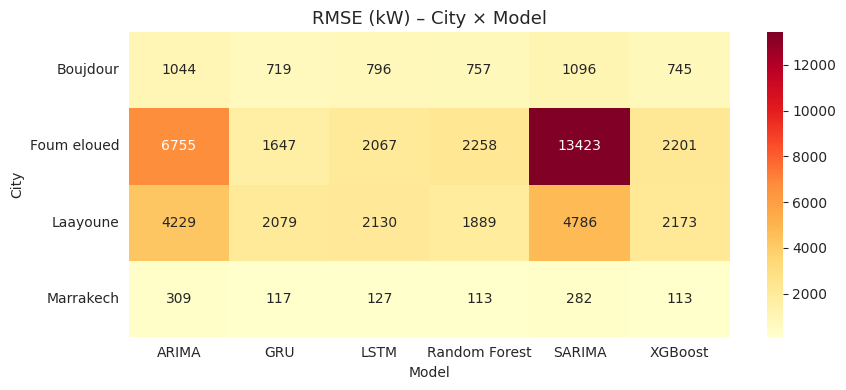

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Identify best models per city based on RMSE and MAPE
# ------------------------------------------------------------

# Find the row with minimum RMSE per city
best_rmse = summary_df.loc[
    summary_df.groupby("City")["RMSE (kW)"].idxmin()
][["City", "Model", "RMSE (kW)"]]

# Find the row with minimum MAPE per city
best_mape = summary_df.loc[
    summary_df.groupby("City")["MAPE (%)"].idxmin()
][["City", "Model", "MAPE (%)"]]

# Print results clearly
print("Best model by RMSE per city:")
print(best_rmse.to_string(index=False))
print("\nBest model by MAPE per city:")
print(best_mape.to_string(index=False))

# ------------------------------------------------------------
# Bar chart: MAPE per model per city
# ------------------------------------------------------------

# Pivot table: cities as rows, models as columns, values = MAPE
pivot = summary_df.pivot(index="City", columns="Model", values="MAPE (%)")

# Plot grouped bar chart
pivot.plot(kind="bar", figsize=(12, 5), edgecolor="black")
plt.title("MAPE (%) by City and Model")   # chart title
plt.ylabel("MAPE (%)")                    # y-axis label
plt.xticks(rotation=15)                   # rotate city labels for readability
plt.legend(title="Model", bbox_to_anchor=(1.01, 1))  # legend outside plot
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Heatmap: RMSE per city × model
# ------------------------------------------------------------

# Pivot table: cities as rows, models as columns, values = RMSE
pivot_rmse = summary_df.pivot(index="City", columns="Model", values="RMSE (kW)")

# Plot heatmap with annotations
plt.figure(figsize=(9, 4))
sns.heatmap(pivot_rmse, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("RMSE (kW) – City × Model")     # chart title
plt.tight_layout()
plt.show()

> Identifies the best model per city by RMSE and MAPE separately, prints a ranked summary table, then generates a grouped bar chart of MAPE and a heatmap of RMSE across all city–model combinations.





## **[9] SHAP interpretability (Random Forest & XGBoost)**


--- SHAP  |  Laayoune ---


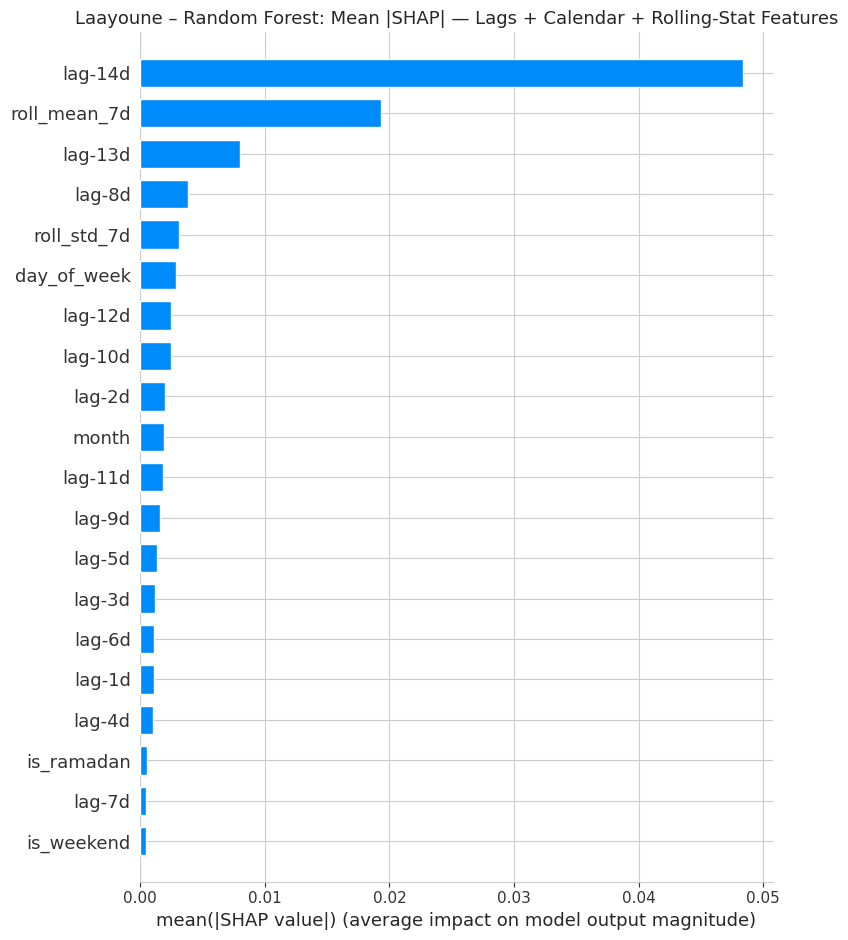

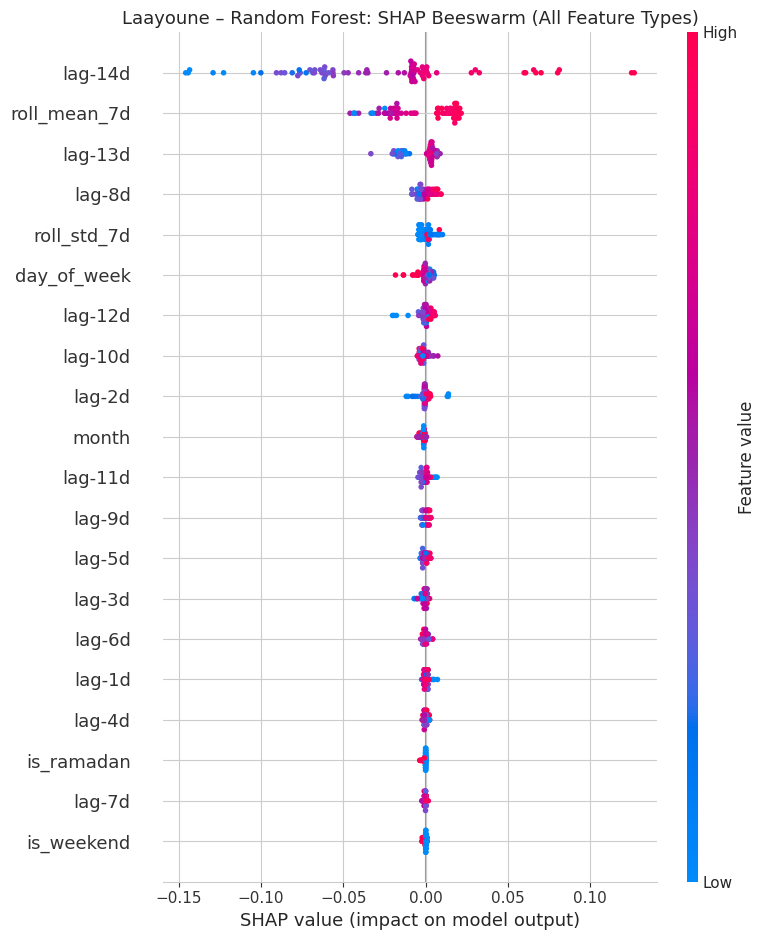

<Figure size 700x400 with 0 Axes>

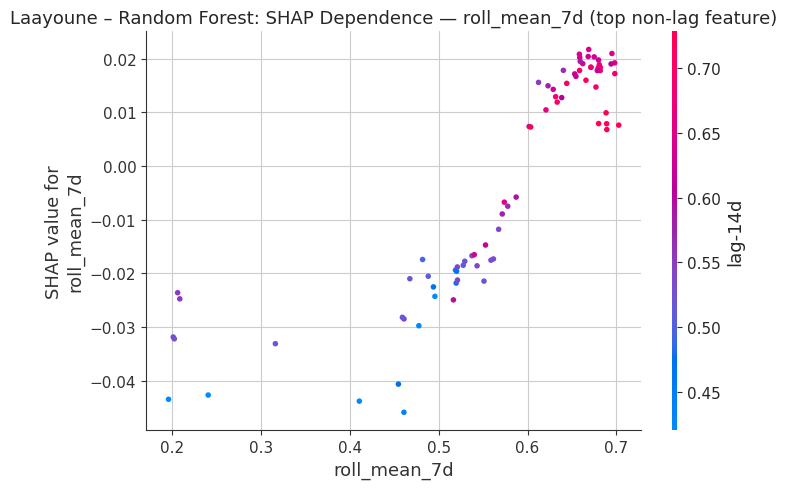

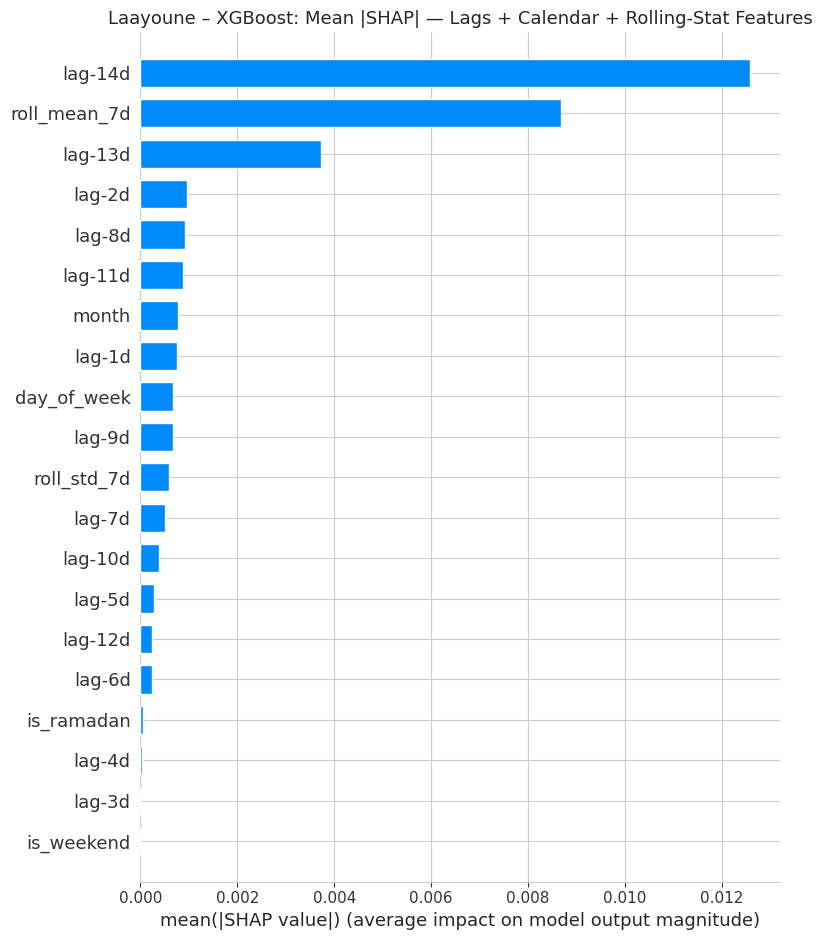

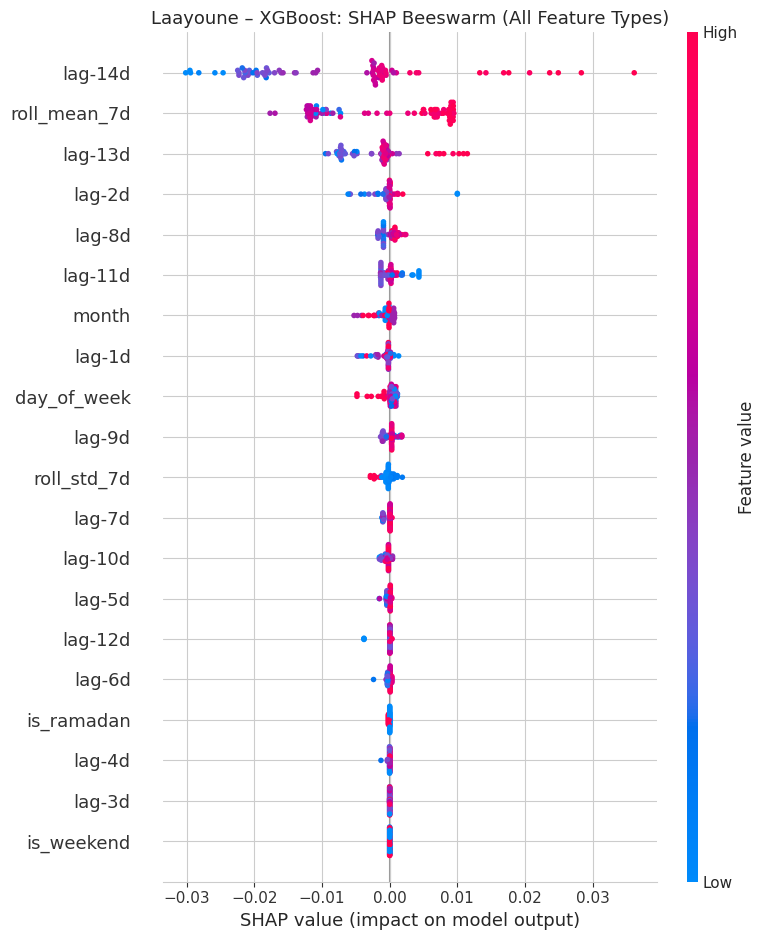

<Figure size 700x400 with 0 Axes>

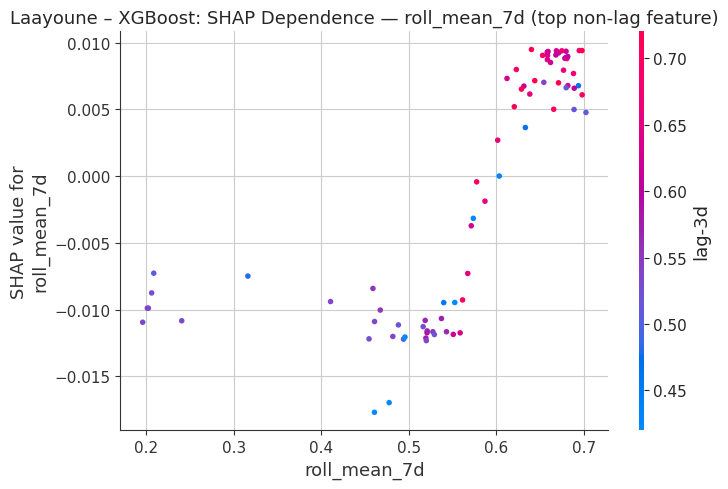


--- SHAP  |  Boujdour ---


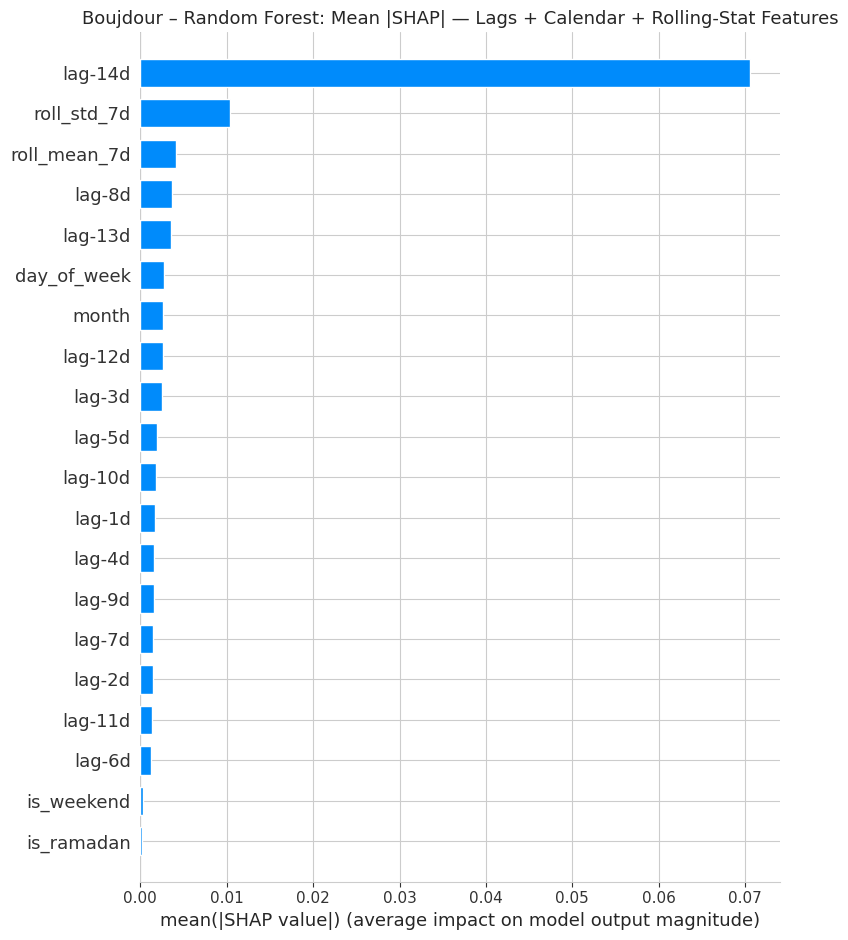

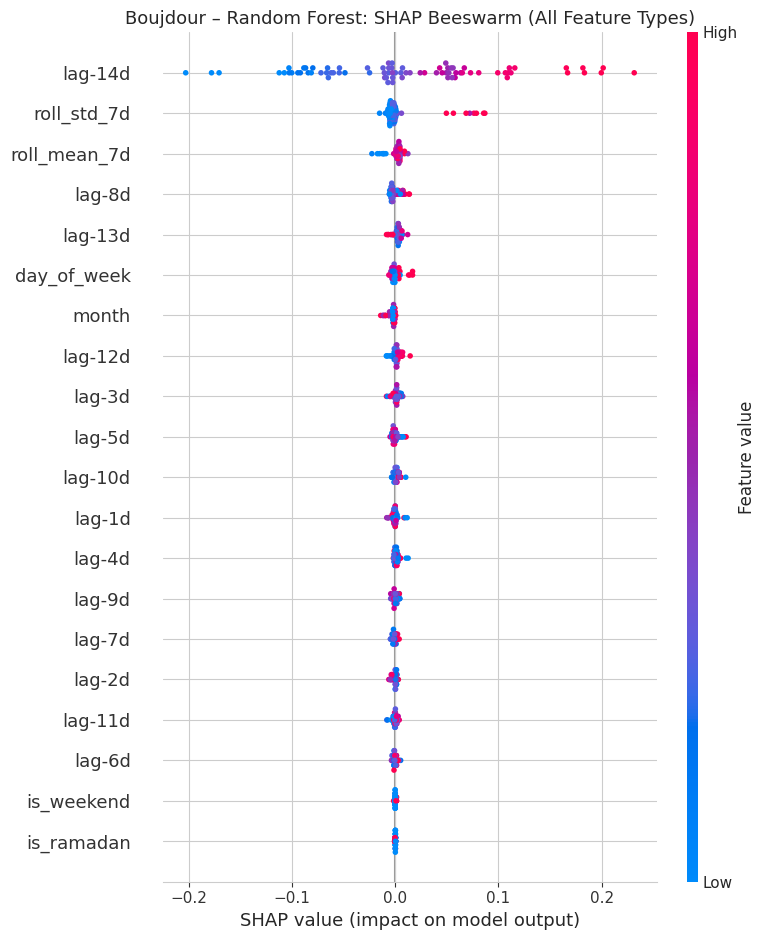

<Figure size 700x400 with 0 Axes>

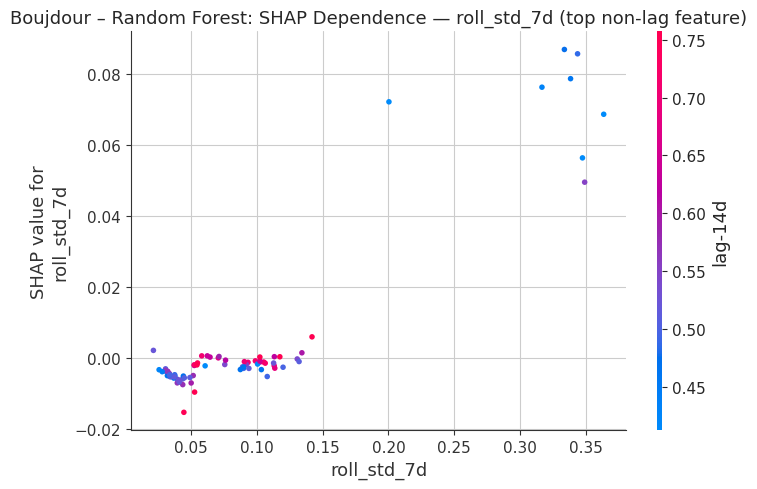

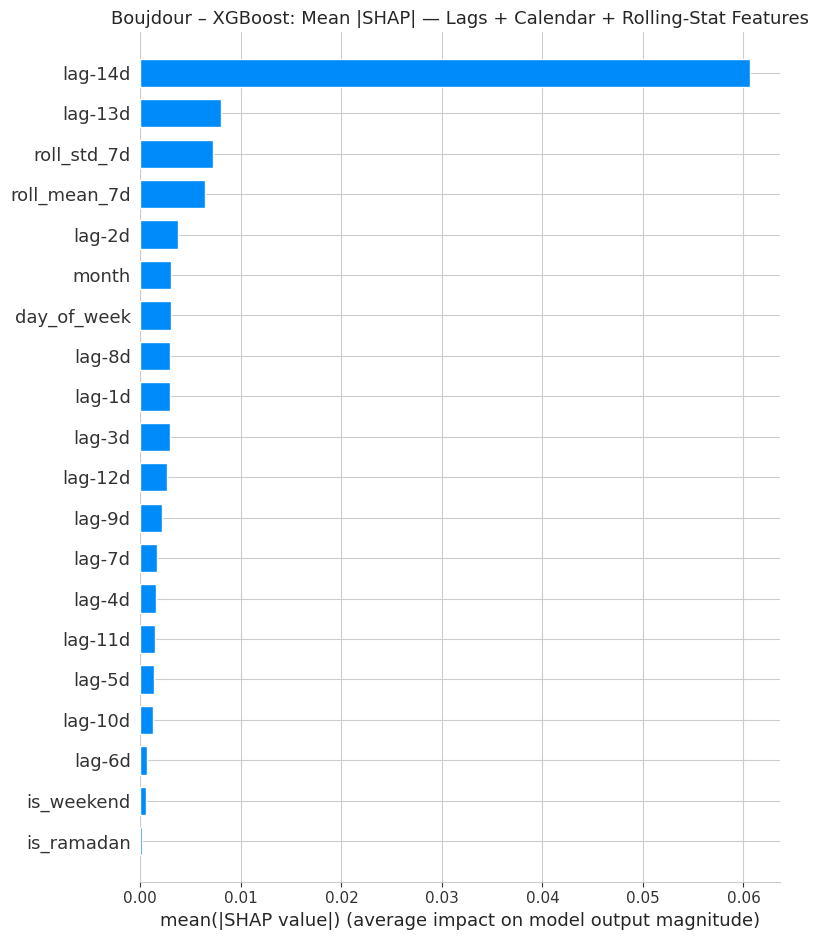

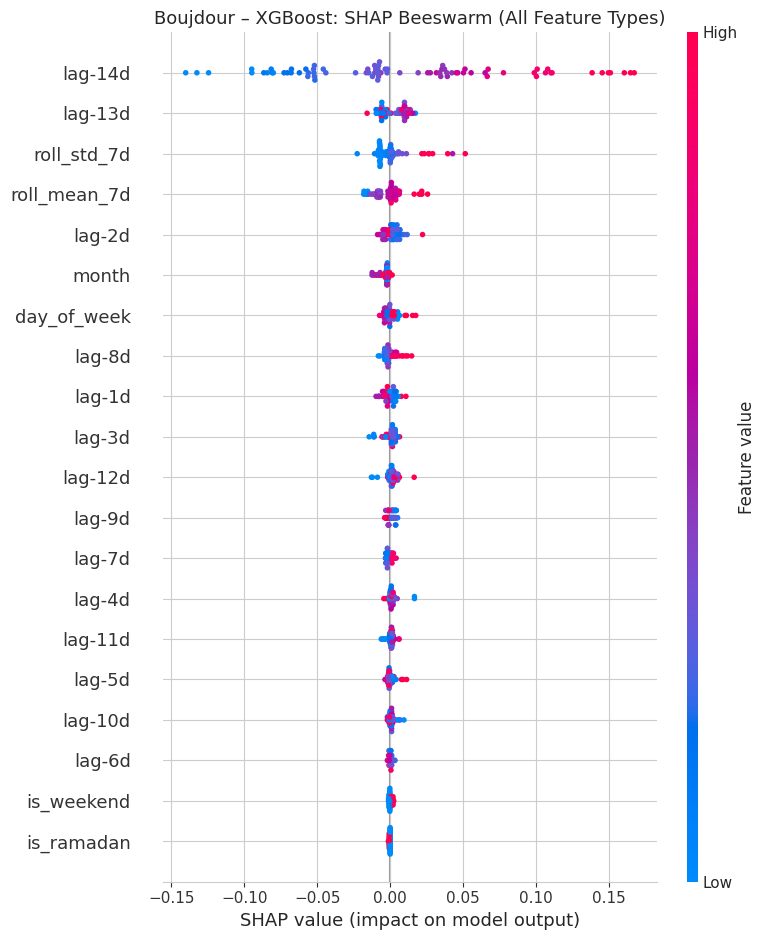

<Figure size 700x400 with 0 Axes>

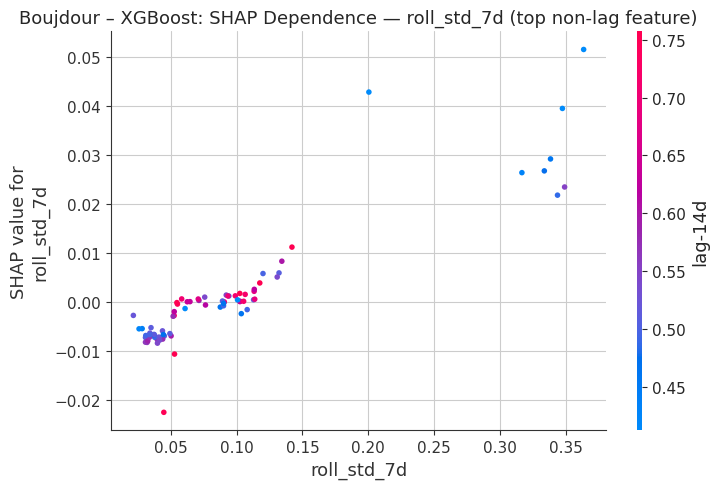


--- SHAP  |  Foum eloued ---


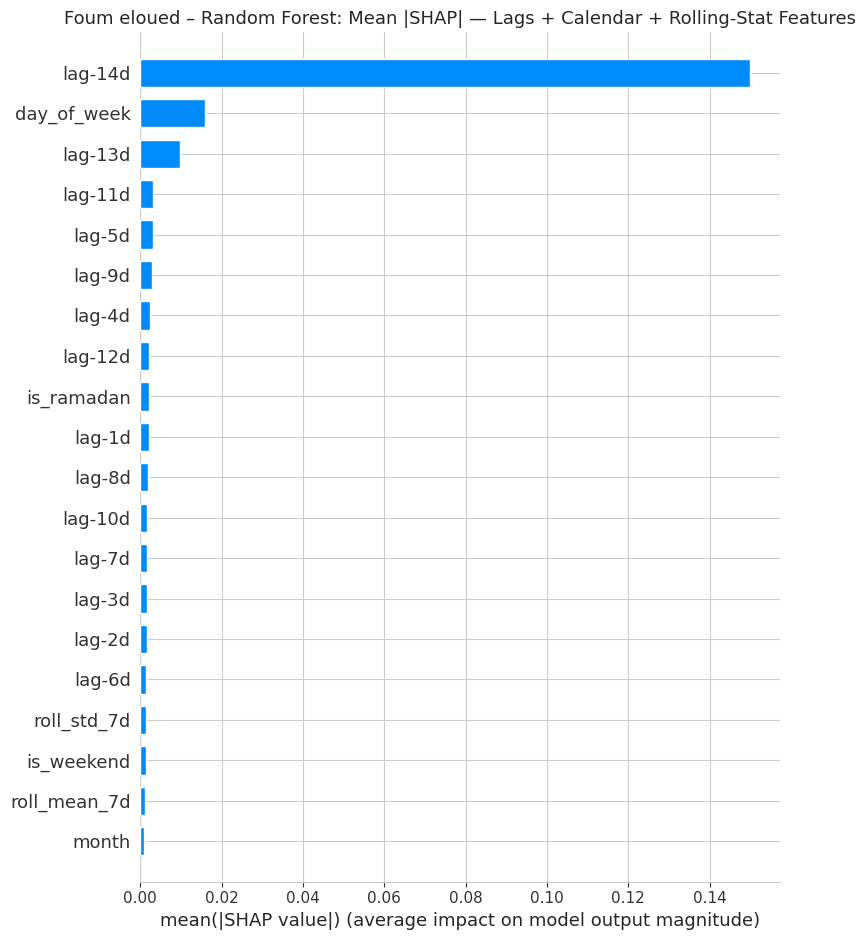

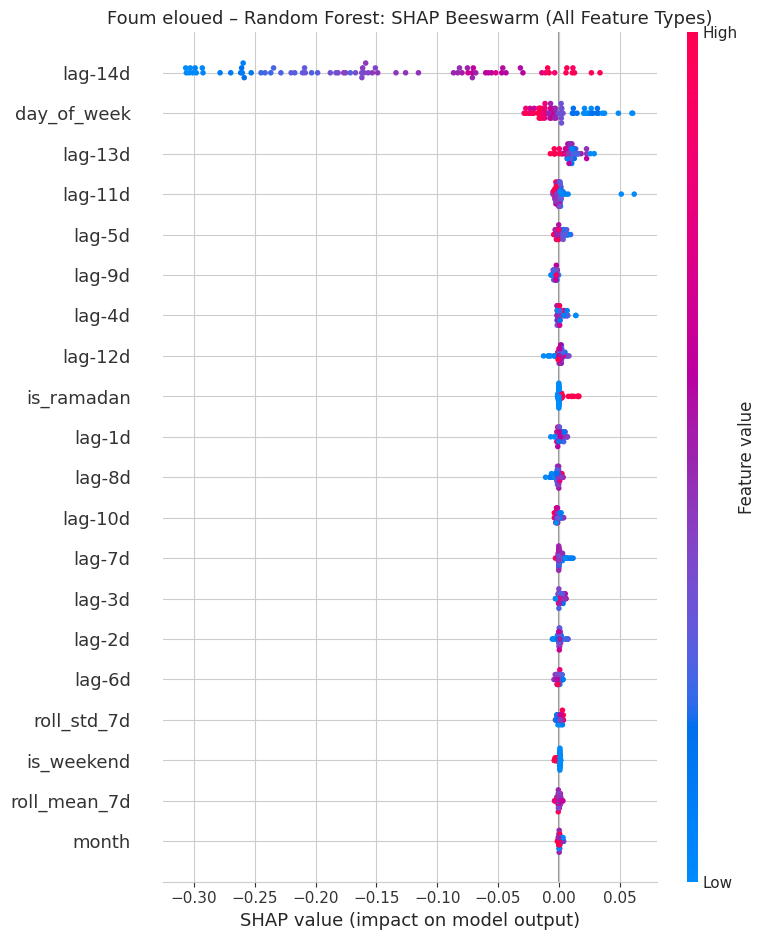

<Figure size 700x400 with 0 Axes>

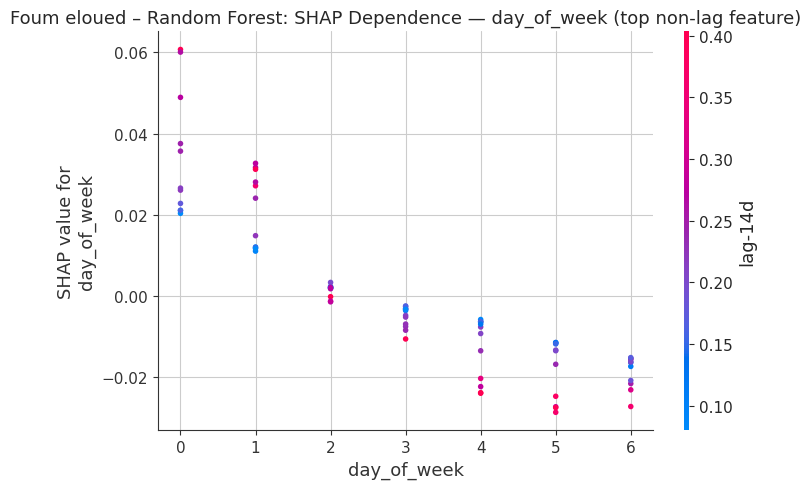

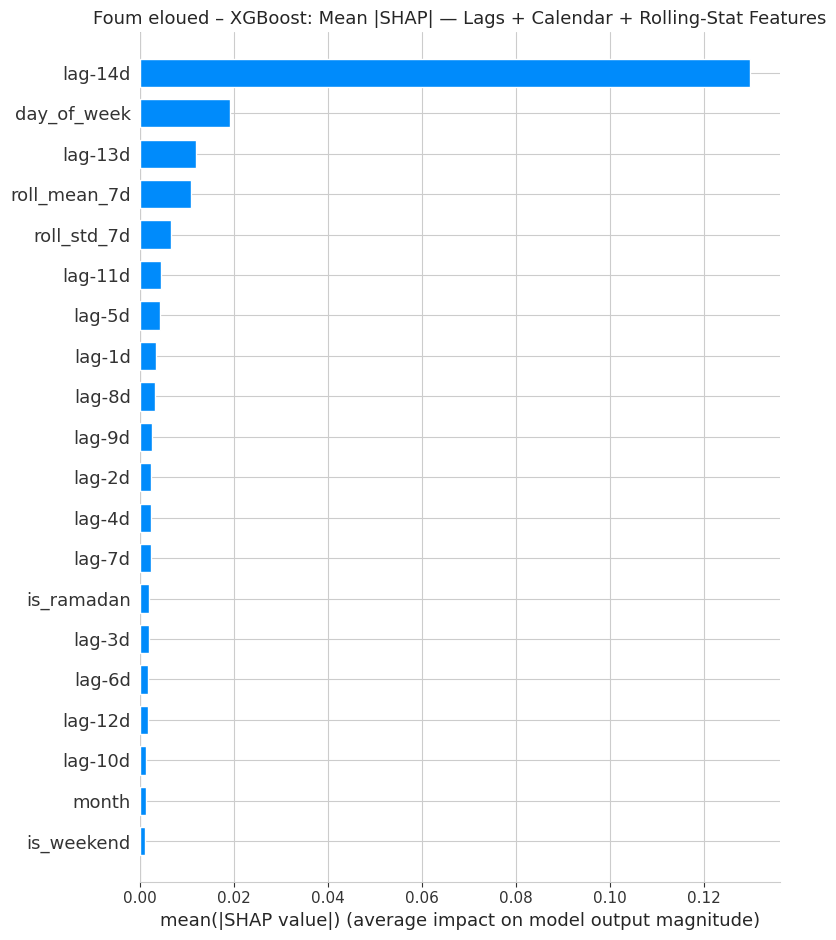

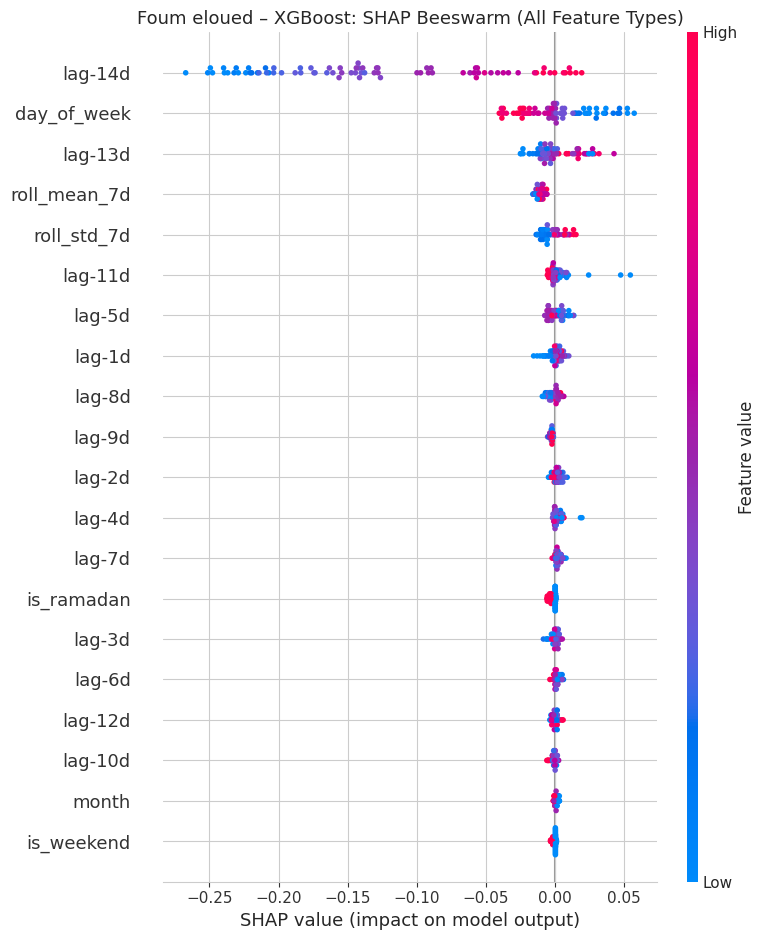

<Figure size 700x400 with 0 Axes>

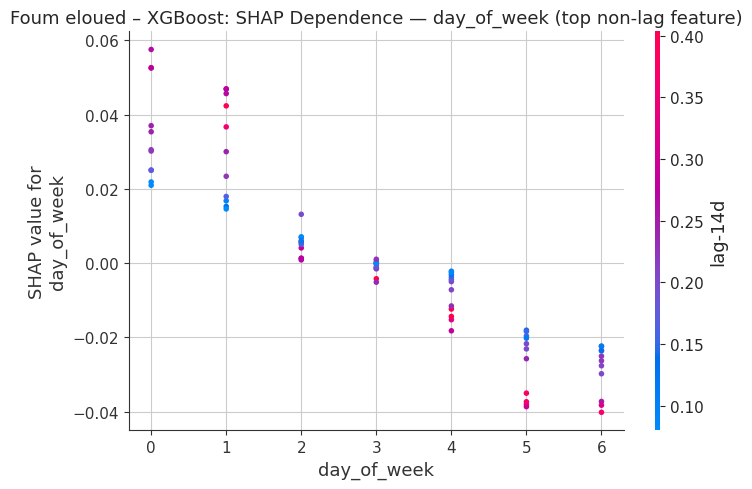


--- SHAP  |  Marrakech ---


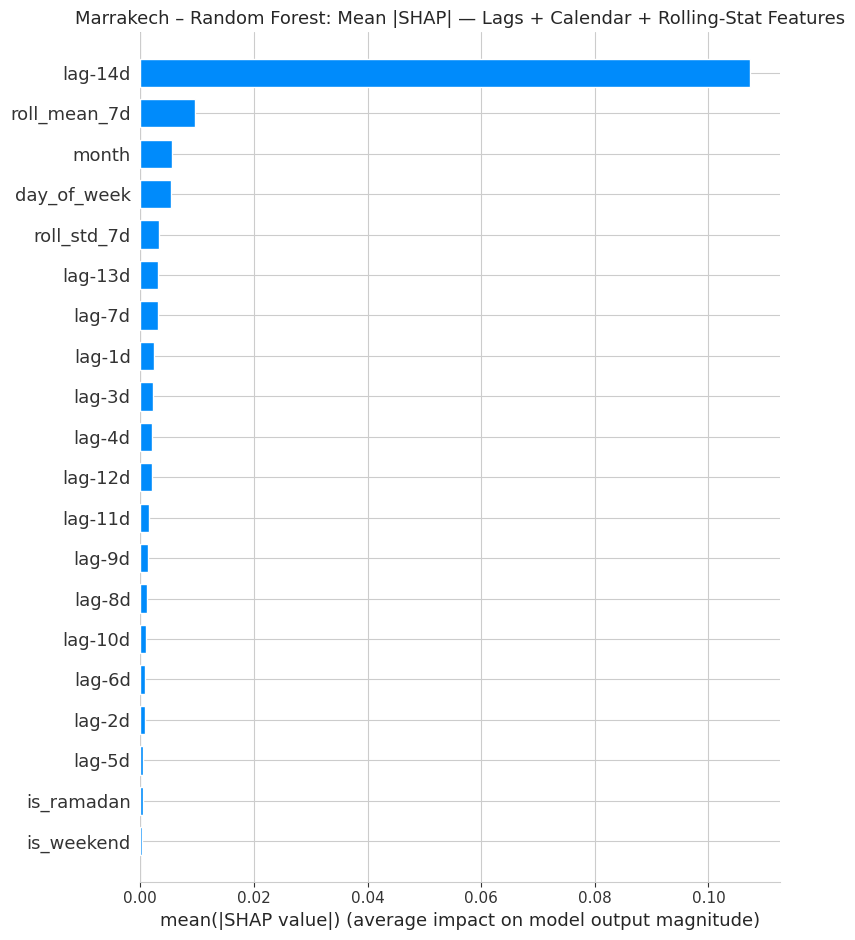

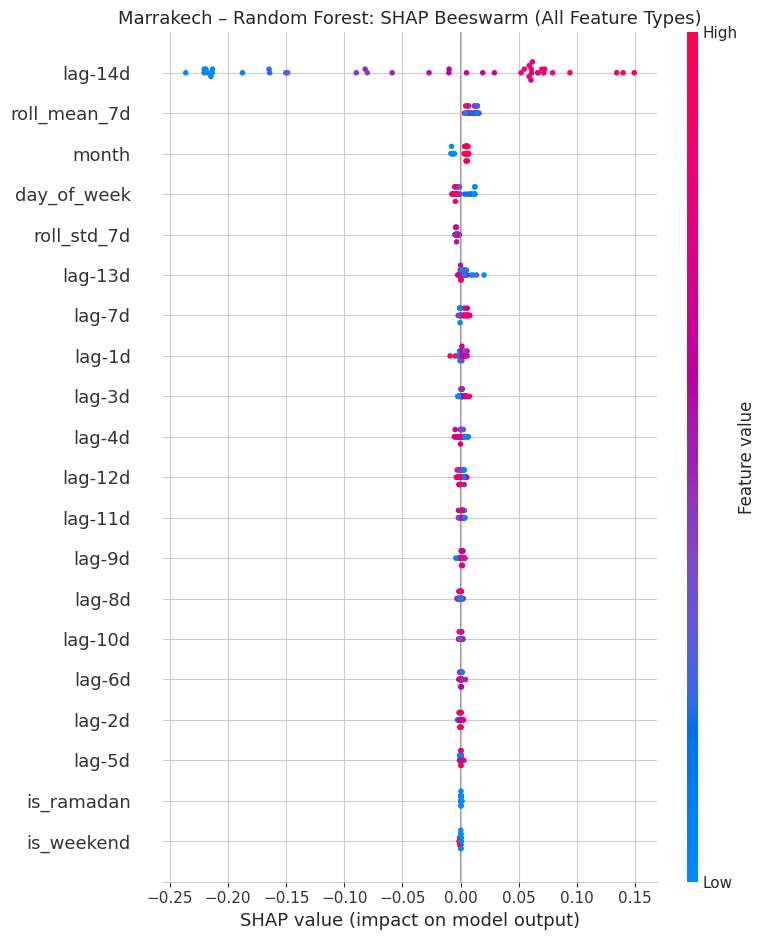

<Figure size 700x400 with 0 Axes>

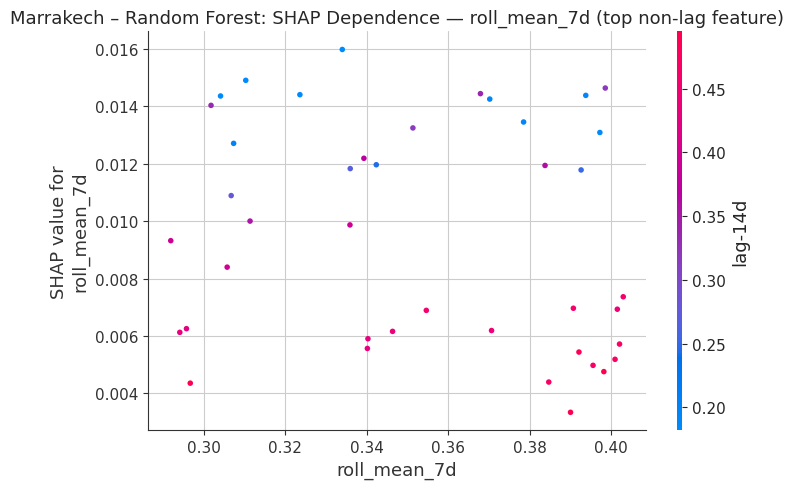

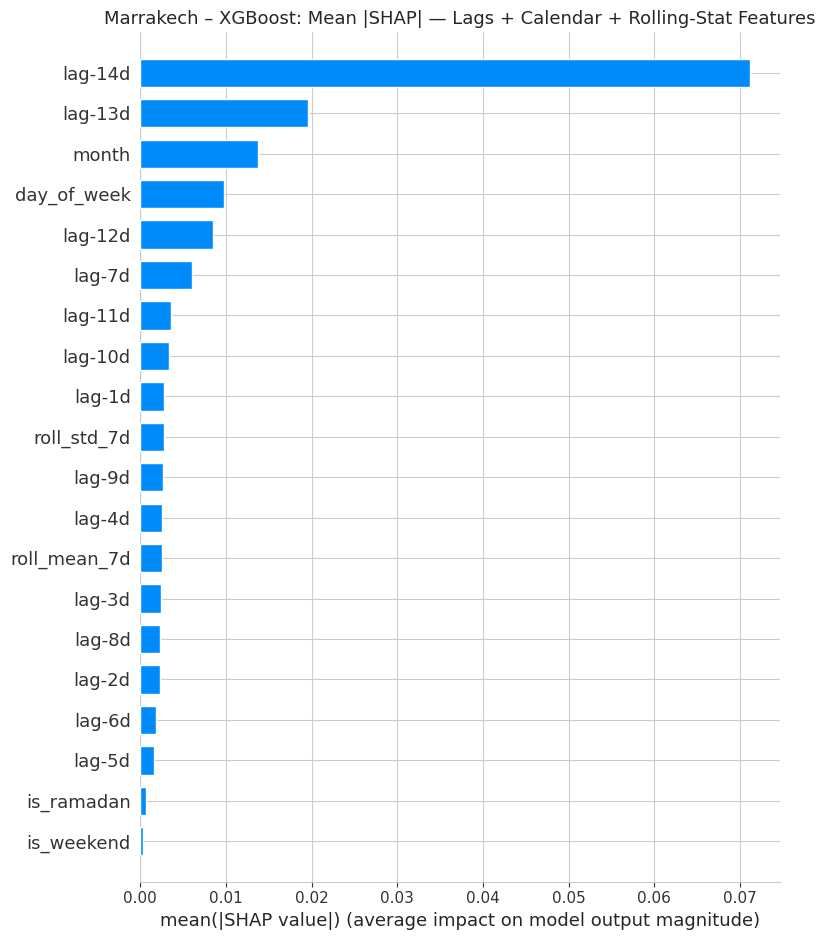

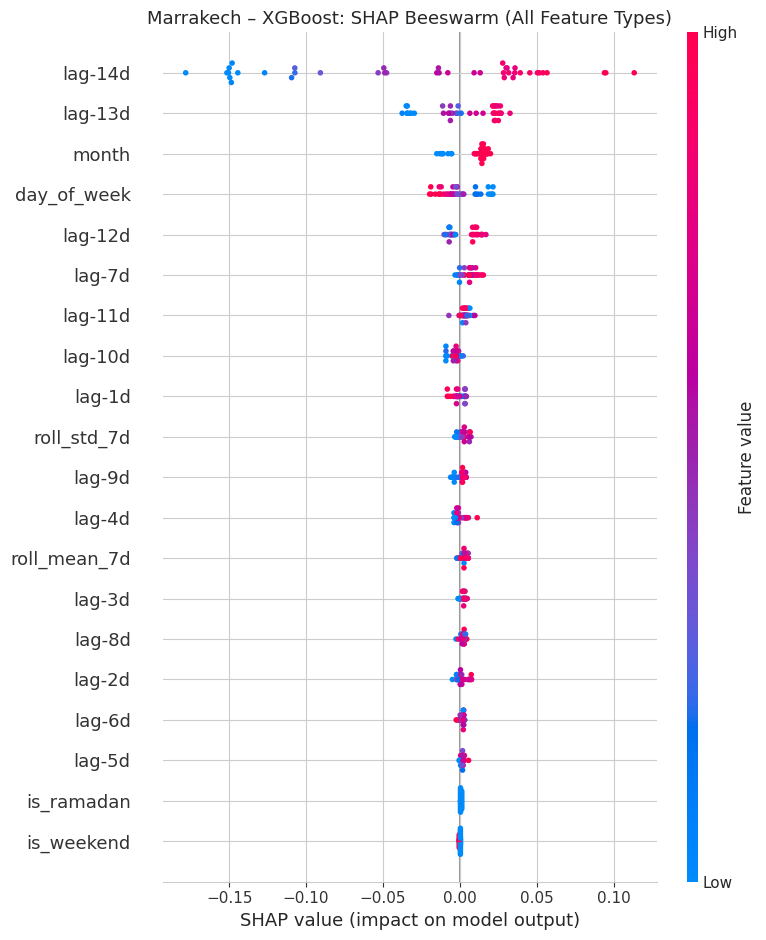

<Figure size 700x400 with 0 Axes>

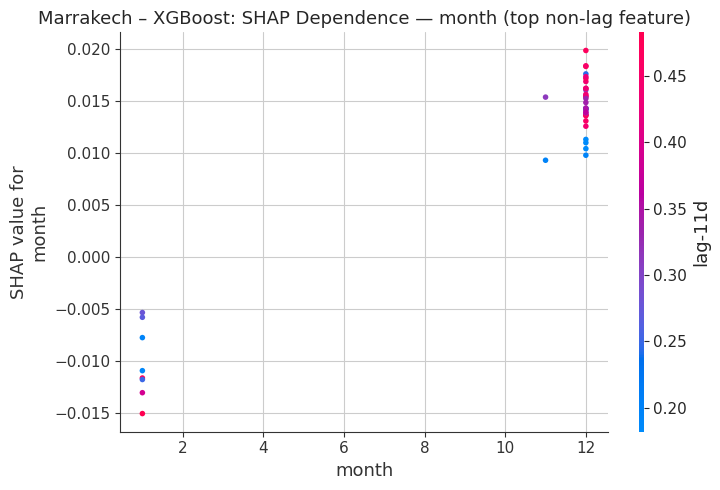


=== Full pipeline complete ===
Outputs saved to: /content/processed_data


In [ ]:
import shap

# ------------------------------------------------------------
# Loop through each city and compute SHAP values for RF & XGB
# ------------------------------------------------------------
for city in city_data:
    print(f"\n--- SHAP  |  {city} ---")

    # Feature names: lags + calendar + rolling stats
    feature_names = FEATURE_NAMES
    X_te_full = city_splits[city]["Xf_te"]   # test set features

    # ------------------------------------------------------------
    # Run SHAP for Random Forest and XGBoost
    # ------------------------------------------------------------
    for model_name, model_obj in [
        ("Random Forest", results_rf[city]["model"]),
        ("XGBoost",       results_xgb[city]["model"])
    ]:
        # Create SHAP explainer for tree-based models
        explainer = shap.TreeExplainer(model_obj)

        # Compute SHAP values for test set
        shap_vals = explainer.shap_values(X_te_full)

        # ------------------------------------------------------------
        # Bar plot: mean absolute SHAP values (feature importance)
        # ------------------------------------------------------------
        plt.figure(figsize=(8, 5))
        shap.summary_plot(
            shap_vals,
            X_te_full,
            feature_names=feature_names,
            plot_type="bar",       # bar chart of mean |SHAP|
            show=False,
            max_display=len(feature_names)
        )
        plt.title(f"{city} – {model_name}: Mean |SHAP| — Lags + Calendar + Rolling-Stat Features")
        plt.tight_layout()
        plt.show()

        # ------------------------------------------------------------
        # Beeswarm plot: distribution + direction of SHAP values
        # ------------------------------------------------------------
        plt.figure(figsize=(8, 5))
        shap.summary_plot(
            shap_vals,
            X_te_full,
            feature_names=feature_names,
            show=False,
            max_display=len(feature_names)
        )
        plt.title(f"{city} – {model_name}: SHAP Beeswarm (All Feature Types)")
        plt.tight_layout()
        plt.show()

        # ------------------------------------------------------------
        # Dependence plot: top-ranked non-lag feature
        # ------------------------------------------------------------
        # Identify indices of non-lag features
        non_lag_idx = [i for i, n in enumerate(feature_names) if not n.startswith("lag-")]

        # Compute mean absolute SHAP values
        mean_abs_shap = np.abs(shap_vals).mean(axis=0)

        # Select top non-lag feature by importance
        top_non_lag = non_lag_idx[int(np.argmax(mean_abs_shap[non_lag_idx]))]

        # Plot dependence of SHAP values on that feature
        plt.figure(figsize=(7, 4))
        shap.dependence_plot(
            top_non_lag,
            shap_vals,
            X_te_full,
            feature_names=feature_names,
            show=False
        )
        plt.title(f"{city} – {model_name}: SHAP Dependence — "
                  f"{feature_names[top_non_lag]} (top non-lag feature)")
        plt.tight_layout()
        plt.show()

# ------------------------------------------------------------
# Final pipeline completion message
# ------------------------------------------------------------
print("\n=== Full pipeline complete ===")
print("Outputs saved to:", OUTPUT_DIR.resolve())



**SHAP works on any feature the model is trained on.**  Section **[8].2** above now builds an **extended feature
set**: the original 14 lag features, plus `day_of_week`, `month`,
`is_weekend`, `is_ramadan` and 7-day rolling mean/std. Random Forest and XGBoost are
retrained on this extended set, and SHAP is computed over *all* of these
features above, so the bar/beeswarm plots can show whether, e.g.,
`day_of_week` or `roll_mean_7d` rivals or beats individual lag features in
importance for a given city rather than assuming lags dominate a priori.
A SHAP **dependence plot** on the top non-lag feature is also added to show
the direction of its effect.

> Runs SHAP TreeExplainer on the Random Forest and XGBoost models for each city; bar plots show mean |SHAP| per lag feature (which lag distances matter most) and beeswarm plots reveal the direction and spread of each feature's impact on predictions.

## **[10] SHAP interpretability — GRU (Extended Features)**


--- GRU (Extended Features) SHAP  |  Laayoune ---


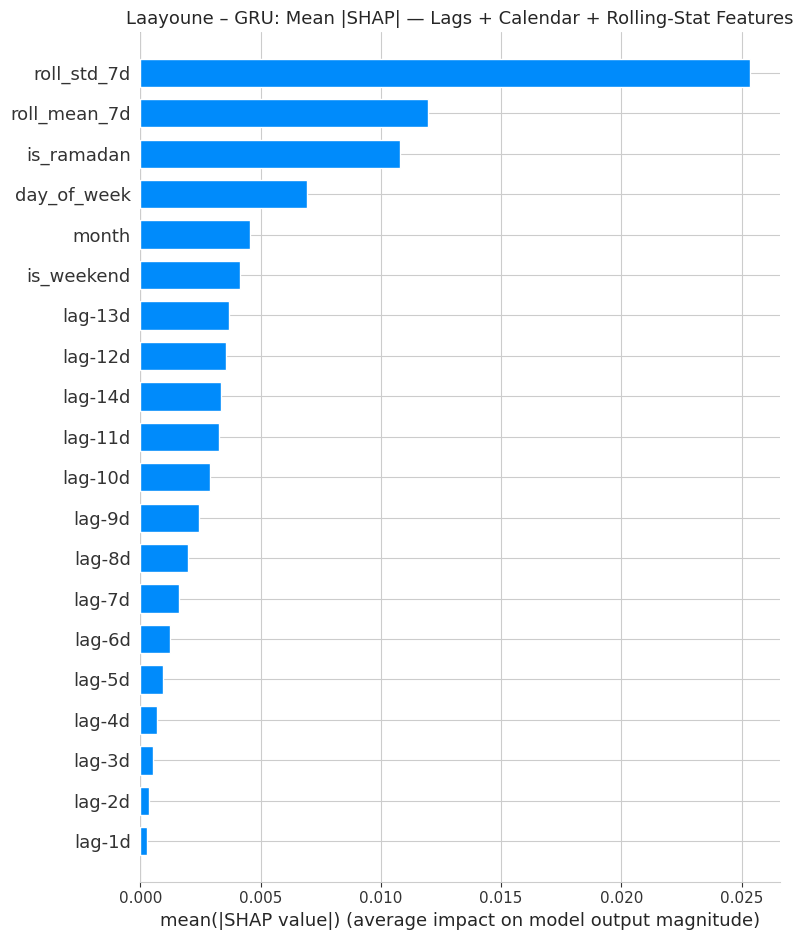

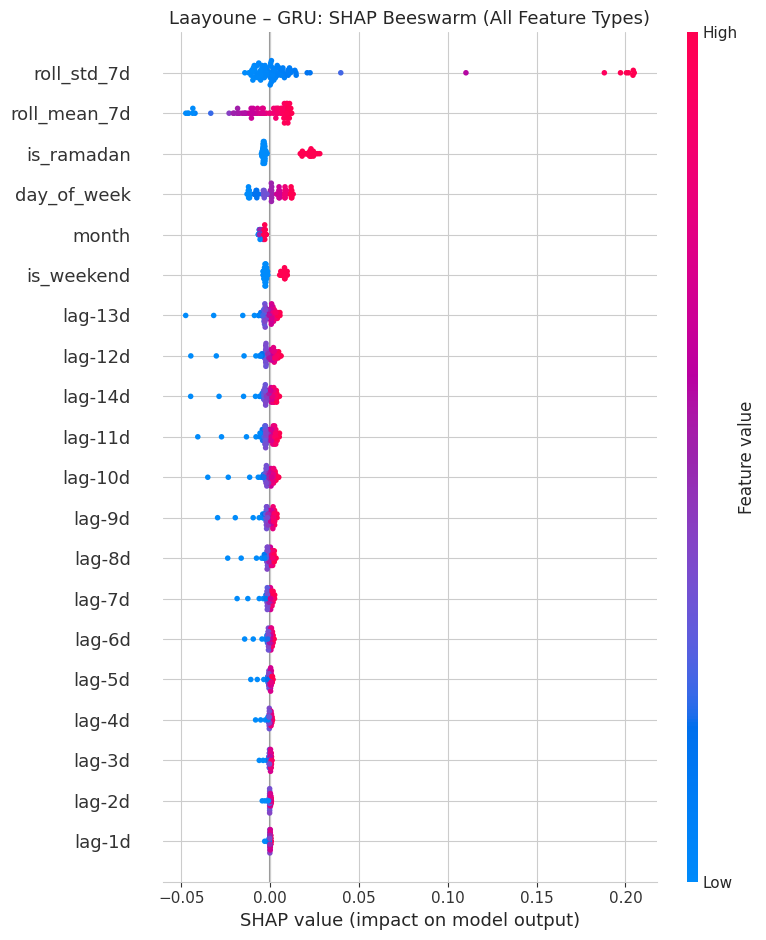

<Figure size 700x400 with 0 Axes>

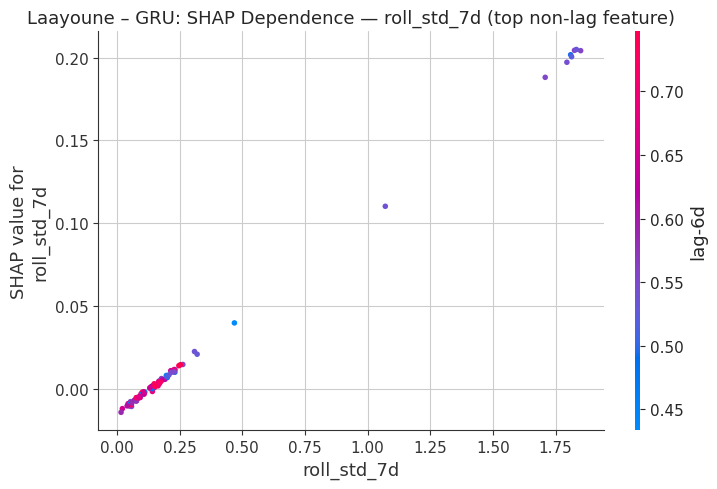


--- GRU (Extended Features) SHAP  |  Boujdour ---


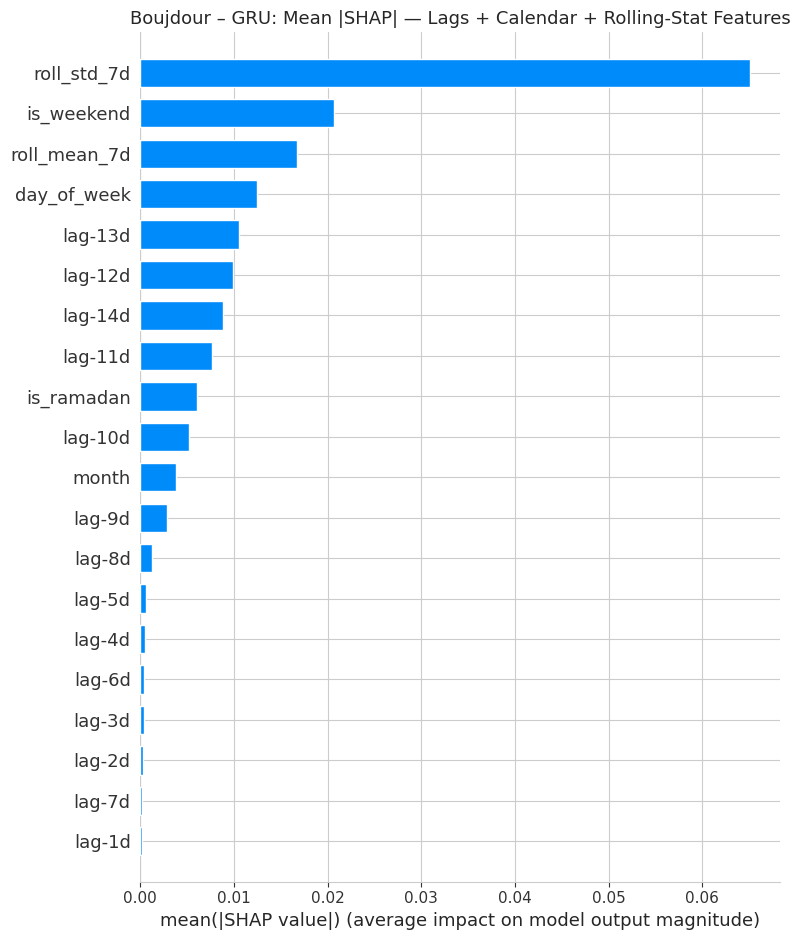

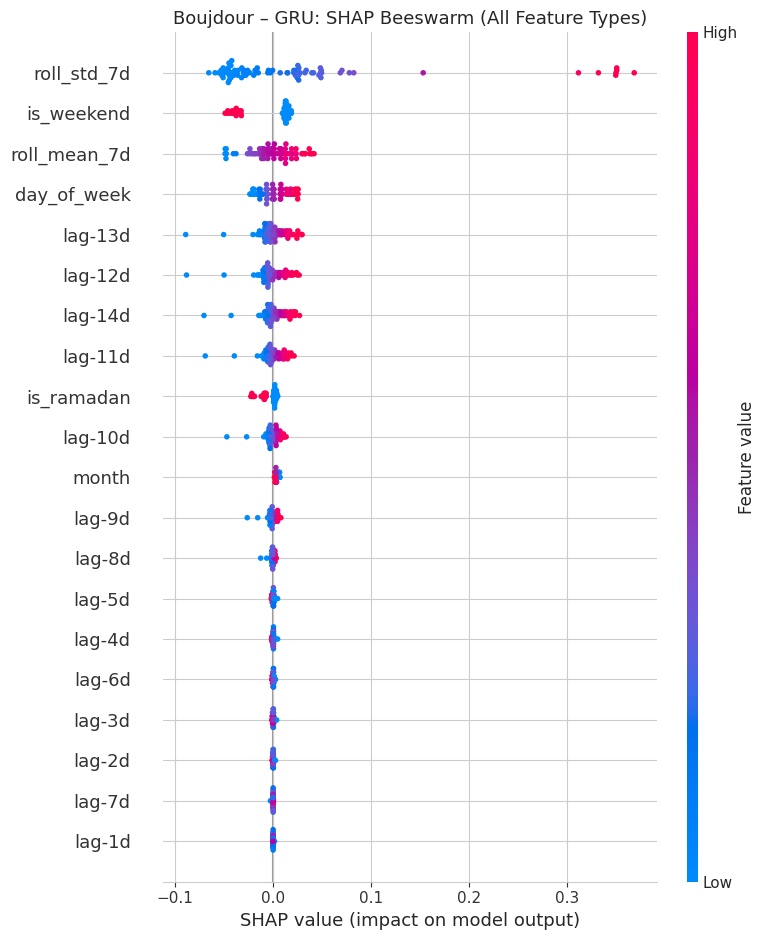

<Figure size 700x400 with 0 Axes>

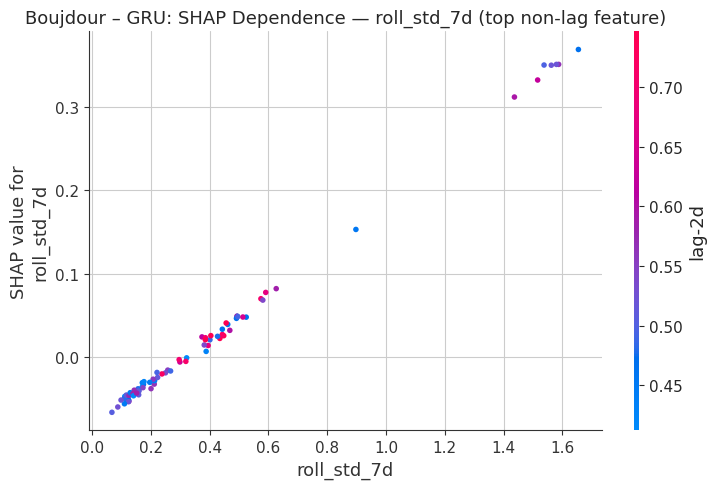


--- GRU (Extended Features) SHAP  |  Foum eloued ---


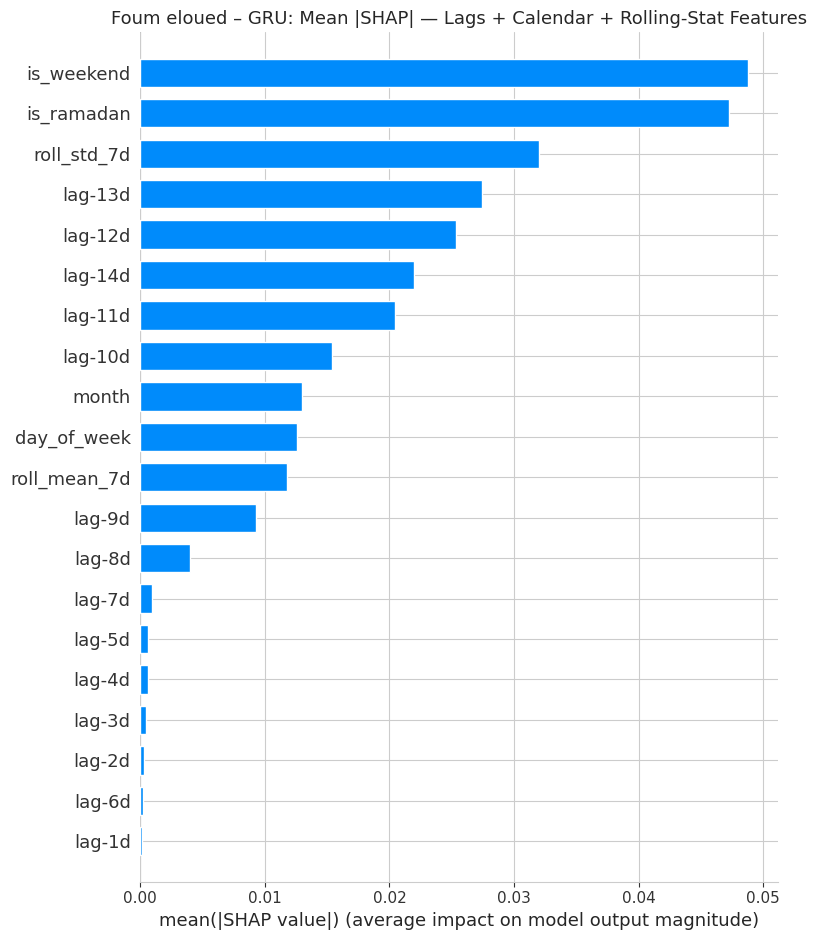

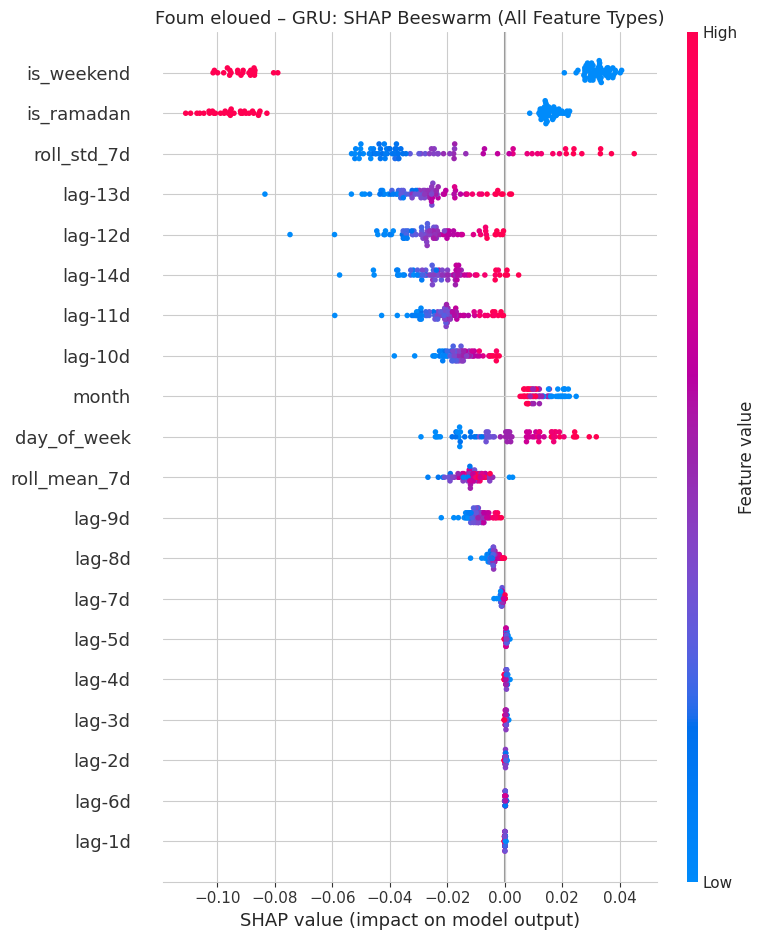

<Figure size 700x400 with 0 Axes>

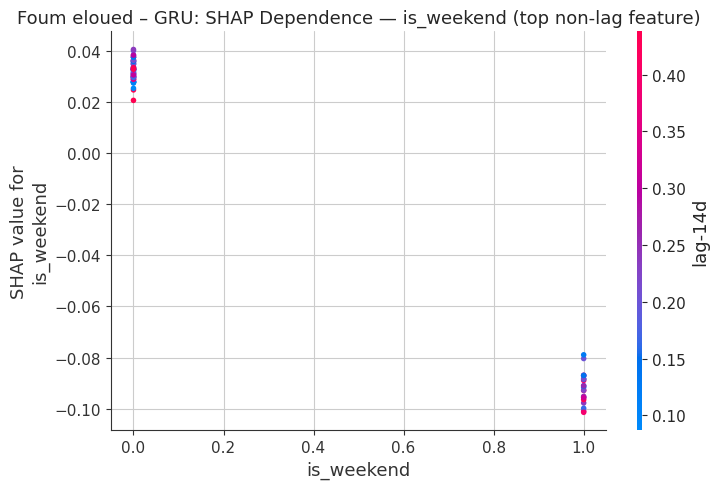


--- GRU (Extended Features) SHAP  |  Marrakech ---


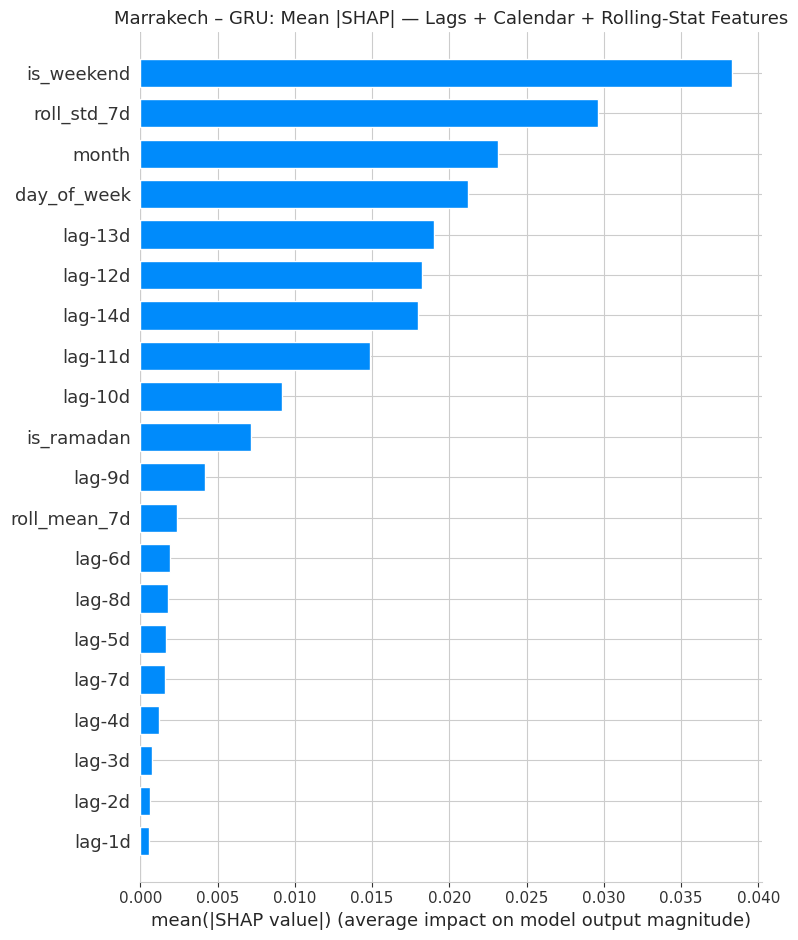

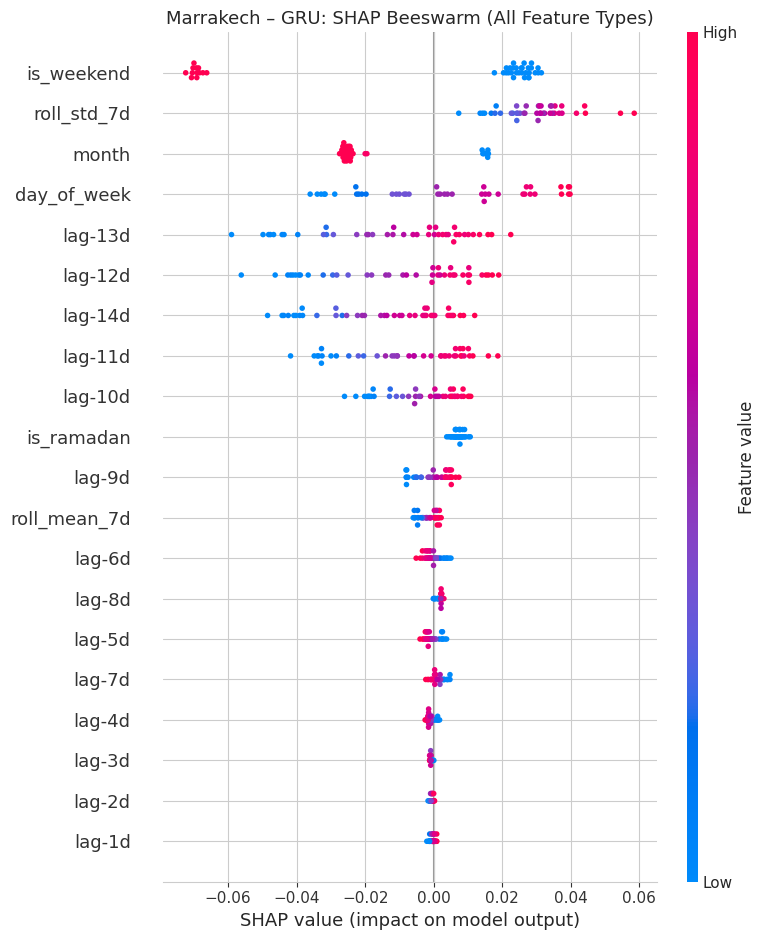

<Figure size 700x400 with 0 Axes>

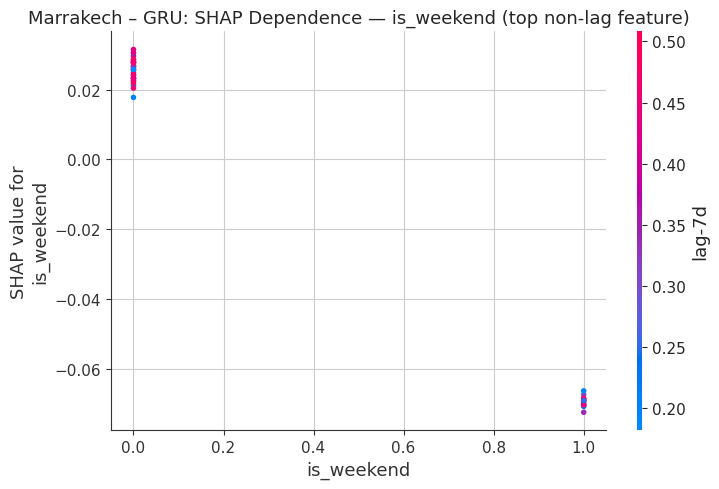


GRU (Extended Features) SHAP analysis complete for all cities.


In [ ]:
import shap

# Dictionary to store GRU SHAP values per city
results_gru_shap = {}

# ------------------------------------------------------------
# Loop through each city and compute SHAP values for GRU (Extended Features)
# ------------------------------------------------------------
for city, sp in city_splits.items():
    print(f"\n--- GRU (Extended Features) SHAP  |  {city} ---")

    # Retrieve trained GRU model and feature arrays
    gru_ext_model = results_gru_ext[city]["model"]
    Xf_tr_3d = results_gru_ext[city]["Xf_tr_3d"]   # training features (scaled, 3D)
    Xf_te_3d = results_gru_ext[city]["Xf_te_3d"]   # test features (scaled, 3D)

    # ------------------------------------------------------------
    # Background sample for GradientExplainer baseline
    # ------------------------------------------------------------
    rng = np.random.default_rng(42)
    bg_size = min(50, Xf_tr_3d.shape[0])                 # cap background size at 50
    bg_idx = rng.choice(Xf_tr_3d.shape[0], size=bg_size, replace=False)
    background = Xf_tr_3d[bg_idx]

    # Create SHAP GradientExplainer for GRU model
    explainer = shap.GradientExplainer(gru_ext_model, background)

    # Compute SHAP values for test set
    shap_vals_gru = explainer.shap_values(Xf_te_3d)

    # ------------------------------------------------------------
    # Reshape SHAP values to 2D (samples × features)
    # ------------------------------------------------------------
    if isinstance(shap_vals_gru, list):   # handle list output
        shap_vals_gru = shap_vals_gru[0]
    shap_vals_gru = np.array(shap_vals_gru).reshape(Xf_te_3d.shape[0], N_FEATURES)

    # Flatten test features to 2D for plotting
    X_te_2d = Xf_te_3d.reshape(Xf_te_3d.shape[0], N_FEATURES)

    # Store SHAP values for later use
    results_gru_shap[city] = shap_vals_gru

    # ------------------------------------------------------------
    # Bar plot: mean absolute SHAP values (feature importance)
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    shap.summary_plot(
        shap_vals_gru, X_te_2d,
        feature_names=FEATURE_NAMES,
        plot_type="bar", show=False,
        max_display=len(FEATURE_NAMES)
    )
    plt.title(f"{city} – GRU: Mean |SHAP| — Lags + Calendar + Rolling-Stat Features")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Beeswarm plot: distribution + direction of SHAP values
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    shap.summary_plot(
        shap_vals_gru, X_te_2d,
        feature_names=FEATURE_NAMES,
        show=False,
        max_display=len(FEATURE_NAMES)
    )
    plt.title(f"{city} – GRU: SHAP Beeswarm (All Feature Types)")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Dependence plot: top-ranked non-lag feature
    # ------------------------------------------------------------
    # Identify indices of non-lag features
    non_lag_idx = [i for i, n in enumerate(FEATURE_NAMES) if not n.startswith("lag-")]

    # Compute mean absolute SHAP values
    mean_abs_shap = np.abs(shap_vals_gru).mean(axis=0)

    # Select top non-lag feature by importance
    top_non_lag = non_lag_idx[int(np.argmax(mean_abs_shap[non_lag_idx]))]

    # Plot dependence of SHAP values on that feature
    plt.figure(figsize=(7, 4))
    shap.dependence_plot(
        top_non_lag, shap_vals_gru, X_te_2d,
        feature_names=FEATURE_NAMES, show=False
    )
    plt.title(f"{city} – GRU: SHAP Dependence — "
              f"{FEATURE_NAMES[top_non_lag]} (top non-lag feature)")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Final pipeline completion message
# ------------------------------------------------------------
print("\nGRU (Extended Features) SHAP analysis complete for all cities.")

> Runs `shap.GradientExplainer` on the GRU-Extended model using the identical 20-feature input RF/XGBoost use; produces bar, beeswarm, and top-non-lag dependence plots in the same format as the RF/XGBoost SHAP section, enabling direct cross-model comparison on shared features rather than lags alone.

### **Cross-Model Feature Comparison**

In [ ]:
import shap as _shap

comparison_rows = []

# ------------------------------------------------------------
# Loop through each city and compute top-3 SHAP features
# ------------------------------------------------------------
for city in city_data:
    feature_names = FEATURE_NAMES
    X_te_full = city_splits[city]["Xf_te"]   # test set features

    # ------------------------------------------------------------
    # Tree-based models: Random Forest & XGBoost
    # ------------------------------------------------------------
    for model_name, model_obj in [
        ("Random Forest", results_rf[city]["model"]),
        ("XGBoost",       results_xgb[city]["model"])
    ]:
        # Create SHAP explainer for tree-based model
        explainer = _shap.TreeExplainer(model_obj)

        # Compute SHAP values for test set
        shap_vals = explainer.shap_values(X_te_full)

        # Compute mean absolute SHAP values (global importance)
        mean_abs = np.abs(shap_vals).mean(axis=0)

        # Identify indices of top-3 features
        top3_idx = np.argsort(-mean_abs)[:3]

        # Append results to comparison list
        comparison_rows.append({
            "City": city, "Model": model_name,
            "Top-1 Feature": feature_names[top3_idx[0]],
            "Top-2 Feature": feature_names[top3_idx[1]],
            "Top-3 Feature": feature_names[top3_idx[2]],
        })

    # ------------------------------------------------------------
    # GRU (Extended Features) model
    # ------------------------------------------------------------
    # Compute mean absolute SHAP values for GRU
    gru_mean_abs = np.abs(results_gru_shap[city]).mean(axis=0)

    # Identify indices of top-3 features
    top3_idx_gru = np.argsort(-gru_mean_abs)[:3]

    # Append results to comparison list
    comparison_rows.append({
        "City": city, "Model": "GRU (Extended)",
        "Top-1 Feature": feature_names[top3_idx_gru[0]],
        "Top-2 Feature": feature_names[top3_idx_gru[1]],
        "Top-3 Feature": feature_names[top3_idx_gru[2]],
    })

# ------------------------------------------------------------
# Convert results into DataFrame and export to CSV
# ------------------------------------------------------------
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(OUTPUT_DIR / "shap_top_features_by_model_v6.csv", index=False)

# Print full comparison table
print(comparison_df.to_string(index=False))

       City          Model Top-1 Feature Top-2 Feature Top-3 Feature
   Laayoune  Random Forest       lag-14d  roll_mean_7d       lag-13d
   Laayoune        XGBoost       lag-14d  roll_mean_7d       lag-13d
   Laayoune GRU (Extended)   roll_std_7d  roll_mean_7d    is_ramadan
   Boujdour  Random Forest       lag-14d   roll_std_7d  roll_mean_7d
   Boujdour        XGBoost       lag-14d       lag-13d   roll_std_7d
   Boujdour GRU (Extended)   roll_std_7d    is_weekend  roll_mean_7d
Foum eloued  Random Forest       lag-14d   day_of_week       lag-13d
Foum eloued        XGBoost       lag-14d   day_of_week       lag-13d
Foum eloued GRU (Extended)    is_weekend    is_ramadan   roll_std_7d
  Marrakech  Random Forest       lag-14d  roll_mean_7d         month
  Marrakech        XGBoost       lag-14d       lag-13d         month
  Marrakech GRU (Extended)    is_weekend   roll_std_7d         month


> Extracts each model's top-3 most influential features — of any type, not just lags — by mean |SHAP| for Random Forest, XGBoost, and GRU (Extended) per city, exported to `shap_top_features_by_model_v6.csv`, now that all three models are evaluated on the identical feature space.